In [2]:
YA= '/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem.json'

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load JSON data (Replace with actual file path)
with open(YA, "r") as file:
    data = json.load(file)

# Extracting relevant metrics
raw_correct = 0
onto_correct = 0
total_questions = len(data)
calculation_errors_raw = 0
calculation_errors_onto = 0
concept_coverage_raw = []
concept_coverage_onto = []

for key, item in data.items():
    correct_answer = item["question"]["answer"]
    raw_response = item["raw_model_response"].lower()
    onto_response = item["onto_model_response"].lower()
    
    # Check if the raw model got the correct answer
    if correct_answer in raw_response:
        raw_correct += 1
    else:
        calculation_errors_raw += 1
    
    # Check if the ontology model got the correct answer
    if correct_answer in onto_response:
        onto_correct += 1
    else:
        calculation_errors_onto += 1
    
    # Concept coverage (count of domain-related words)
    concept_coverage_raw.append(len(item["raw_model_response"].split()))
    concept_coverage_onto.append(len(item["onto_model_response"].split()))

# Compute accuracy
raw_accuracy = raw_correct / total_questions * 100
onto_accuracy = onto_correct / total_questions * 100
accuracy_improvement = onto_accuracy - raw_accuracy

# Compute error rate
raw_error_rate = 100 - raw_accuracy
onto_error_rate = 100 - onto_accuracy
error_reduction = raw_error_rate - onto_error_rate

# Average concept coverage (word count in responses)
avg_concept_raw = np.mean(concept_coverage_raw)
avg_concept_onto = np.mean(concept_coverage_onto)

# Plot accuracy improvement
plt.figure(figsize=(10, 5))
x_labels = ["Raw Model", "Ontology Model"]
accuracies = [raw_accuracy, onto_accuracy]
plt.bar(x_labels, accuracies, color=['red', 'blue'])
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

# Plot error rate reduction
plt.figure(figsize=(10, 5))
error_rates = [raw_error_rate, onto_error_rate]
plt.bar(x_labels, error_rates, color=['red', 'blue'])
plt.ylabel("Error Rate (%)")
plt.title("Error Rate Reduction")
plt.ylim(0, 100)
plt.show()

# Plot concept coverage
plt.figure(figsize=(10, 5))
concepts = [avg_concept_raw, avg_concept_onto]
plt.bar(x_labels, concepts, color=['red', 'blue'])
plt.ylabel("Avg Concept Coverage (Word Count)")
plt.title("Concept Coverage Comparison")
plt.show()

# Print summary results
print(f"Raw Model Accuracy: {raw_accuracy:.2f}%")
print(f"Ontology Model Accuracy: {onto_accuracy:.2f}%")
print(f"Accuracy Improvement: {accuracy_improvement:.2f}%")
print(f"Raw Model Error Rate: {raw_error_rate:.2f}%")
print(f"Ontology Model Error Rate: {onto_error_rate:.2f}%")
print(f"Error Rate Reduction: {error_reduction:.2f}%")
print(f"Avg Concept Coverage (Raw): {avg_concept_raw:.2f} words")
print(f"Avg Concept Coverage (Ontology): {avg_concept_onto:.2f} words")


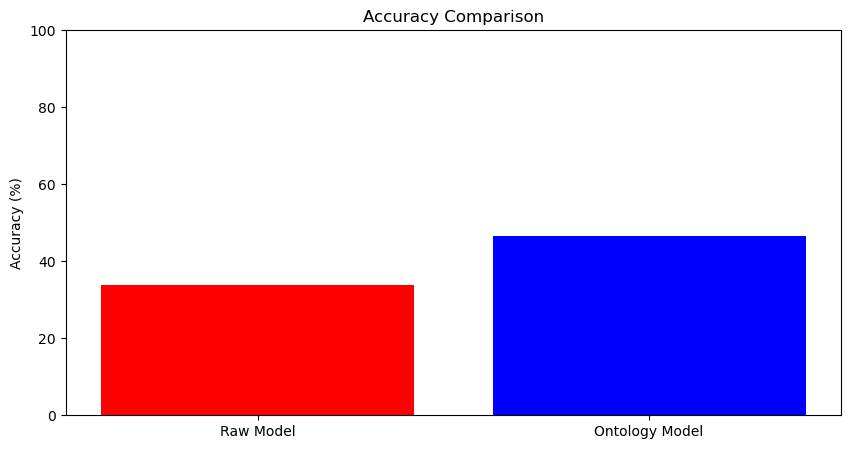

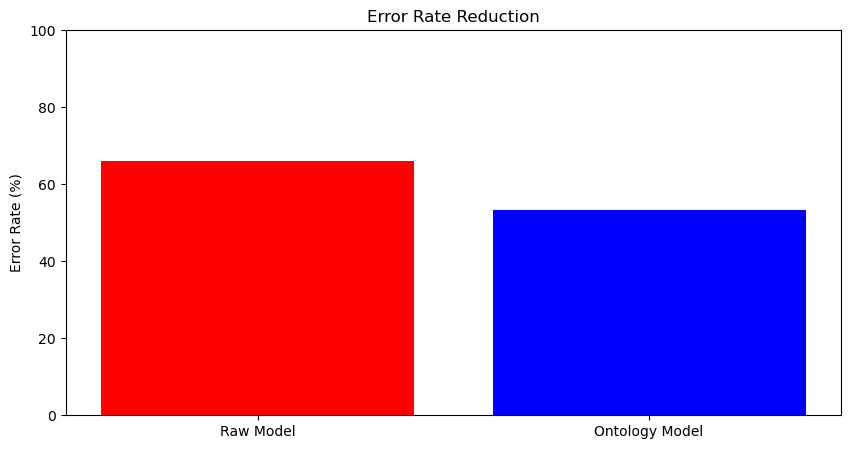

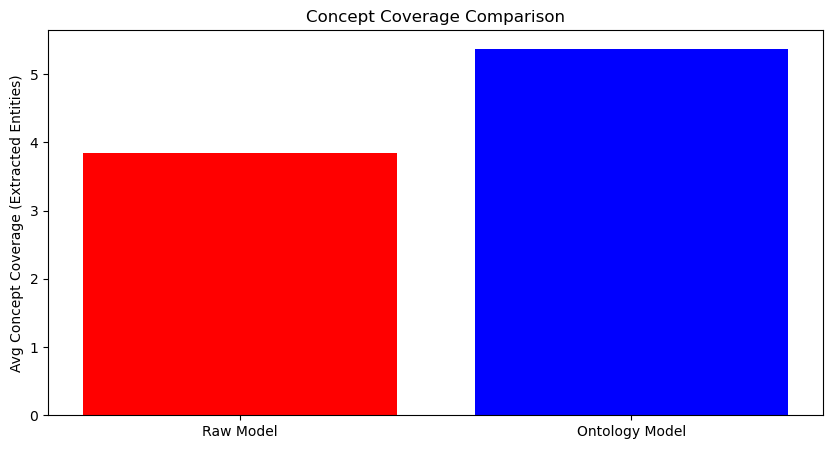

Raw Model Accuracy: 33.95%
Ontology Model Accuracy: 46.56%
Accuracy Improvement: 12.60%
Raw Model Error Rate: 66.05%
Ontology Model Error Rate: 53.44%
Error Rate Reduction: 12.60%
Avg Concept Coverage (Raw): 3.85 extracted entities
Avg Concept Coverage (Ontology): 5.38 extracted entities


In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load JSON data (Replace with actual file path)
with open(YA, "r") as file:
    data = json.load(file)

# Load spaCy model for NER (use a scientific model if available)
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Extracting relevant metrics
raw_correct = 0
onto_correct = 0
total_questions = len(data)
calculation_errors_raw = 0
calculation_errors_onto = 0
concept_coverage_raw = []
concept_coverage_onto = []

for key, item in data.items():
    correct_answer = item["question"]["answer"]
    raw_response = item["raw_model_response"].lower()
    onto_response = item["onto_model_response"].lower()
    
    # Check if the raw model got the correct answer
    if correct_answer in raw_response:
        raw_correct += 1
    else:
        calculation_errors_raw += 1
    
    # Check if the ontology model got the correct answer
    if correct_answer in onto_response:
        onto_correct += 1
    else:
        calculation_errors_onto += 1
    
    # Extract entities for concept coverage
    raw_entities = extract_entities(raw_response)
    onto_entities = extract_entities(onto_response)
    
    # Measure concept coverage as the number of unique extracted scientific terms
    concept_coverage_raw.append(len(raw_entities))
    concept_coverage_onto.append(len(onto_entities))

# Compute accuracy
raw_accuracy = raw_correct / total_questions * 100
onto_accuracy = onto_correct / total_questions * 100
accuracy_improvement = onto_accuracy - raw_accuracy

# Compute error rate
raw_error_rate = 100 - raw_accuracy
onto_error_rate = 100 - onto_accuracy
error_reduction = raw_error_rate - onto_error_rate

# Average concept coverage
avg_concept_raw = np.mean(concept_coverage_raw)
avg_concept_onto = np.mean(concept_coverage_onto)

# Plot accuracy improvement
plt.figure(figsize=(10, 5))
x_labels = ["Raw Model", "Ontology Model"]
accuracies = [raw_accuracy, onto_accuracy]
plt.bar(x_labels, accuracies, color=['red', 'blue'])
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

# Plot error rate reduction
plt.figure(figsize=(10, 5))
error_rates = [raw_error_rate, onto_error_rate]
plt.bar(x_labels, error_rates, color=['red', 'blue'])
plt.ylabel("Error Rate (%)")
plt.title("Error Rate Reduction")
plt.ylim(0, 100)
plt.show()

# Plot concept coverage
plt.figure(figsize=(10, 5))
concepts = [avg_concept_raw, avg_concept_onto]
plt.bar(x_labels, concepts, color=['red', 'blue'])
plt.ylabel("Avg Concept Coverage (Extracted Entities)")
plt.title("Concept Coverage Comparison")
plt.show()

# Print summary results
print(f"Raw Model Accuracy: {raw_accuracy:.2f}%")
print(f"Ontology Model Accuracy: {onto_accuracy:.2f}%")
print(f"Accuracy Improvement: {accuracy_improvement:.2f}%")
print(f"Raw Model Error Rate: {raw_error_rate:.2f}%")
print(f"Ontology Model Error Rate: {onto_error_rate:.2f}%")
print(f"Error Rate Reduction: {error_reduction:.2f}%")
print(f"Avg Concept Coverage (Raw): {avg_concept_raw:.2f} extracted entities")
print(f"Avg Concept Coverage (Ontology): {avg_concept_onto:.2f} extracted entities")


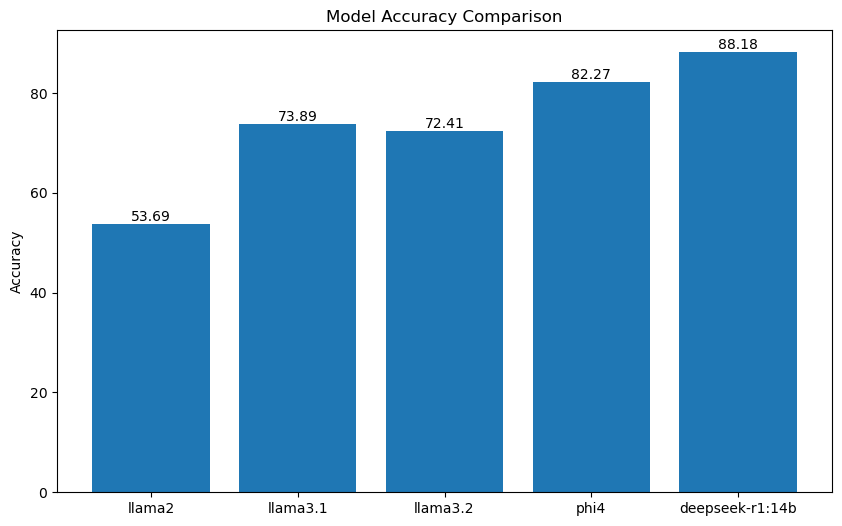

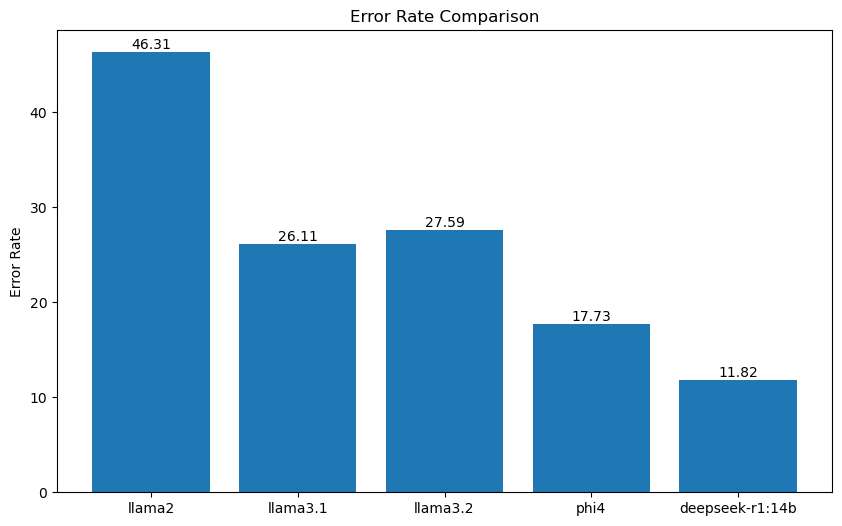

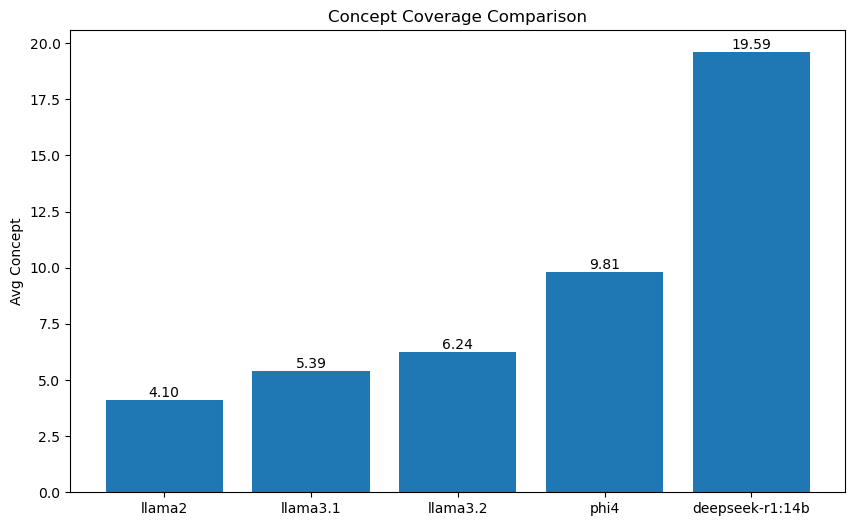


LLAMA2 Metrics:
Accuracy: 53.69%
Error Rate: 46.31%
Average Concept Coverage: 4.10 entities

LLAMA3.1 Metrics:
Accuracy: 73.89%
Error Rate: 26.11%
Average Concept Coverage: 5.39 entities

LLAMA3.2 Metrics:
Accuracy: 72.41%
Error Rate: 27.59%
Average Concept Coverage: 6.24 entities

PHI4 Metrics:
Accuracy: 82.27%
Error Rate: 17.73%
Average Concept Coverage: 9.81 entities

DEEPSEEK-R1:14B Metrics:
Accuracy: 88.18%
Error Rate: 11.82%
Average Concept Coverage: 19.59 entities


In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
from collections import defaultdict

# Load JSON data (Replace with actual file path)
with open("/home/matt/Proj/Hermeticav2/results/RawCoT/MMLU_highschool_Full_CoT_RawLLM.json", "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize metrics storage
model_metrics = defaultdict(lambda: {
    'correct': 0,
    'total': 0,
    'concept_coverage': []
})

# Process all entries
for entry_key, entry_data in data.items():
    # Extract model name from key (assumes format "modelname_questionid")
    model_name = entry_key.split("_")[0]
    
    # Get question data
    question = entry_data["question"]
    response = entry_data["response"].lower()
    
    # Get correct answer details
    correct_idx = int(question["answer"])
    correct_text = question["choices"][correct_idx].lower()
    
    # Check if response contains correct answer text
    if correct_text in response:
        model_metrics[model_name]['correct'] += 1
    
    # Update totals and concept coverage
    model_metrics[model_name]['total'] += 1
    entities = extract_entities(response)
    model_metrics[model_name]['concept_coverage'].append(len(entities))

# Calculate final metrics
results = {}
for model, metrics in model_metrics.items():
    accuracy = (metrics['correct'] / metrics['total']) * 100
    error_rate = 100 - accuracy
    avg_concept = np.mean(metrics['concept_coverage'])
    
    results[model] = {
        'accuracy': accuracy,
        'error_rate': error_rate,
        'avg_concept': avg_concept
    }

# Plotting function
def plot_metrics(results, metric, title):
    models = list(results.keys())
    values = [results[model][metric] for model in models]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, values)
    plt.title(title)
    plt.ylabel(metric.replace('_', ' ').title())
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom')
    
    plt.show()

# Generate plots
plot_metrics(results, 'accuracy', 'Model Accuracy Comparison')
plot_metrics(results, 'error_rate', 'Error Rate Comparison')
plot_metrics(results, 'avg_concept', 'Concept Coverage Comparison')

# Print detailed results
for model, metrics in results.items():
    print(f"\n{model.upper()} Metrics:")
    print(f"Accuracy: {metrics['accuracy']:.2f}%")
    print(f"Error Rate: {metrics['error_rate']:.2f}%")
    print(f"Average Concept Coverage: {metrics['avg_concept']:.2f} entities")

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load JSON data (Replace with actual file path)
with open(YA, "r") as file:
    data = json.load(file)

# Load spaCy model for NER (use a scientific model if available)
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {"raw_correct": 0, "onto_correct": 0, "total": 0, "calc_errors_raw": 0, "calc_errors_onto": 0, "concept_coverage_raw": [], "concept_coverage_onto": []})

for key, item in data.items():
    llm_number = key.split("_")[0]  # Extract LLM identifier (e.g., llama2)
    correct_answer = item["question"]["answer"]
    raw_response = item["raw_model_response"].lower()
    onto_response = item["onto_model_response"].lower()
    
    # Check correctness
    if correct_answer in raw_response:
        llm_metrics[llm_number]["raw_correct"] += 1
    else:
        llm_metrics[llm_number]["calc_errors_raw"] += 1
    
    if correct_answer in onto_response:
        llm_metrics[llm_number]["onto_correct"] += 1
    else:
        llm_metrics[llm_number]["calc_errors_onto"] += 1
    
    llm_metrics[llm_number]["total"] += 1
    
    # Extract entities for concept coverage
    raw_entities = extract_entities(raw_response)
    onto_entities = extract_entities(onto_response)
    
    llm_metrics[llm_number]["concept_coverage_raw"].append(len(raw_entities))
    llm_metrics[llm_number]["concept_coverage_onto"].append(len(onto_entities))

# Compute and visualize metrics per LLM model
for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    raw_accuracy = metrics["raw_correct"] / total_questions * 100
    onto_accuracy = metrics["onto_correct"] / total_questions * 100
    accuracy_improvement = onto_accuracy - raw_accuracy
    
    raw_error_rate = 100 - raw_accuracy
    onto_error_rate = 100 - onto_accuracy
    error_reduction = raw_error_rate - onto_error_rate
    
    avg_concept_raw = np.mean(metrics["concept_coverage_raw"])
    avg_concept_onto = np.mean(metrics["concept_coverage_onto"])
    
    # Plot accuracy improvement
    plt.figure(figsize=(10, 5))
    x_labels = ["Raw Model", "Ontology Model"]
    accuracies = [raw_accuracy, onto_accuracy]
    plt.bar(x_labels, accuracies, color=['red', 'blue'])
    plt.ylabel("Accuracy (%)")
    plt.title(f"{llm} Accuracy Comparison")
    plt.ylim(0, 100)
    plt.show()
    
    # Plot error rate reduction
    plt.figure(figsize=(10, 5))
    error_rates = [raw_error_rate, onto_error_rate]
    plt.bar(x_labels, error_rates, color=['red', 'blue'])
    plt.ylabel("Error Rate (%)")
    plt.title(f"{llm} Error Rate Reduction")
    plt.ylim(0, 100)
    plt.show()
    
    # Plot concept coverage
    plt.figure(figsize=(10, 5))
    concepts = [avg_concept_raw, avg_concept_onto]
    plt.bar(x_labels, concepts, color=['red', 'blue'])
    plt.ylabel("Avg Concept Coverage (Extracted Entities)")
    plt.title(f"{llm} Concept Coverage Comparison")
    plt.show()
    
    # Print summary results
    print(f"{llm} Raw Model Accuracy: {raw_accuracy:.2f}%")
    print(f"{llm} Ontology Model Accuracy: {onto_accuracy:.2f}%")
    print(f"{llm} Accuracy Improvement: {accuracy_improvement:.2f}%")
    print(f"{llm} Raw Model Error Rate: {raw_error_rate:.2f}%")
    print(f"{llm} Ontology Model Error Rate: {onto_error_rate:.2f}%")
    print(f"{llm} Error Rate Reduction: {error_reduction:.2f}%")
    print(f"{llm} Avg Concept Coverage (Raw): {avg_concept_raw:.2f} extracted entities")
    print(f"{llm} Avg Concept Coverage (Ontology): {avg_concept_onto:.2f} extracted entities")

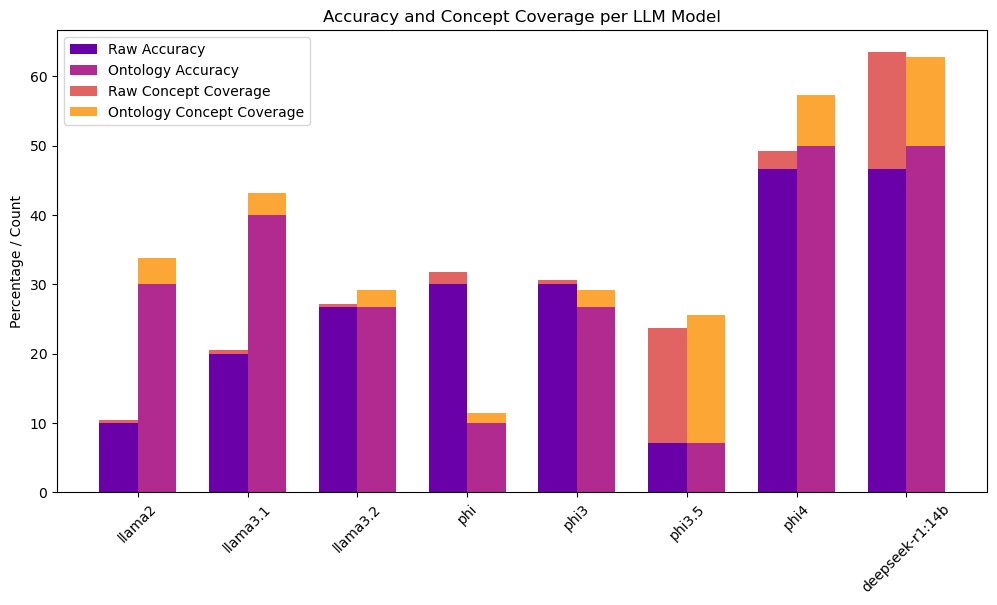

In [203]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data (Replace with actual file path)
with open(YA, "r") as file:
    data = json.load(file)

# Load spaCy model for NER (use a scientific model if available)
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {"raw_correct": 0, "onto_correct": 0, "total": 0, "calc_errors_raw": 0, "calc_errors_onto": 0, "concept_coverage_raw": [], "concept_coverage_onto": []})

for key, item in data.items():
    llm_number = key.split("_")[0]  # Extract LLM identifier (e.g., llama2)
    correct_answer_index = int(item["question"]["answer"])
    options = item['question']['choices']
    correct_answer = options[correct_answer_index]
    raw_response = item["raw_model_response"].lower()
    onto_response = item["onto_model_response"].lower()
    
    # Check correctness
    if correct_answer in raw_response:
        llm_metrics[llm_number]["raw_correct"] += 1
    else:
        llm_metrics[llm_number]["calc_errors_raw"] += 1
    
    if correct_answer in onto_response:
        llm_metrics[llm_number]["onto_correct"] += 1
    else:
        llm_metrics[llm_number]["calc_errors_onto"] += 1
    
    llm_metrics[llm_number]["total"] += 1
    
    # Extract entities for concept coverage
    raw_entities = extract_entities(raw_response)
    onto_entities = extract_entities(onto_response)
    
    llm_metrics[llm_number]["concept_coverage_raw"].append(len(raw_entities))
    llm_metrics[llm_number]["concept_coverage_onto"].append(len(onto_entities))

# Prepare data for plotting
llm_names = []
raw_accuracies = []
onto_accuracies = []
raw_concept_coverages = []
onto_concept_coverages = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    raw_accuracy = metrics["raw_correct"] / total_questions * 100
    onto_accuracy = metrics["onto_correct"] / total_questions * 100
    avg_concept_raw = np.mean(metrics["concept_coverage_raw"])
    avg_concept_onto = np.mean(metrics["concept_coverage_onto"])
    
    llm_names.append(llm)
    raw_accuracies.append(raw_accuracy)
    onto_accuracies.append(onto_accuracy)
    raw_concept_coverages.append(avg_concept_raw)
    onto_concept_coverages.append(avg_concept_onto)

# Plot Accuracy and Concept Coverage in the same figure
plt.figure(figsize=(12, 6))
x = np.arange(len(llm_names))
width = 0.35

# Use Plasma color palette
plasma_colors = sns.color_palette("plasma", 4)

plt.bar(x - width/2, raw_accuracies, width, label="Raw Accuracy", color=plasma_colors[0])
plt.bar(x + width/2, onto_accuracies, width, label="Ontology Accuracy", color=plasma_colors[1])
plt.bar(x - width/2, raw_concept_coverages, width, bottom=raw_accuracies, label="Raw Concept Coverage", color=plasma_colors[2])
plt.bar(x + width/2, onto_concept_coverages, width, bottom=onto_accuracies, label="Ontology Concept Coverage", color=plasma_colors[3])

plt.xticks(x, llm_names, rotation=45)
plt.ylabel("Percentage / Count")
plt.title("Accuracy and Concept Coverage per LLM Model")
plt.legend()
plt.show()

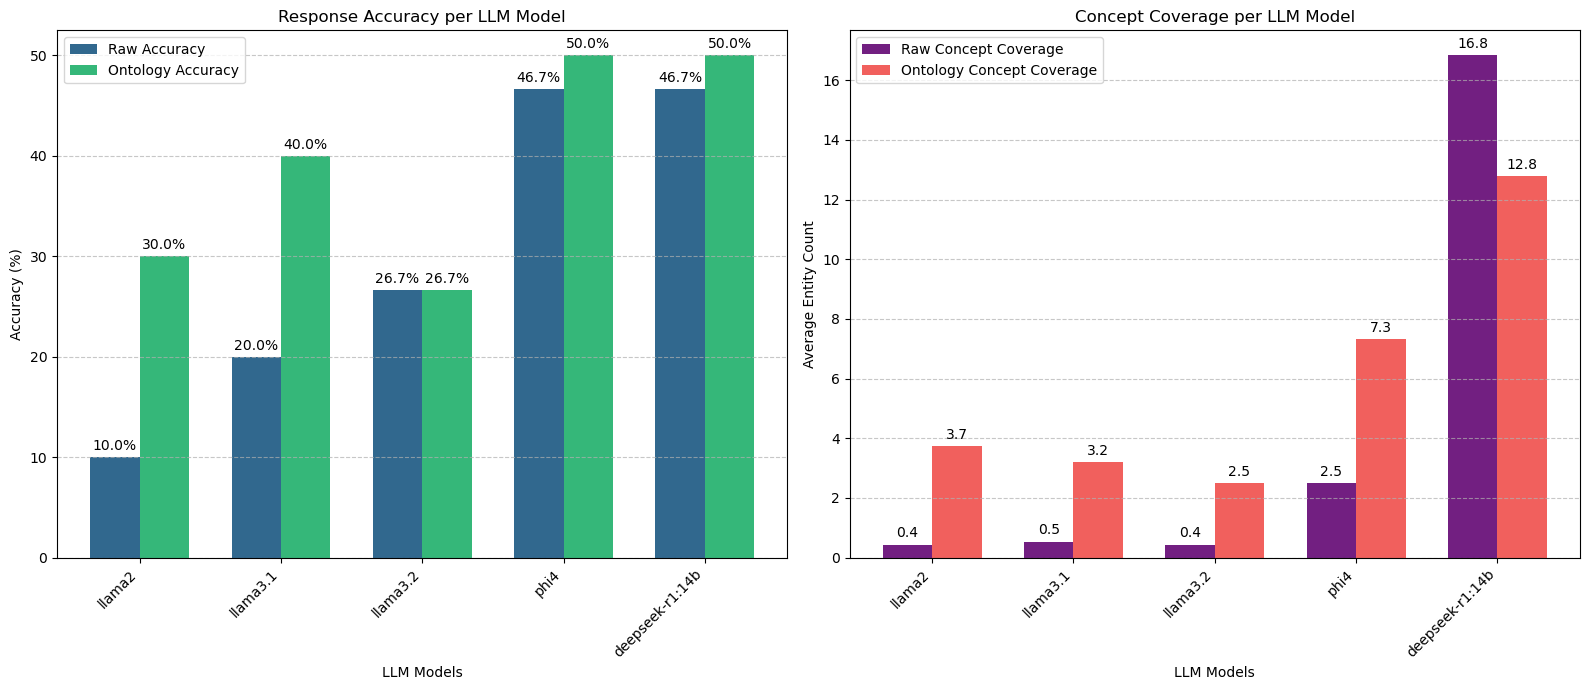

In [221]:

import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data (Replace with actual file path)
with open(YA, "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {"raw_correct": 0, "onto_correct": 0, "total": 0, "calc_errors_raw": 0, "calc_errors_onto": 0, "concept_coverage_raw": [], "concept_coverage_onto": []})

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

for key, item in data.items():
    model_name = key.split("_")[0]  # Extract LLM identifier
    
    # Skip if not in our target list
    if not any(model_name.startswith(target) for target in target_models):
        continue
        
    correct_answer_index = int(item["question"]["answer"])
    options = item['question']['choices']
    correct_answer = options[correct_answer_index]
    raw_response = item["raw_model_response"].lower()
    onto_response = item["onto_model_response"].lower()
    
    # Check correctness
    if correct_answer in raw_response:
        llm_metrics[model_name]["raw_correct"] += 1
    else:
        llm_metrics[model_name]["calc_errors_raw"] += 1
    
    if correct_answer in onto_response:
        llm_metrics[model_name]["onto_correct"] += 1
    else:
        llm_metrics[model_name]["calc_errors_onto"] += 1
    
    llm_metrics[model_name]["total"] += 1
    
    # Extract entities for concept coverage
    raw_entities = extract_entities(raw_response)
    onto_entities = extract_entities(onto_response)
    
    llm_metrics[model_name]["concept_coverage_raw"].append(len(raw_entities))
    llm_metrics[model_name]["concept_coverage_onto"].append(len(onto_entities))

# Prepare data for plotting
llm_names = []
raw_accuracies = []
onto_accuracies = []
raw_concept_coverages = []
onto_concept_coverages = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    raw_accuracy = metrics["raw_correct"] / total_questions * 100
    onto_accuracy = metrics["onto_correct"] / total_questions * 100
    avg_concept_raw = np.mean(metrics["concept_coverage_raw"])
    avg_concept_onto = np.mean(metrics["concept_coverage_onto"])
    
    llm_names.append(llm)
    raw_accuracies.append(raw_accuracy)
    onto_accuracies.append(onto_accuracy)
    raw_concept_coverages.append(avg_concept_raw)
    onto_concept_coverages.append(avg_concept_onto)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, raw_accuracies, width, label="Raw Accuracy", color=accuracy_colors[0])
accuracy_bars2 = ax1.bar(x + width/2, onto_accuracies, width, label="Ontology Accuracy", color=accuracy_colors[1])

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(accuracy_bars1)
add_labels(accuracy_bars2)

# Plot 2: Concept Coverage
concept_bars1 = ax2.bar(x - width/2, raw_concept_coverages, width, label="Raw Concept Coverage", color=concept_colors[0])
concept_bars2 = ax2.bar(x + width/2, onto_concept_coverages, width, label="Ontology Concept Coverage", color=concept_colors[1])

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels_concept(bars):
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels_concept(concept_bars1)
add_labels_concept(concept_bars2)

plt.tight_layout()
plt.savefig('llm_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# trying on response only

In [204]:
YA2 = '/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_response_anno.json'

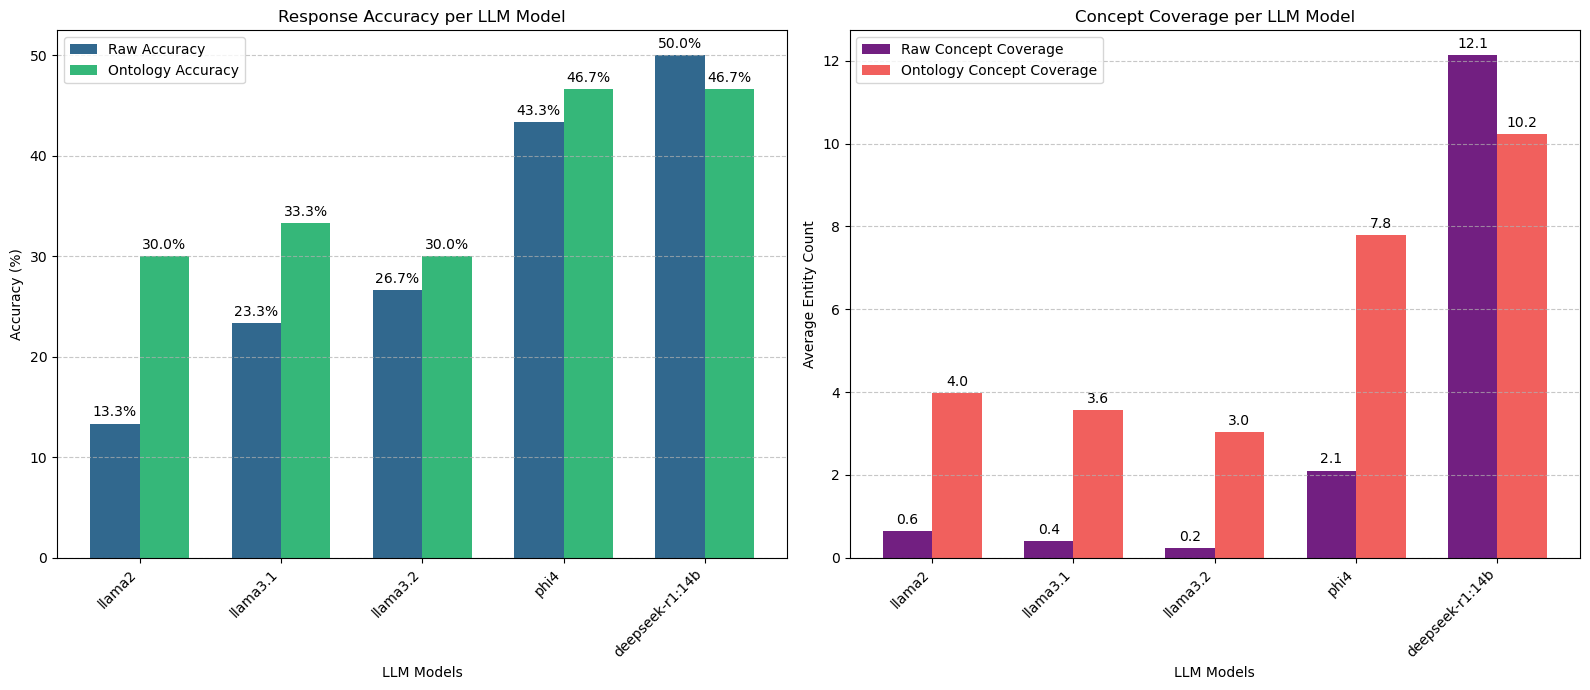

In [247]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data (Replace with actual file path)
with open(YA2, "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {"raw_correct": 0, "onto_correct": 0, "total": 0, "calc_errors_raw": 0, "calc_errors_onto": 0, "concept_coverage_raw": [], "concept_coverage_onto": []})

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

for key, item in data.items():
    model_name = key.split("_")[0]  # Extract LLM identifier
    
    # Skip if not in our target list
    if not any(model_name.startswith(target) for target in target_models):
        continue
        
    correct_answer_index = int(item["question"]["answer"])
    options = item['question']['choices']
    correct_answer = options[correct_answer_index]
    raw_response = item["initial_response"].lower()
    onto_response = item["final_response"].lower()
    
    # Check correctness
    if correct_answer in raw_response:
        llm_metrics[model_name]["raw_correct"] += 1
    else:
        llm_metrics[model_name]["calc_errors_raw"] += 1
    
    if correct_answer in onto_response:
        llm_metrics[model_name]["onto_correct"] += 1
    else:
        llm_metrics[model_name]["calc_errors_onto"] += 1
    
    llm_metrics[model_name]["total"] += 1
    
    # Extract entities for concept coverage
    raw_entities = extract_entities(raw_response)
    onto_entities = extract_entities(onto_response)
    
    llm_metrics[model_name]["concept_coverage_raw"].append(len(raw_entities))
    llm_metrics[model_name]["concept_coverage_onto"].append(len(onto_entities))

# Prepare data for plotting
llm_names = []
raw_accuracies = []
onto_accuracies = []
raw_concept_coverages = []
onto_concept_coverages = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    raw_accuracy = metrics["raw_correct"] / total_questions * 100
    onto_accuracy = metrics["onto_correct"] / total_questions * 100
    avg_concept_raw = np.mean(metrics["concept_coverage_raw"])
    avg_concept_onto = np.mean(metrics["concept_coverage_onto"])
    
    llm_names.append(llm)
    raw_accuracies.append(raw_accuracy)
    onto_accuracies.append(onto_accuracy)
    raw_concept_coverages.append(avg_concept_raw)
    onto_concept_coverages.append(avg_concept_onto)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, raw_accuracies, width, label="Raw Accuracy", color=accuracy_colors[0])
accuracy_bars2 = ax1.bar(x + width/2, onto_accuracies, width, label="Ontology Accuracy", color=accuracy_colors[1])

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(accuracy_bars1)
add_labels(accuracy_bars2)

# Plot 2: Concept Coverage
concept_bars1 = ax2.bar(x - width/2, raw_concept_coverages, width, label="Raw Concept Coverage", color=concept_colors[0])
concept_bars2 = ax2.bar(x + width/2, onto_concept_coverages, width, label="Ontology Concept Coverage", color=concept_colors[1])

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels_concept(bars):
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels_concept(concept_bars1)
add_labels_concept(concept_bars2)

plt.tight_layout()
plt.savefig('llm_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


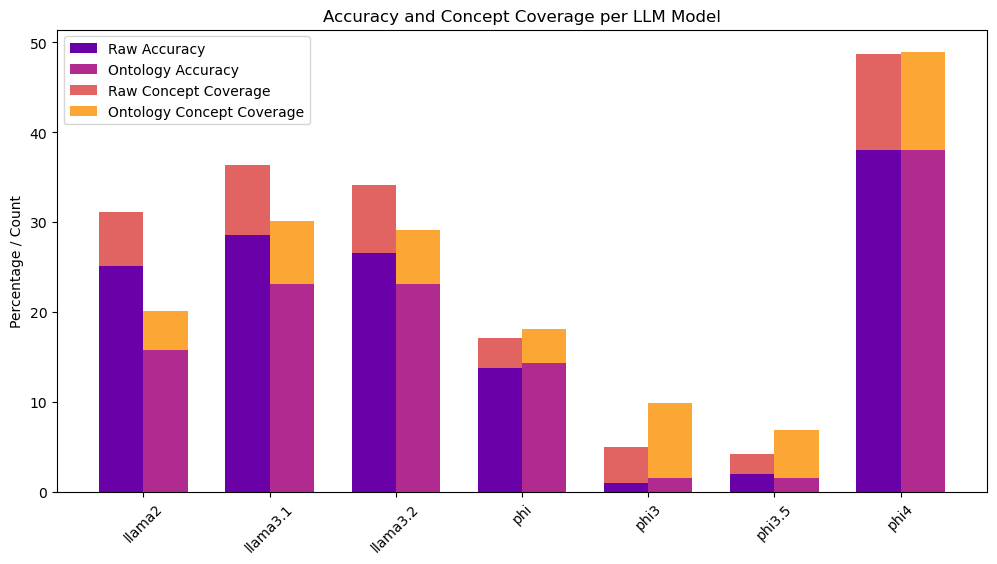

In [152]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data (Replace with actual file path)
with open(YA2, "r") as file:
    data = json.load(file)

# Load spaCy model for NER (use a scientific model if available)
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {"raw_correct": 0, "onto_correct": 0, "total": 0, "calc_errors_raw": 0, "calc_errors_onto": 0, "concept_coverage_raw": [], "concept_coverage_onto": []})

for key, item in data.items():
    llm_number = key.split("_")[0]  # Extract LLM identifier (e.g., llama2)
    correct_answer_index = int(item["question"]["answer"])
    options = item['question']['choices']
    correct_answer = options[correct_answer_index]
    
    raw_response = item["initial_response"].lower()
    onto_response = item["final_response"].lower()
    
    # Check correctness
    if correct_answer in raw_response:
        llm_metrics[llm_number]["raw_correct"] += 1
    else:
        llm_metrics[llm_number]["calc_errors_raw"] += 1
    
    if correct_answer in onto_response:
        llm_metrics[llm_number]["onto_correct"] += 1
    else:
        llm_metrics[llm_number]["calc_errors_onto"] += 1
    
    llm_metrics[llm_number]["total"] += 1
    
    # Extract entities for concept coverage
    raw_entities = extract_entities(raw_response)
    onto_entities = extract_entities(onto_response)
    
    llm_metrics[llm_number]["concept_coverage_raw"].append(len(raw_entities))
    llm_metrics[llm_number]["concept_coverage_onto"].append(len(onto_entities))

# Prepare data for plotting
llm_names = []
raw_accuracies = []
onto_accuracies = []
raw_concept_coverages = []
onto_concept_coverages = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    raw_accuracy = metrics["raw_correct"] / total_questions * 100
    onto_accuracy = metrics["onto_correct"] / total_questions * 100
    avg_concept_raw = np.mean(metrics["concept_coverage_raw"])
    avg_concept_onto = np.mean(metrics["concept_coverage_onto"])
    
    llm_names.append(llm)
    raw_accuracies.append(raw_accuracy)
    onto_accuracies.append(onto_accuracy)
    raw_concept_coverages.append(avg_concept_raw)
    onto_concept_coverages.append(avg_concept_onto)

# Plot Accuracy and Concept Coverage in the same figure
plt.figure(figsize=(12, 6))
x = np.arange(len(llm_names))
width = 0.35

# Use Plasma color palette
plasma_colors = sns.color_palette("plasma", 4)

plt.bar(x - width/2, raw_accuracies, width, label="Raw Accuracy", color=plasma_colors[0])
plt.bar(x + width/2, onto_accuracies, width, label="Ontology Accuracy", color=plasma_colors[1])
plt.bar(x - width/2, raw_concept_coverages, width, bottom=raw_accuracies, label="Raw Concept Coverage", color=plasma_colors[2])
plt.bar(x + width/2, onto_concept_coverages, width, bottom=onto_accuracies, label="Ontology Concept Coverage", color=plasma_colors[3])

plt.xticks(x, llm_names, rotation=45)
plt.ylabel("Percentage / Count")
plt.title("Accuracy and Concept Coverage per LLM Model")
plt.legend()
plt.show()


# trying on question and answer

In [4]:
YA3 = '/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_dual_anno.json'

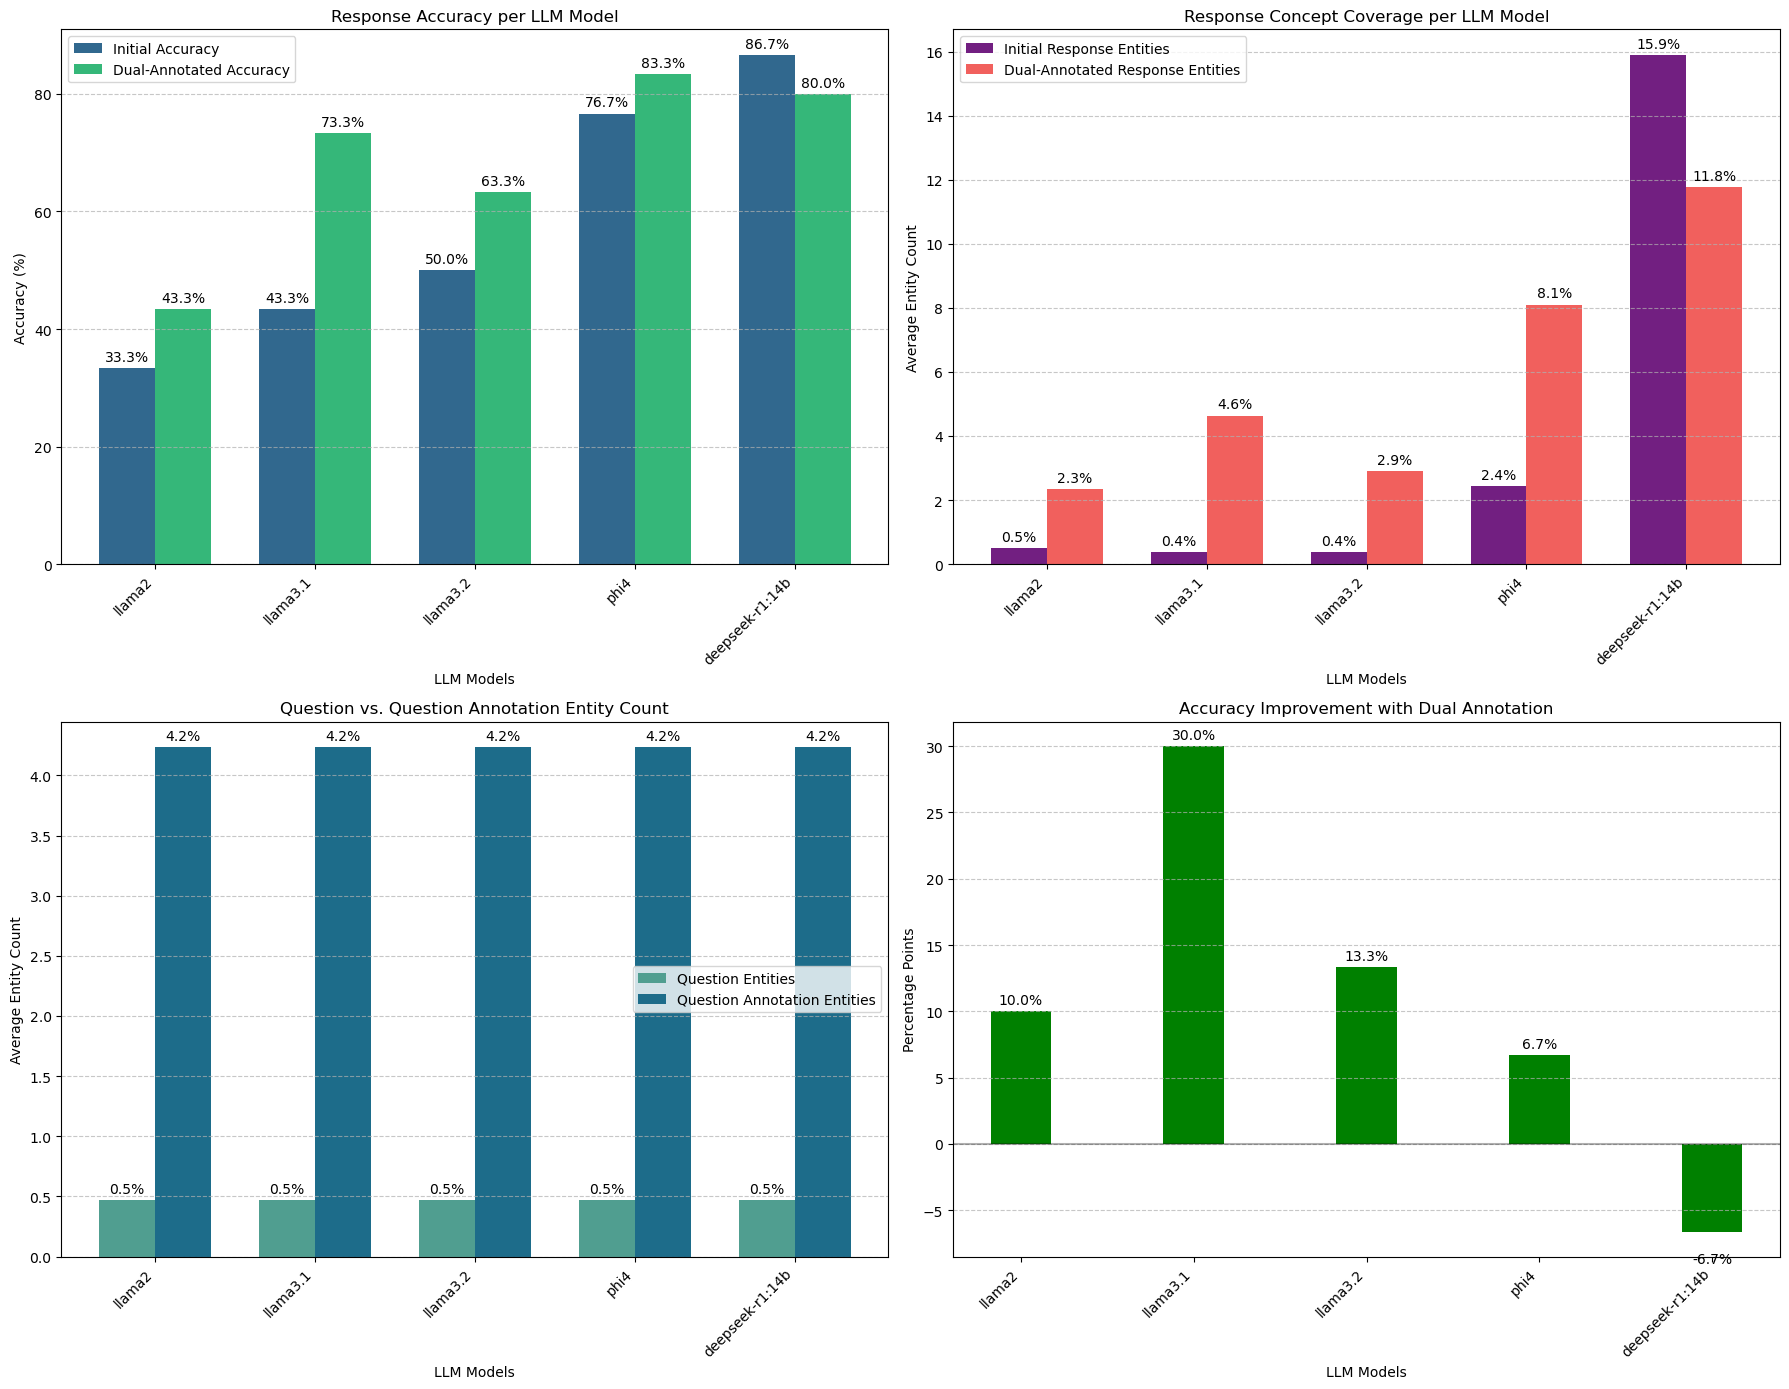


SUMMARY STATISTICS:
--------------------------------------------------
Model      | Initial Acc  | Final Acc    | Improvement 
--------------------------------------------------
llama2     | 33.3        % | 43.3        % | +10.0       %
llama3.1   | 43.3        % | 73.3        % | +30.0       %
llama3.2   | 50.0        % | 63.3        % | +13.3       %
phi4       | 76.7        % | 83.3        % | +6.7        %
deepseek-r1:14b | 86.7        % | 80.0        % | -6.7        %


In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data from dual annotation experiment
with open(YA3, "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {
    "initial_correct": 0,         # Initial response correctness
    "final_correct": 0,           # Final response with dual annotation
    "total": 0,                   # Total questions
    "concept_coverage_initial": [],  # Entity counts in initial response
    "concept_coverage_final": [],    # Entity counts in final response
    "question_entities": [],      # Entity counts in questions
    "question_annotation_entities": []  # Entity counts in question annotations
})

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

for key, item in data.items():
    model_name = key.split("_")[0]  # Extract LLM identifier
    
    # Skip if not in our target list
    if not any(model_name.startswith(target) for target in target_models):
        continue
    
    try:    
        correct_answer_index = int(item["question"]["answer"])
        options = item['question']['choices']
        correct_answer = options[correct_answer_index]
        
        initial_response = item["initial_response"].lower()
        final_response = item["final_response"].lower()
        question_text = item["question"]["text"].lower()
        
        # Get question annotation if available
        question_annotation = item.get("question_annotation", "")
        
        # Check correctness
        if correct_answer.lower() in initial_response:
            llm_metrics[model_name]["initial_correct"] += 1
        
        if correct_answer.lower() in final_response:
            llm_metrics[model_name]["final_correct"] += 1
        
        llm_metrics[model_name]["total"] += 1
        
        # Extract entities for concept coverage
        initial_entities = extract_entities(initial_response)
        final_entities = extract_entities(final_response)
        question_entities = extract_entities(question_text)
        question_anno_entities = extract_entities(str(question_annotation))
        
        llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
        llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
        llm_metrics[model_name]["question_entities"].append(len(question_entities))
        llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
    
    except (KeyError, IndexError, ValueError) as e:
        print(f"Error processing {key}: {e}")
        continue

# Prepare data for plotting
llm_names = []
initial_accuracies = []
final_accuracies = []
initial_concept_coverages = []
final_concept_coverages = []
question_entity_counts = []
question_anno_entity_counts = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    if total_questions == 0:
        print(f"Skipping {llm} - no valid data")
        continue
        
    initial_accuracy = metrics["initial_correct"] / total_questions * 100
    final_accuracy = metrics["final_correct"] / total_questions * 100
    avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
    avg_concept_final = np.mean(metrics["concept_coverage_final"])
    avg_question_entities = np.mean(metrics["question_entities"])
    avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
    
    llm_names.append(llm)
    initial_accuracies.append(initial_accuracy)
    final_accuracies.append(final_accuracy)
    initial_concept_coverages.append(avg_concept_initial)
    final_concept_coverages.append(avg_concept_final)
    question_entity_counts.append(avg_question_entities)
    question_anno_entity_counts.append(avg_question_anno_entities)

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", color=accuracy_colors[0])
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", color=accuracy_colors[1])

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", color=concept_colors[0])
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", color=concept_colors[1])

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", color=question_colors[0])
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", color=question_colors[1])

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
accuracy_improvements = np.array(final_accuracies) - np.array(initial_accuracies)
concept_increases = np.array(final_concept_coverages) - np.array(initial_concept_coverages)

improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", color='green')
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS:")
print("-" * 50)
print(f"{'Model':<10} | {'Initial Acc':<12} | {'Final Acc':<12} | {'Improvement':<12}")
print("-" * 50)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<12.1f}% | {final_accuracies[i]:<12.1f}% | {accuracy_improvements[i]:<+12.1f}%")

# For full highschool set on question annotation only 

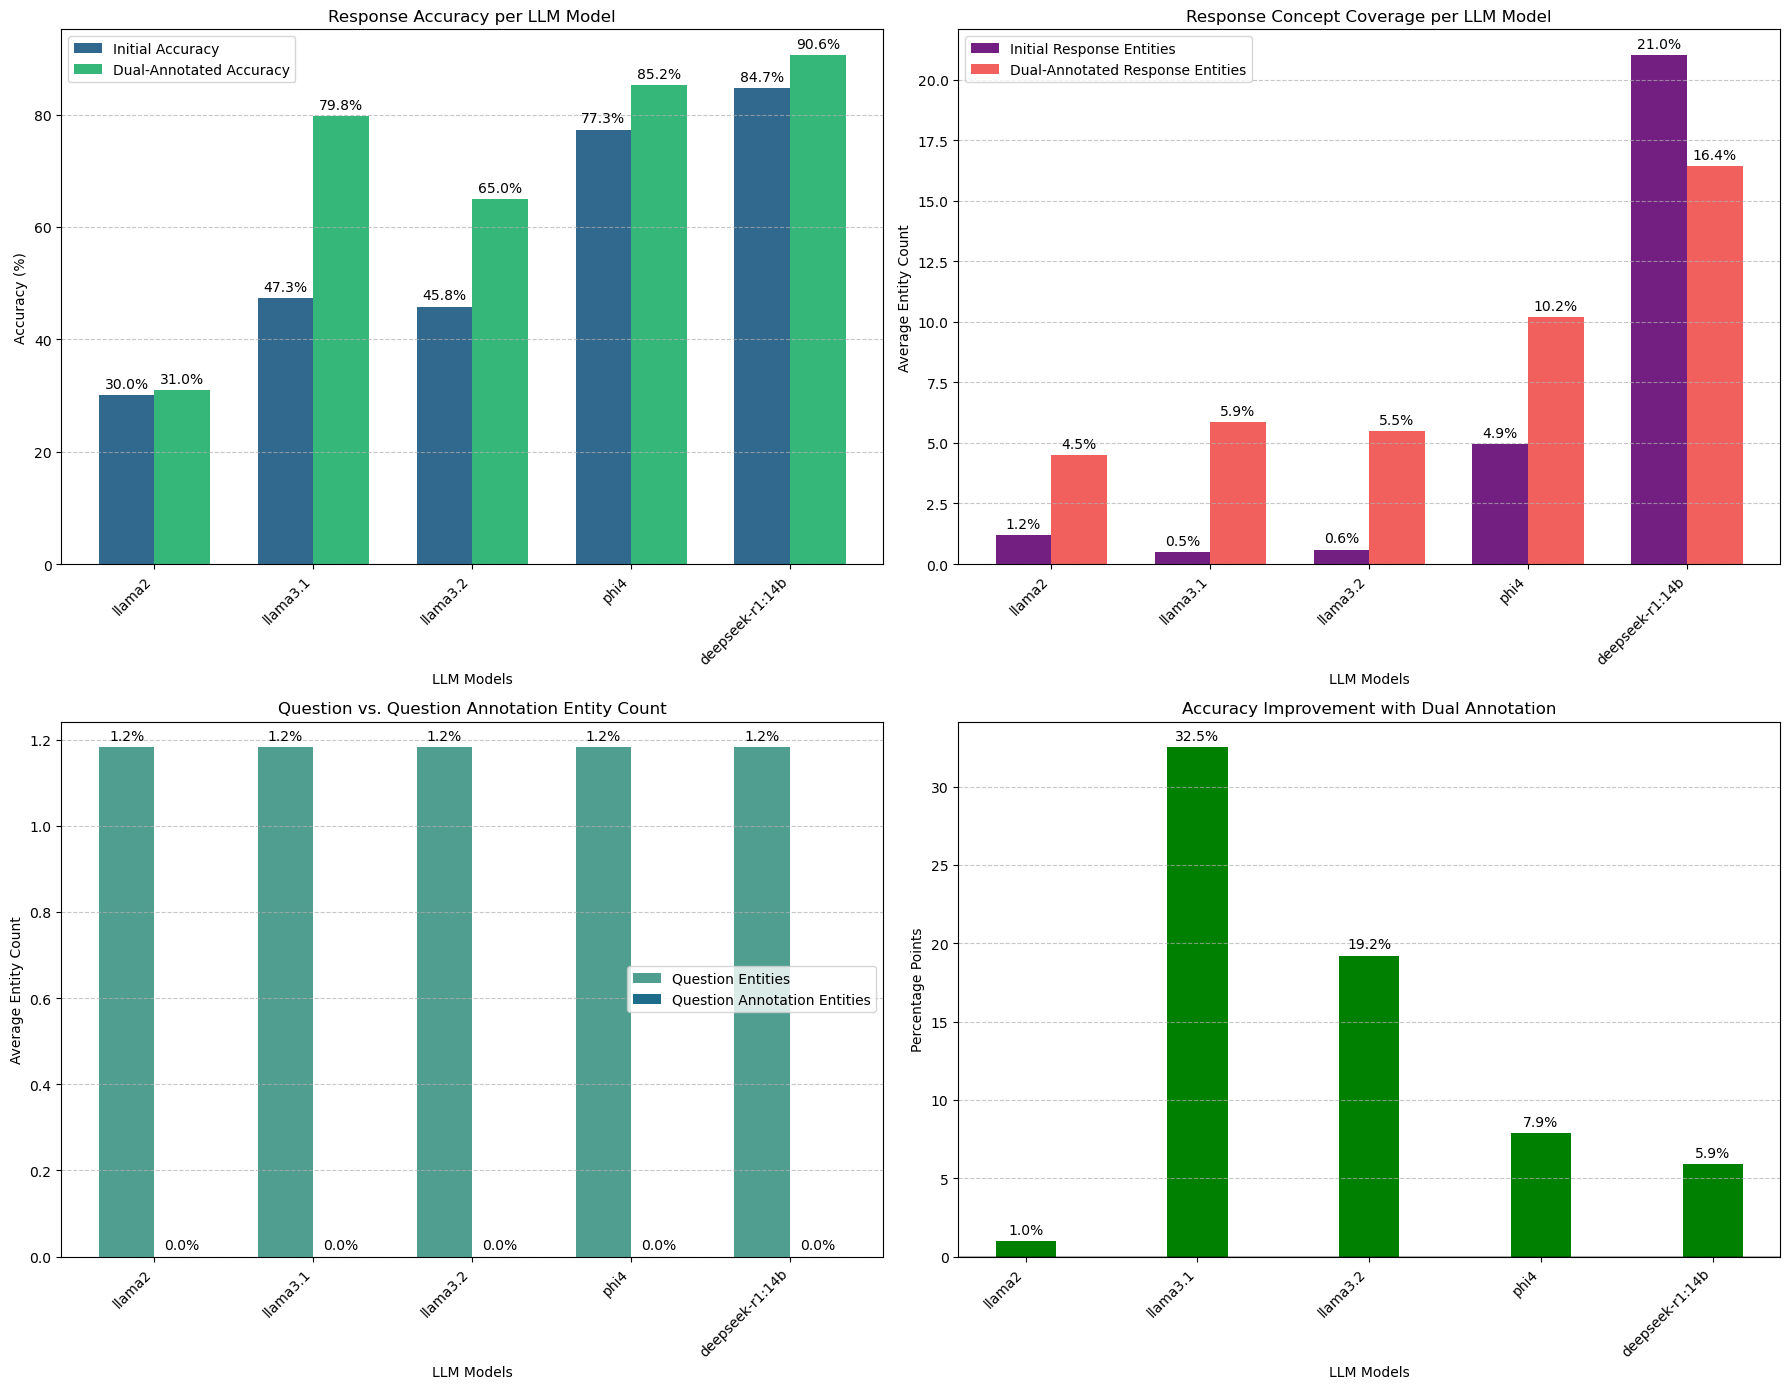


SUMMARY STATISTICS:
--------------------------------------------------
Model      | Initial Acc  | Final Acc    | Improvement 
--------------------------------------------------
llama2     | 30.0        % | 31.0        % | +1.0        %
llama3.1   | 47.3        % | 79.8        % | +32.5       %
llama3.2   | 45.8        % | 65.0        % | +19.2       %
phi4       | 77.3        % | 85.2        % | +7.9        %
deepseek-r1:14b | 84.7        % | 90.6        % | +5.9        %


In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data from dual annotation experiment
with open("/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json", "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {
    "initial_correct": 0,         # Initial response correctness
    "final_correct": 0,           # Final response with dual annotation
    "total": 0,                   # Total questions
    "concept_coverage_initial": [],  # Entity counts in initial response
    "concept_coverage_final": [],    # Entity counts in final response
    "question_entities": [],      # Entity counts in questions
    "question_annotation_entities": []  # Entity counts in question annotations
})

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

for key, item in data.items():
    model_name = key.split("_")[0]  # Extract LLM identifier
    
    # Skip if not in our target list
    if not any(model_name.startswith(target) for target in target_models):
        continue
    
    try:    
        correct_answer_index = int(item["question"]["answer"])
        options = item['question']['choices']
        correct_answer = options[correct_answer_index]
        
        initial_response = item["raw_model_response"].lower()
        final_response = item["onto_model_response"].lower()
        question_text = item["question"]["text"].lower()
        
        # Get question annotation if available
        question_annotation = item.get("question_annotation", "")
        
        # Check correctness
        if correct_answer.lower() in initial_response:
            llm_metrics[model_name]["initial_correct"] += 1
        
        if correct_answer.lower() in final_response:
            llm_metrics[model_name]["final_correct"] += 1
        
        llm_metrics[model_name]["total"] += 1
        
        # Extract entities for concept coverage
        initial_entities = extract_entities(initial_response)
        final_entities = extract_entities(final_response)
        question_entities = extract_entities(question_text)
        question_anno_entities = extract_entities(str(question_annotation))
        
        llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
        llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
        llm_metrics[model_name]["question_entities"].append(len(question_entities))
        llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
    
    except (KeyError, IndexError, ValueError) as e:
        print(f"Error processing {key}: {e}")
        continue

# Prepare data for plotting
llm_names = []
initial_accuracies = []
final_accuracies = []
initial_concept_coverages = []
final_concept_coverages = []
question_entity_counts = []
question_anno_entity_counts = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    if total_questions == 0:
        print(f"Skipping {llm} - no valid data")
        continue
        
    initial_accuracy = metrics["initial_correct"] / total_questions * 100
    final_accuracy = metrics["final_correct"] / total_questions * 100
    avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
    avg_concept_final = np.mean(metrics["concept_coverage_final"])
    avg_question_entities = np.mean(metrics["question_entities"])
    avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
    
    llm_names.append(llm)
    initial_accuracies.append(initial_accuracy)
    final_accuracies.append(final_accuracy)
    initial_concept_coverages.append(avg_concept_initial)
    final_concept_coverages.append(avg_concept_final)
    question_entity_counts.append(avg_question_entities)
    question_anno_entity_counts.append(avg_question_anno_entities)

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", color=accuracy_colors[0])
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", color=accuracy_colors[1])

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", color=concept_colors[0])
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", color=concept_colors[1])

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", color=question_colors[0])
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", color=question_colors[1])

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
accuracy_improvements = np.array(final_accuracies) - np.array(initial_accuracies)
concept_increases = np.array(final_concept_coverages) - np.array(initial_concept_coverages)

improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", color='green')
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS:")
print("-" * 50)
print(f"{'Model':<10} | {'Initial Acc':<12} | {'Final Acc':<12} | {'Improvement':<12}")
print("-" * 50)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<12.1f}% | {final_accuracies[i]:<12.1f}% | {accuracy_improvements[i]:<+12.1f}%")

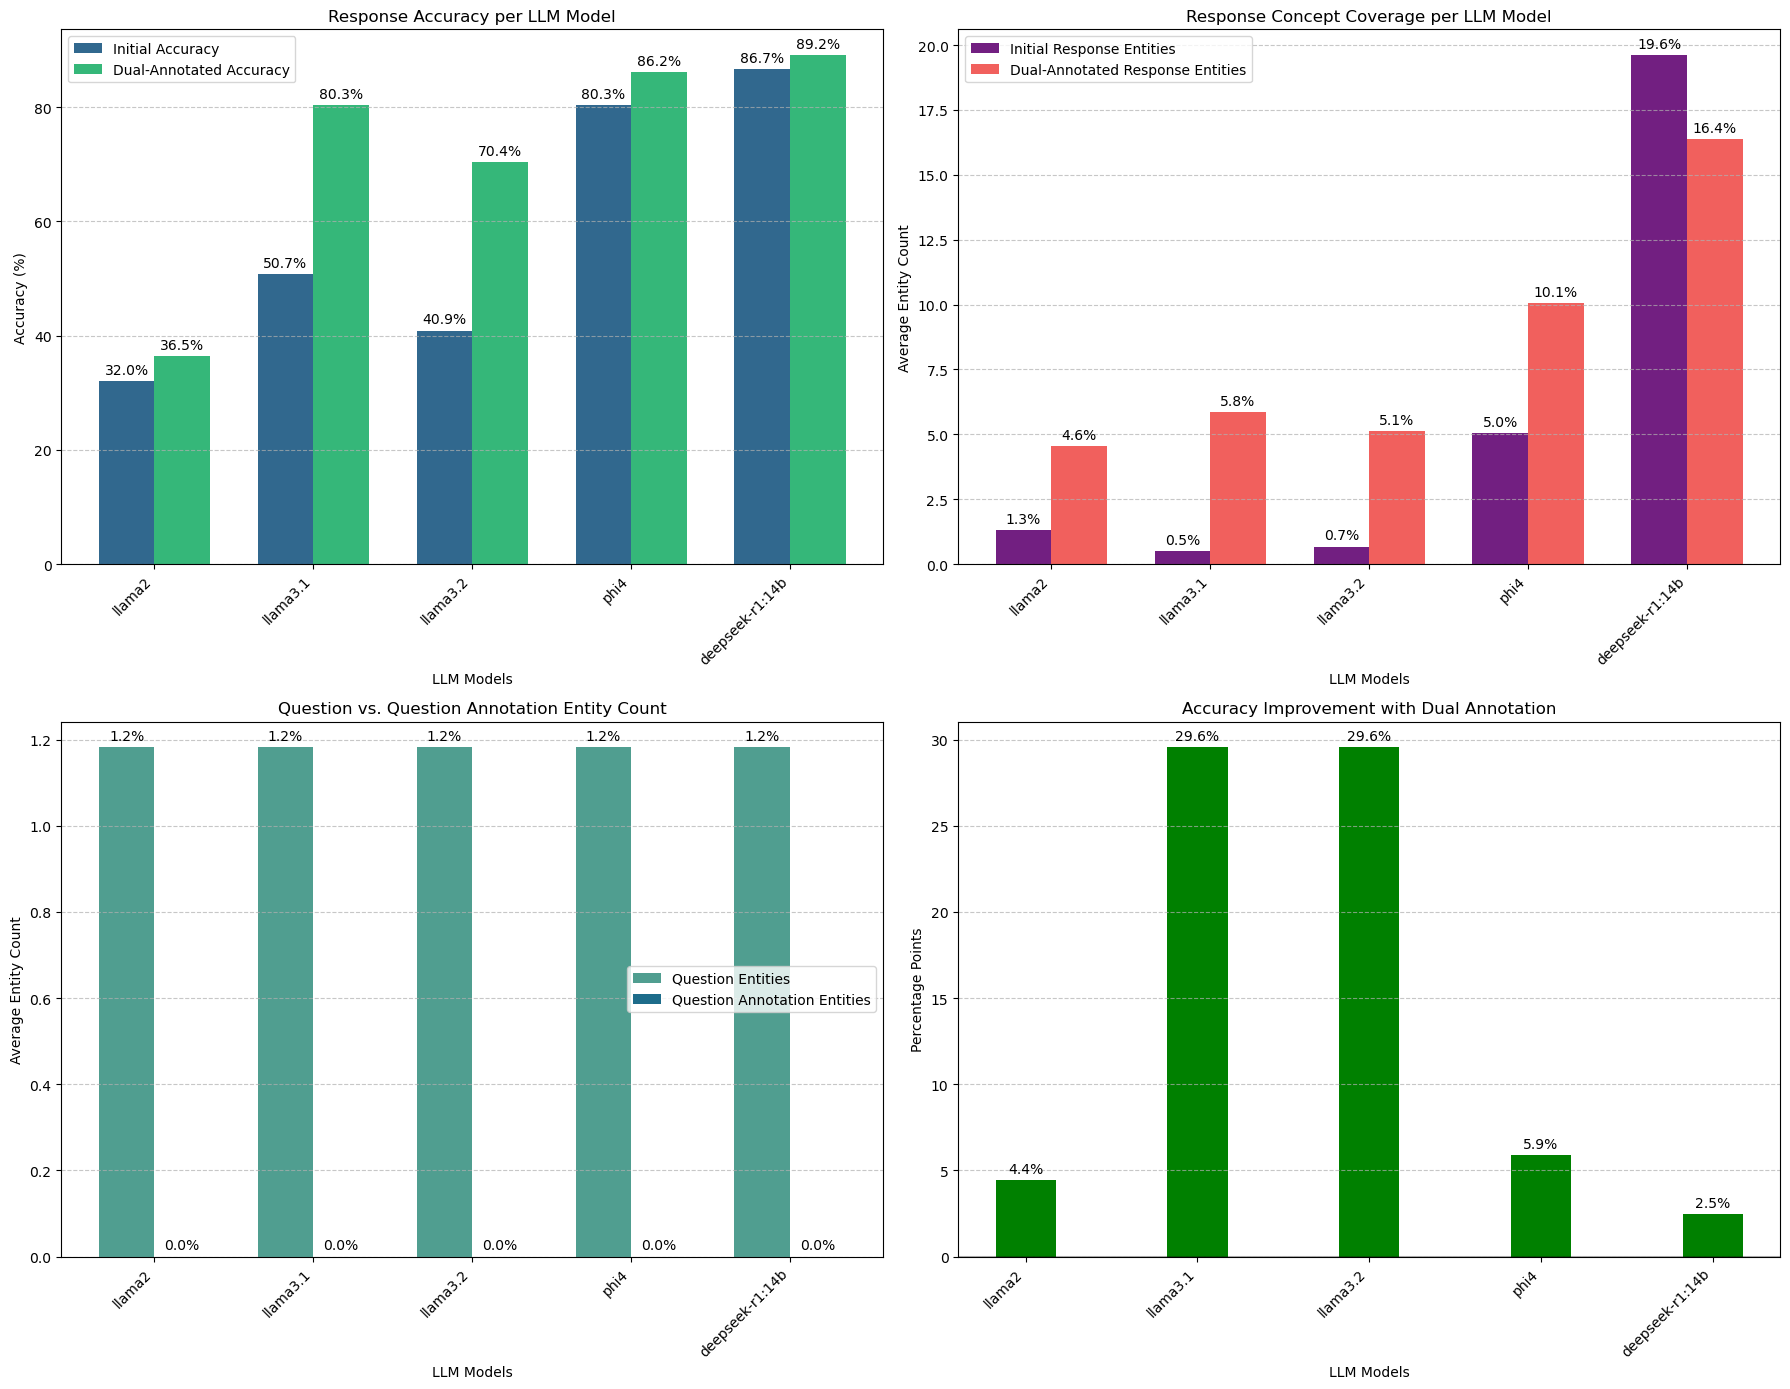


SUMMARY STATISTICS:
--------------------------------------------------
Model      | Initial Acc  | Final Acc    | Improvement 
--------------------------------------------------
llama2     | 32.0        % | 36.5        % | +4.4        %
llama3.1   | 50.7        % | 80.3        % | +29.6       %
llama3.2   | 40.9        % | 70.4        % | +29.6       %
phi4       | 80.3        % | 86.2        % | +5.9        %
deepseek-r1:14b | 86.7        % | 89.2        % | +2.5        %


In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data from dual annotation experiment
with open("/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json", "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {
    "initial_correct": 0,         # Initial response correctness
    "final_correct": 0,           # Final response with dual annotation
    "total": 0,                   # Total questions
    "concept_coverage_initial": [],  # Entity counts in initial response
    "concept_coverage_final": [],    # Entity counts in final response
    "question_entities": [],      # Entity counts in questions
    "question_annotation_entities": []  # Entity counts in question annotations
})

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

for key, item in data.items():
    model_name = key.split("_")[0]  # Extract LLM identifier
    
    # Skip if not in our target list
    if not any(model_name.startswith(target) for target in target_models):
        continue
    
    try:    
        correct_answer_index = int(item["question"]["answer"])
        options = item['question']['choices']
        correct_answer = options[correct_answer_index]
        
        initial_response = item["raw_model_response"].lower()
        final_response = item["onto_model_response"].lower()
        question_text = item["question"]["text"].lower()
        
        # Get question annotation if available
        question_annotation = item.get("question_annotation", "")
        
        # Check correctness
        if correct_answer.lower() in initial_response:
            llm_metrics[model_name]["initial_correct"] += 1
        
        if correct_answer.lower() in final_response:
            llm_metrics[model_name]["final_correct"] += 1
        
        llm_metrics[model_name]["total"] += 1
        
        # Extract entities for concept coverage
        initial_entities = extract_entities(initial_response)
        final_entities = extract_entities(final_response)
        question_entities = extract_entities(question_text)
        question_anno_entities = extract_entities(str(question_annotation))
        
        llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
        llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
        llm_metrics[model_name]["question_entities"].append(len(question_entities))
        llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
    
    except (KeyError, IndexError, ValueError) as e:
        print(f"Error processing {key}: {e}")
        continue

# Prepare data for plotting
llm_names = []
initial_accuracies = []
final_accuracies = []
initial_concept_coverages = []
final_concept_coverages = []
question_entity_counts = []
question_anno_entity_counts = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    if total_questions == 0:
        print(f"Skipping {llm} - no valid data")
        continue
        
    initial_accuracy = metrics["initial_correct"] / total_questions * 100
    final_accuracy = metrics["final_correct"] / total_questions * 100
    avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
    avg_concept_final = np.mean(metrics["concept_coverage_final"])
    avg_question_entities = np.mean(metrics["question_entities"])
    avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
    
    llm_names.append(llm)
    initial_accuracies.append(initial_accuracy)
    final_accuracies.append(final_accuracy)
    initial_concept_coverages.append(avg_concept_initial)
    final_concept_coverages.append(avg_concept_final)
    question_entity_counts.append(avg_question_entities)
    question_anno_entity_counts.append(avg_question_anno_entities)

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", color=accuracy_colors[0])
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", color=accuracy_colors[1])

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", color=concept_colors[0])
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", color=concept_colors[1])

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", color=question_colors[0])
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", color=question_colors[1])

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
accuracy_improvements = np.array(final_accuracies) - np.array(initial_accuracies)
concept_increases = np.array(final_concept_coverages) - np.array(initial_concept_coverages)

improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", color='green')
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS:")
print("-" * 50)
print(f"{'Model':<10} | {'Initial Acc':<12} | {'Final Acc':<12} | {'Improvement':<12}")
print("-" * 50)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<12.1f}% | {final_accuracies[i]:<12.1f}% | {accuracy_improvements[i]:<+12.1f}%")

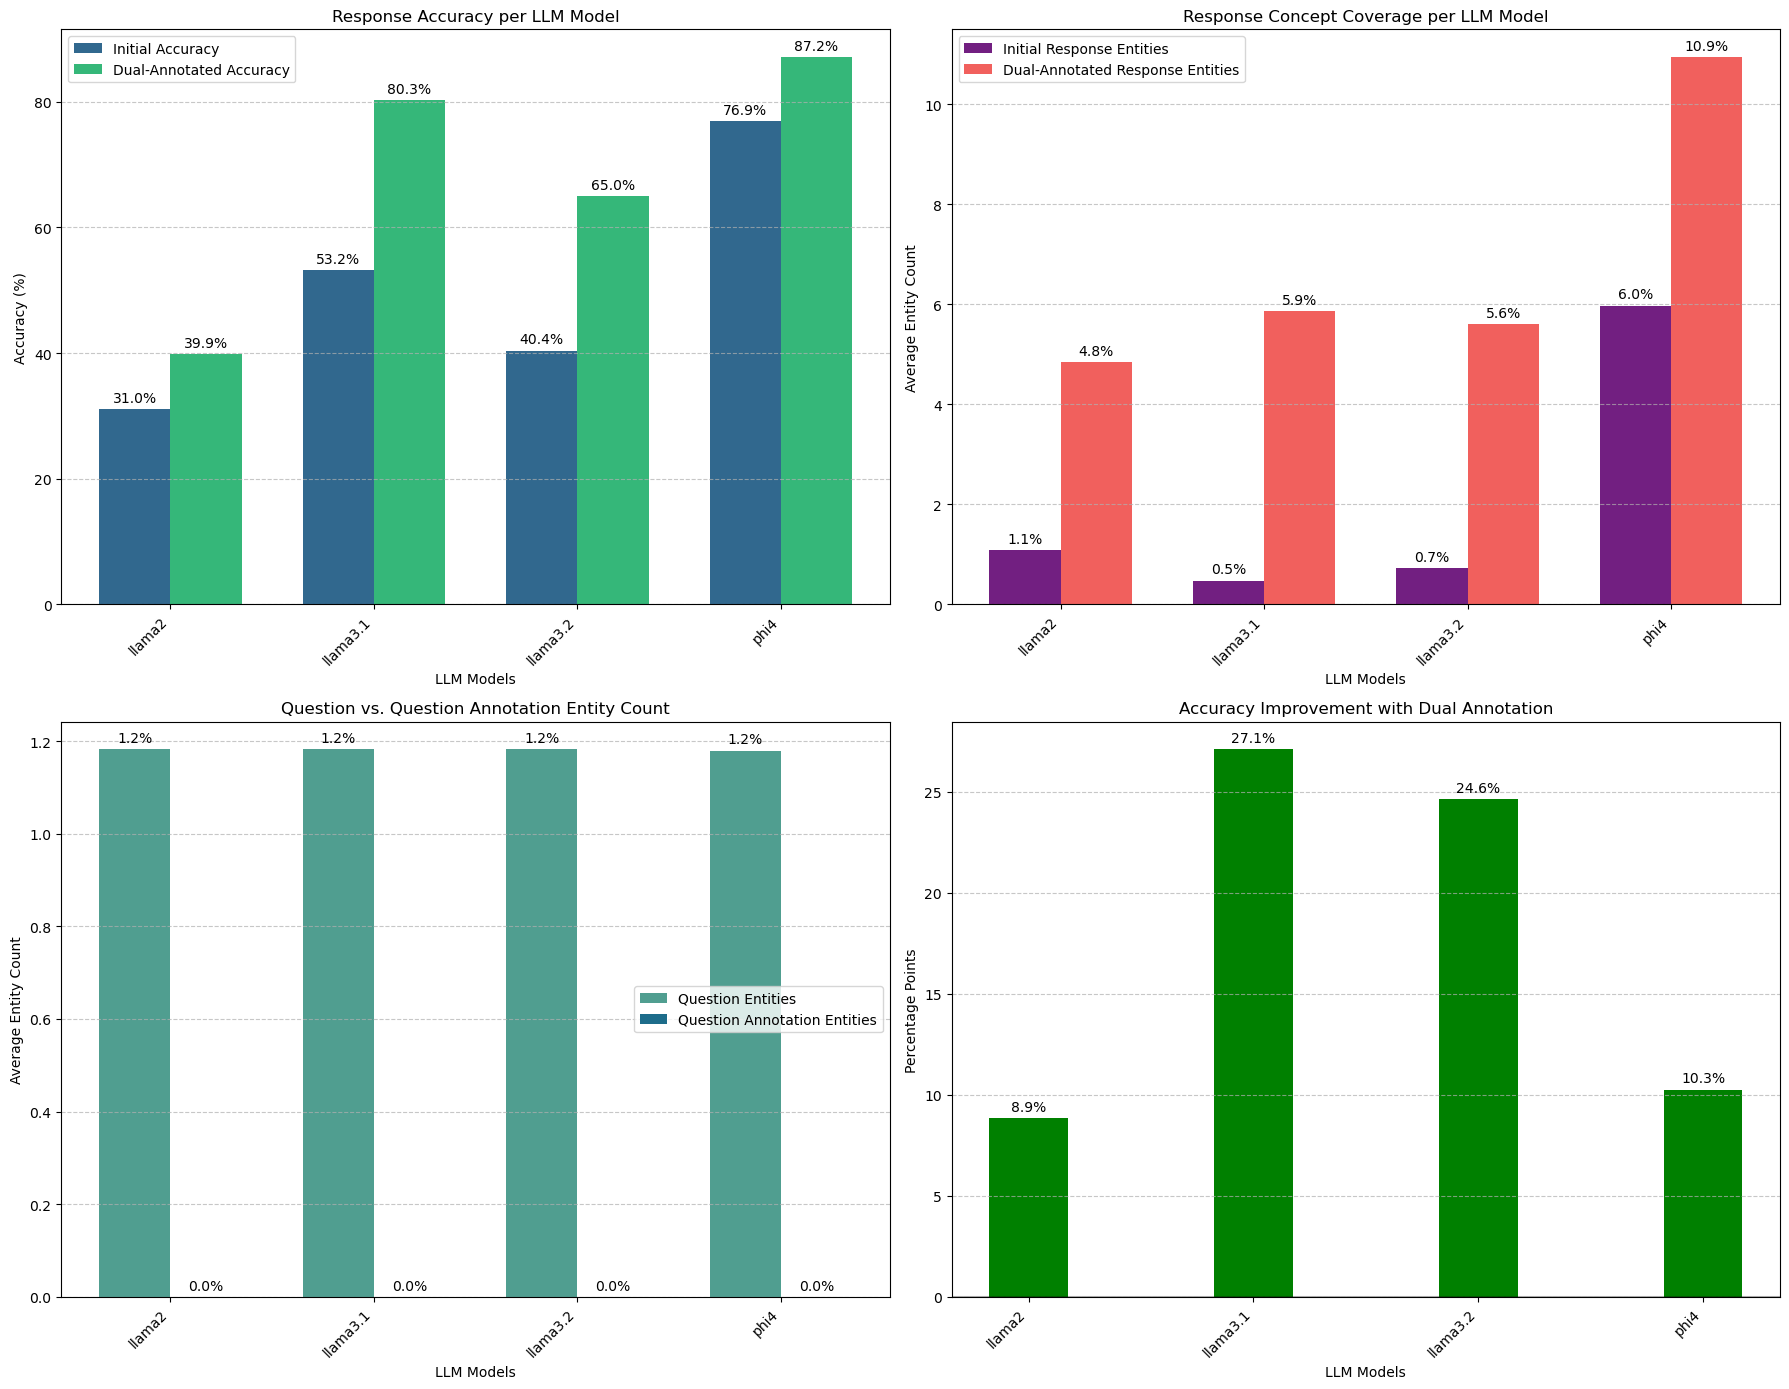


SUMMARY STATISTICS:
--------------------------------------------------
Model      | Initial Acc  | Final Acc    | Improvement 
--------------------------------------------------
llama2     | 31.0        % | 39.9        % | +8.9        %
llama3.1   | 53.2        % | 80.3        % | +27.1       %
llama3.2   | 40.4        % | 65.0        % | +24.6       %
phi4       | 76.9        % | 87.2        % | +10.3       %


In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load JSON data from dual annotation experiment
with open("/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full2.json", "r") as file:
    data = json.load(file)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

# Initialize LLM-based metrics
llm_metrics = defaultdict(lambda: {
    "initial_correct": 0,         # Initial response correctness
    "final_correct": 0,           # Final response with dual annotation
    "total": 0,                   # Total questions
    "concept_coverage_initial": [],  # Entity counts in initial response
    "concept_coverage_final": [],    # Entity counts in final response
    "question_entities": [],      # Entity counts in questions
    "question_annotation_entities": []  # Entity counts in question annotations
})

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

for key, item in data.items():
    model_name = key.split("_")[0]  # Extract LLM identifier
    
    # Skip if not in our target list
    if not any(model_name.startswith(target) for target in target_models):
        continue
    
    try:    
        correct_answer_index = int(item["question"]["answer"])
        options = item['question']['choices']
        correct_answer = options[correct_answer_index]
        
        initial_response = item["raw_model_response"].lower()
        final_response = item["onto_model_response"].lower()
        question_text = item["question"]["text"].lower()
        
        # Get question annotation if available
        question_annotation = item.get("question_annotation", "")
        
        # Check correctness
        if correct_answer.lower() in initial_response:
            llm_metrics[model_name]["initial_correct"] += 1
        
        if correct_answer.lower() in final_response:
            llm_metrics[model_name]["final_correct"] += 1
        
        llm_metrics[model_name]["total"] += 1
        
        # Extract entities for concept coverage
        initial_entities = extract_entities(initial_response)
        final_entities = extract_entities(final_response)
        question_entities = extract_entities(question_text)
        question_anno_entities = extract_entities(str(question_annotation))
        
        llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
        llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
        llm_metrics[model_name]["question_entities"].append(len(question_entities))
        llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
    
    except (KeyError, IndexError, ValueError) as e:
        print(f"Error processing {key}: {e}")
        continue

# Prepare data for plotting
llm_names = []
initial_accuracies = []
final_accuracies = []
initial_concept_coverages = []
final_concept_coverages = []
question_entity_counts = []
question_anno_entity_counts = []

for llm, metrics in llm_metrics.items():
    total_questions = metrics["total"]
    if total_questions == 0:
        print(f"Skipping {llm} - no valid data")
        continue
        
    initial_accuracy = metrics["initial_correct"] / total_questions * 100
    final_accuracy = metrics["final_correct"] / total_questions * 100
    avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
    avg_concept_final = np.mean(metrics["concept_coverage_final"])
    avg_question_entities = np.mean(metrics["question_entities"])
    avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
    
    llm_names.append(llm)
    initial_accuracies.append(initial_accuracy)
    final_accuracies.append(final_accuracy)
    initial_concept_coverages.append(avg_concept_initial)
    final_concept_coverages.append(avg_concept_final)
    question_entity_counts.append(avg_question_entities)
    question_anno_entity_counts.append(avg_question_anno_entities)

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", color=accuracy_colors[0])
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", color=accuracy_colors[1])

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", color=concept_colors[0])
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", color=concept_colors[1])

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", color=question_colors[0])
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", color=question_colors[1])

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
accuracy_improvements = np.array(final_accuracies) - np.array(initial_accuracies)
concept_increases = np.array(final_concept_coverages) - np.array(initial_concept_coverages)

improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", color='green')
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS:")
print("-" * 50)
print(f"{'Model':<10} | {'Initial Acc':<12} | {'Final Acc':<12} | {'Improvement':<12}")
print("-" * 50)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<12.1f}% | {final_accuracies[i]:<12.1f}% | {accuracy_improvements[i]:<+12.1f}%")

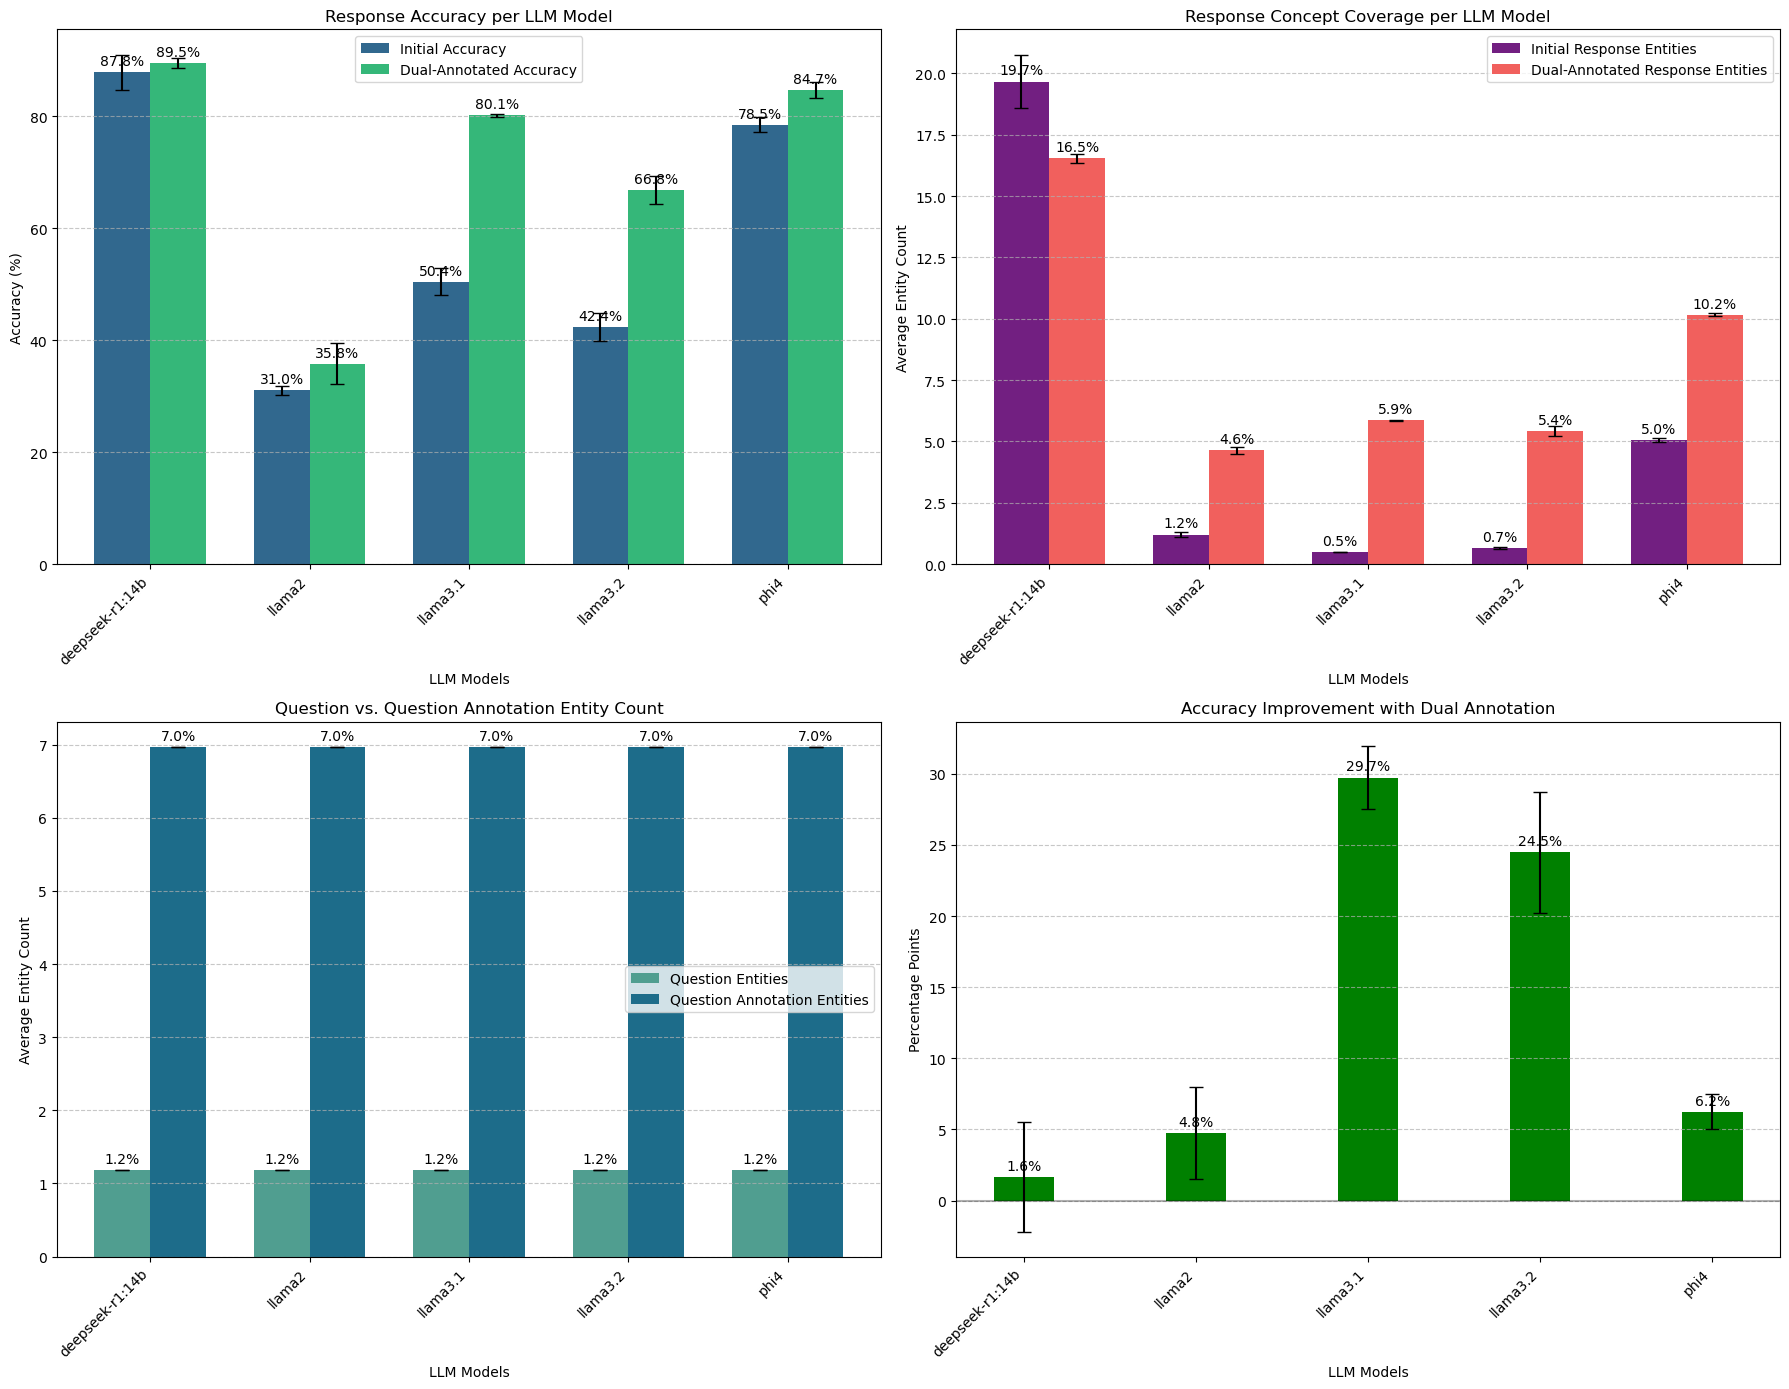


SUMMARY STATISTICS (MEANS ACROSS ALL FILES):
----------------------------------------------------------------------
Model      | Initial Acc      | Final Acc        | Improvement     
----------------------------------------------------------------------
deepseek-r1:14b | 87.8  % ±3.1   % | 89.5  % ±0.8   % | +1.6  % ±3.9   %
llama2     | 31.0  % ±0.8   % | 35.8  % ±3.6   % | +4.8  % ±3.2   %
llama3.1   | 50.4  % ±2.4   % | 80.1  % ±0.2   % | +29.7 % ±2.2   %
llama3.2   | 42.4  % ±2.4   % | 66.8  % ±2.6   % | +24.5 % ±4.2   %
phi4       | 78.5  % ±1.3   % | 84.7  % ±1.5   % | +6.2  % ±1.2   %


In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        model_name = key.split("_")[0]  # Extract LLM identifier
        
        # Skip if not in our target list
        if not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:    
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available
            question_annotation = item.get("question_annotation", "")
            if not question_annotation and "OntologyInfo" in item:
                question_annotation = item.get("OntologyInfo", "")
            
            # Check correctness
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# File paths
file_paths = [
    "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json",
    "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json",
    "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full2.json"
]

# Filter for specific models only
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

# Process all files
all_files_metrics = []
for file_path in file_paths:
    file_metrics = process_file(file_path, target_models)
    if file_metrics:
        aggregated_metrics = calculate_metrics_from_file(file_metrics)
        all_files_metrics.append(aggregated_metrics)
    else:
        print(f"Skipping file {file_path} due to errors")

# Get all unique models from all files
all_models = set()
for metrics in all_files_metrics:
    all_models.update(metrics.keys())
all_models = sorted(list(all_models))

# Calculate means and standard deviations across files
mean_metrics = {}
std_metrics = {}

for model in all_models:
    # Initialize containers for values across files
    initial_accuracies = []
    final_accuracies = []
    initial_coverages = []
    final_coverages = []
    question_entities = []
    question_anno_entities = []
    accuracy_improvements = []
    
    # Collect values from each file
    for file_metrics in all_files_metrics:
        if model in file_metrics:
            initial_accuracies.append(file_metrics[model]["initial_accuracy"])
            final_accuracies.append(file_metrics[model]["final_accuracy"])
            initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
            final_coverages.append(file_metrics[model]["final_concept_coverage"])
            question_entities.append(file_metrics[model]["question_entities"])
            question_anno_entities.append(file_metrics[model]["question_anno_entities"])
            accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
    
    # Calculate means and standard deviations
    # Only calculate if we have data from at least one file
    if initial_accuracies:
        mean_metrics[model] = {
            "initial_accuracy": np.mean(initial_accuracies),
            "final_accuracy": np.mean(final_accuracies),
            "initial_concept_coverage": np.mean(initial_coverages),
            "final_concept_coverage": np.mean(final_coverages),
            "question_entities": np.mean(question_entities),
            "question_anno_entities": np.mean(question_anno_entities),
            "accuracy_improvement": np.mean(accuracy_improvements)
        }
        
        std_metrics[model] = {
            "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
            "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
            "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
            "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
            "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
            "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
            "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
        }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

Loading pre-computed metrics from llm_metrics_data.json
Metrics data saved to llm_metrics_data.json


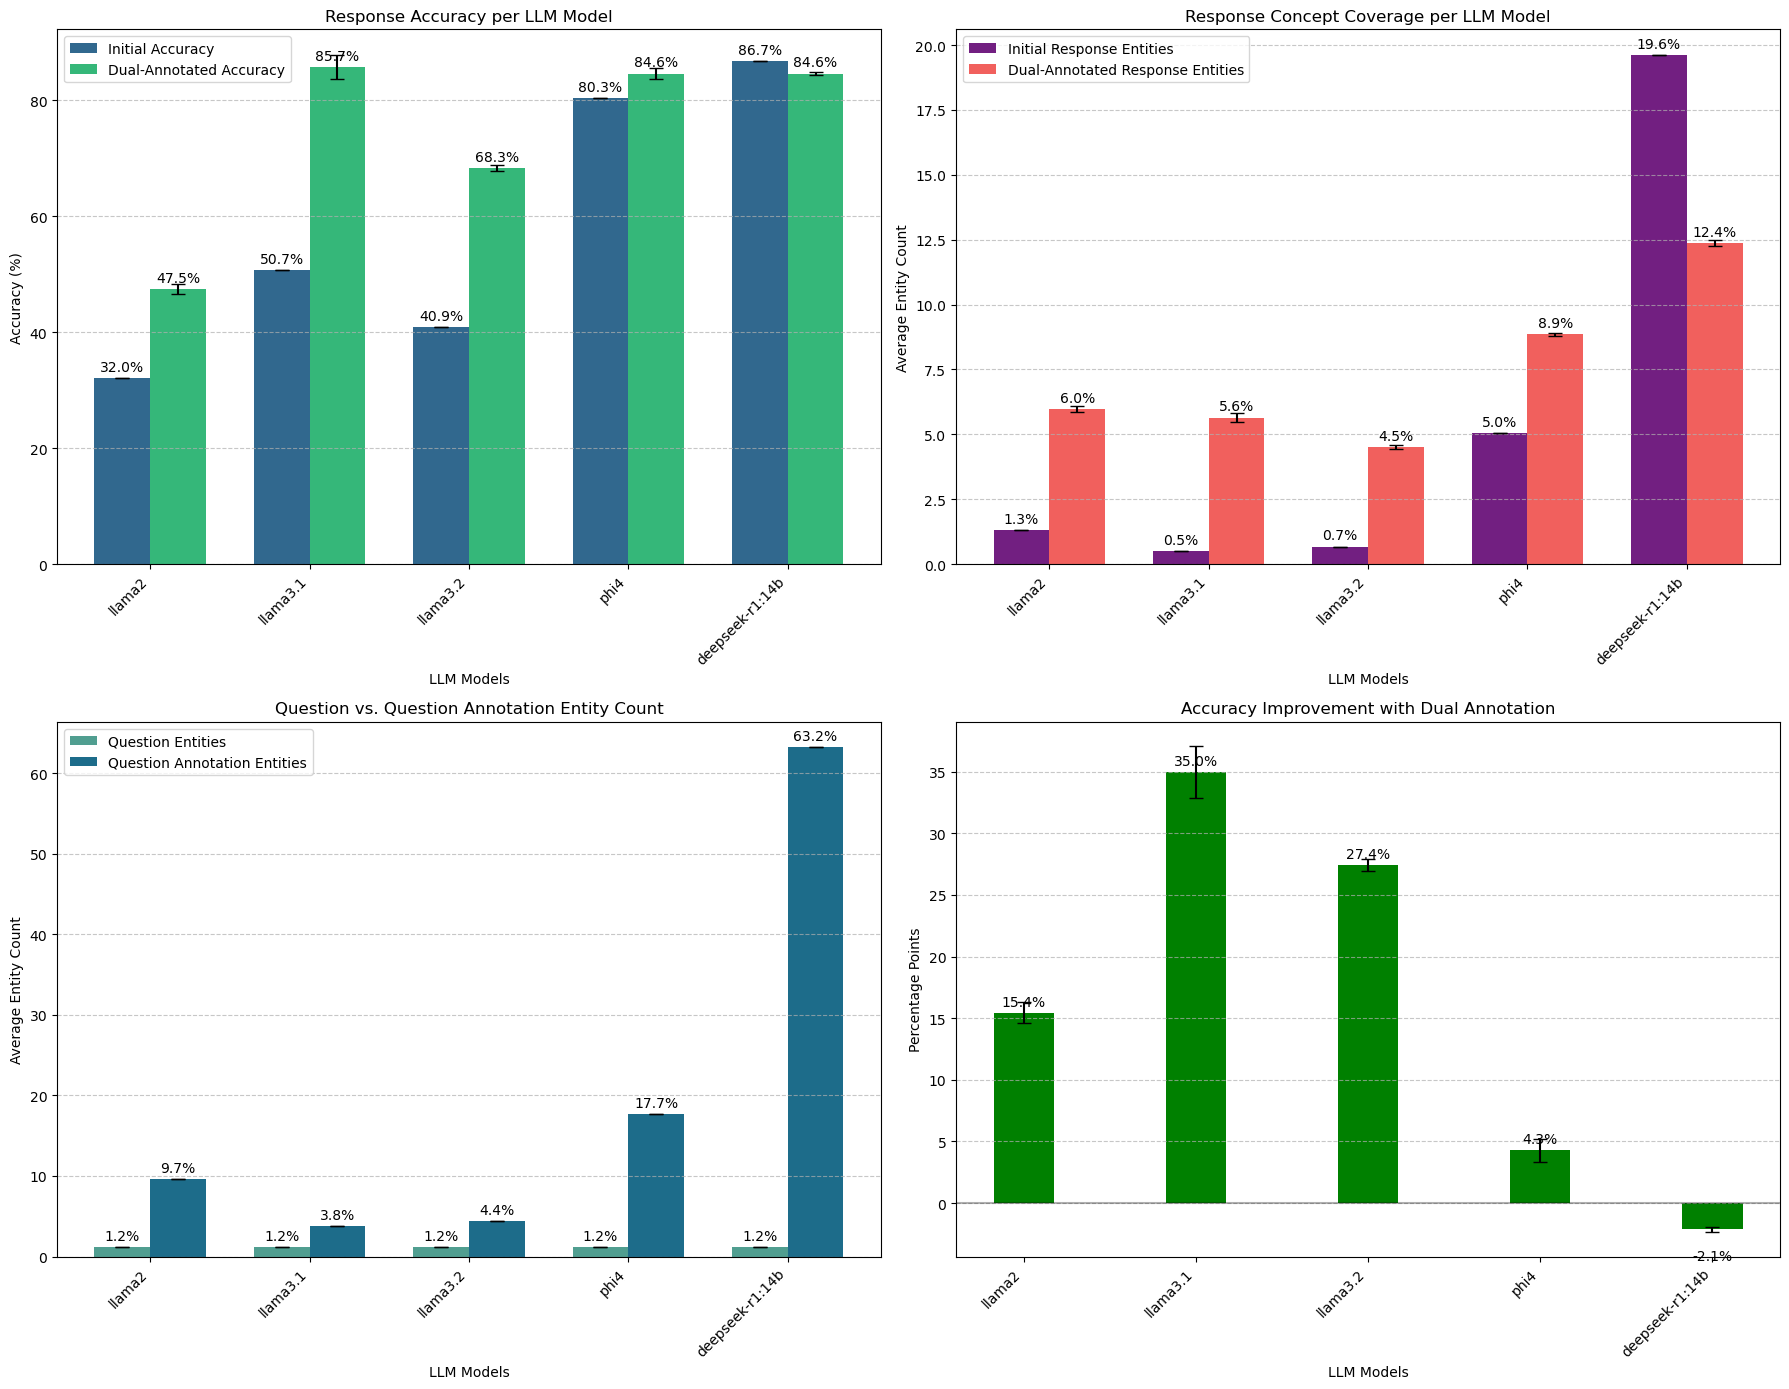


SUMMARY STATISTICS (MEANS ACROSS ALL FILES):
----------------------------------------------------------------------
Model      | Initial Acc      | Final Acc        | Improvement     
----------------------------------------------------------------------
llama2     | 32.0  % ±0.0   % | 47.5  % ±0.8   % | +15.4 % ±0.8   %
llama3.1   | 50.7  % ±0.0   % | 85.7  % ±2.1   % | +35.0 % ±2.1   %
llama3.2   | 40.9  % ±0.0   % | 68.3  % ±0.5   % | +27.4 % ±0.5   %
phi4       | 80.3  % ±0.0   % | 84.6  % ±0.9   % | +4.3  % ±0.9   %
deepseek-r1:14b | 86.7  % ±0.0   % | 84.6  % ±0.2   % | -2.1  % ±0.2   %


In [11]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        model_name = key.split("_")[0]  # Extract LLM identifier
        
        # Skip if not in our target list
        if not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:    
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available
            question_annotation = item.get("question_annotation", "")
            if not question_annotation and "OntologyInfo" in item:
                question_annotation = item.get("OntologyInfo", "")
            
            # Check correctness
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# Check if pre-computed metrics exist
import os

metrics_cache_file = 'llm_metrics_data.json'
if os.path.exists(metrics_cache_file):
    print(f"Loading pre-computed metrics from {metrics_cache_file}")
    try:
        with open(metrics_cache_file, 'r') as f:
            cached_data = json.load(f)
        
        llm_names = cached_data["llm_names"]
        mean_metrics = cached_data["mean_metrics"]
        std_metrics = cached_data["std_metrics"]
        
        # Skip the computation steps
        compute_metrics = False
    except Exception as e:
        print(f"Error loading cached metrics: {e}")
        compute_metrics = True
else:
    compute_metrics = True

if compute_metrics:
    # File paths
    file_paths = [
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json",
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json",
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full2.json"
    ]

    # Filter for specific models only
    target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

    # Process all files
    all_files_metrics = []
    for file_path in file_paths:
        file_metrics = process_file(file_path, target_models)
        if file_metrics:
            aggregated_metrics = calculate_metrics_from_file(file_metrics)
            all_files_metrics.append(aggregated_metrics)
        else:
            print(f"Skipping file {file_path} due to errors")

# Get all unique models while preserving order of appearance
all_models = []
for metrics in all_files_metrics:
    for model in metrics.keys():
        if model not in all_models:
            all_models.append(model)

# Calculate means and standard deviations across files (only if not using cached data)
if compute_metrics:
    mean_metrics = {}
    std_metrics = {}

    for model in all_models:
        # Initialize containers for values across files
        initial_accuracies = []
        final_accuracies = []
        initial_coverages = []
        final_coverages = []
        question_entities = []
        question_anno_entities = []
        accuracy_improvements = []
        
        # Collect values from each file
        for file_metrics in all_files_metrics:
            if model in file_metrics:
                initial_accuracies.append(file_metrics[model]["initial_accuracy"])
                final_accuracies.append(file_metrics[model]["final_accuracy"])
                initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
                final_coverages.append(file_metrics[model]["final_concept_coverage"])
                question_entities.append(file_metrics[model]["question_entities"])
                question_anno_entities.append(file_metrics[model]["question_anno_entities"])
                accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
        
        # Calculate means and standard deviations
        # Only calculate if we have data from at least one file
        if initial_accuracies:
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "initial_concept_coverage": np.mean(initial_coverages),
                "final_concept_coverage": np.mean(final_coverages),
                "question_entities": np.mean(question_entities),
                "question_anno_entities": np.mean(question_anno_entities),
                "accuracy_improvement": np.mean(accuracy_improvements)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
                "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
                "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
                "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
                "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
            }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Save calculated data to avoid recomputation
metrics_data = {
    "llm_names": llm_names,
    "mean_metrics": mean_metrics,
    "std_metrics": std_metrics
}

# Save to file
with open('llm_metrics_data.json', 'w') as f:
    # Convert numpy values to regular floats for JSON serialization
    serializable_data = {
        "llm_names": llm_names,
        "mean_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                        for llm, metrics in mean_metrics.items()},
        "std_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                       for llm, metrics in std_metrics.items()}
    }
    json.dump(serializable_data, f, indent=4)

print("Metrics data saved to llm_metrics_data.json")

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

Successfully loaded metrics data from llm_metrics_data.json


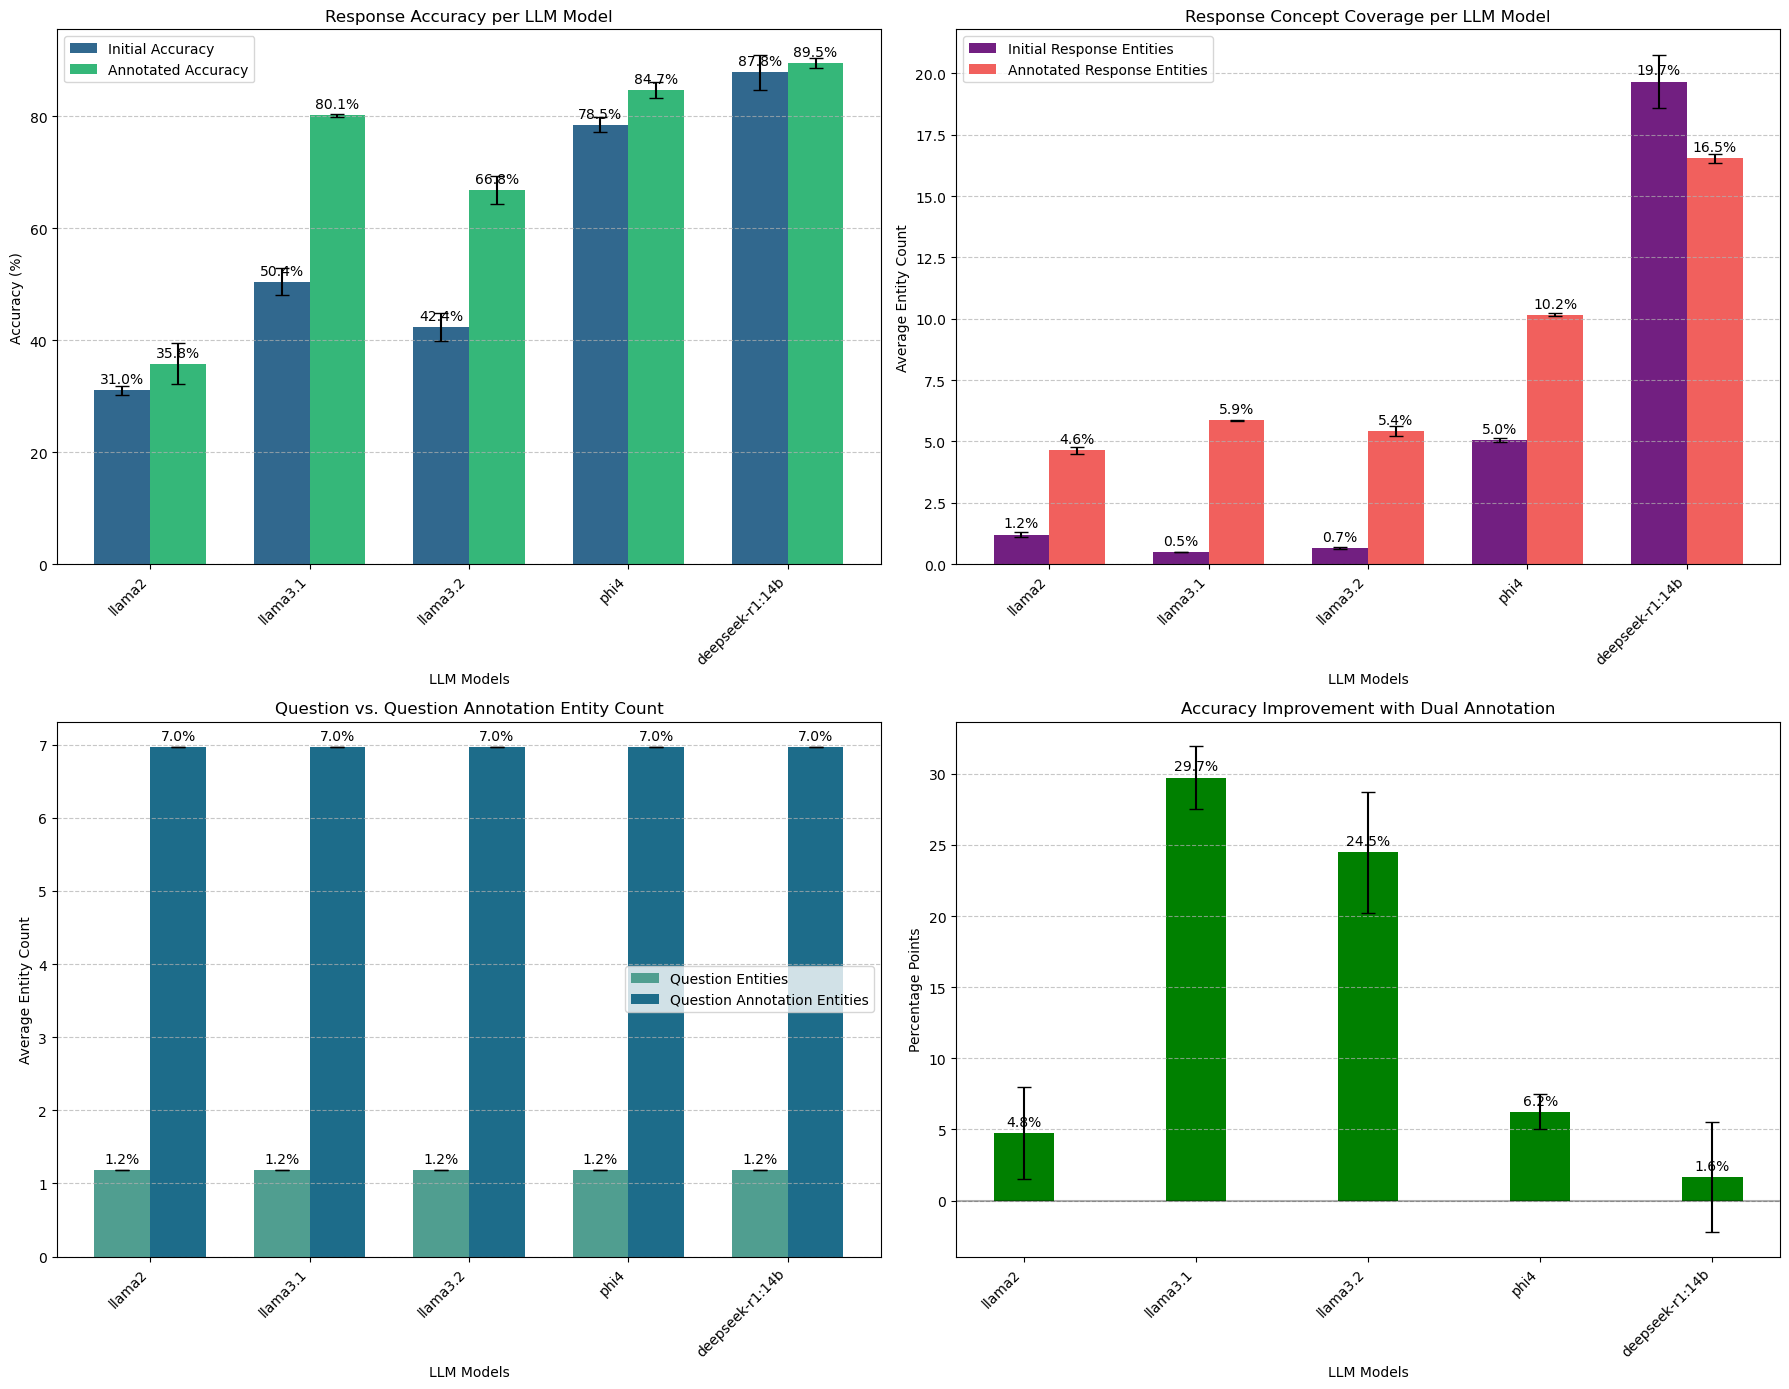


SUMMARY STATISTICS (MEANS ACROSS ALL FILES):
----------------------------------------------------------------------
Model      | Initial Acc      | Final Acc        | Improvement     
----------------------------------------------------------------------
llama2     | 31.0  % ±0.8   % | 35.8  % ±3.6   % | +4.8  % ±3.2   %
llama3.1   | 50.4  % ±2.4   % | 80.1  % ±0.2   % | +29.7 % ±2.2   %
llama3.2   | 42.4  % ±2.4   % | 66.8  % ±2.6   % | +24.5 % ±4.2   %
phi4       | 78.5  % ±1.3   % | 84.7  % ±1.5   % | +6.2  % ±1.2   %
deepseek-r1:14b | 87.8  % ±3.1   % | 89.5  % ±0.8   % | +1.6  % ±3.9   %


In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the saved metrics data
metrics_file = 'llm_metrics_data.json'

try:
    with open(metrics_file, 'r') as f:
        metrics_data = json.load(f)
    
    print(f"Successfully loaded metrics data from {metrics_file}")
except Exception as e:
    print(f"Error loading metrics data: {e}")
    exit(1)

# Extract data from the loaded file
llm_names = metrics_data["llm_names"]
mean_metrics = metrics_data["mean_metrics"]
std_metrics = metrics_data["std_metrics"]

# Prepare data for plotting
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_from_saved_data.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        model_name = key.split("_")[0]  # Extract LLM identifier
        
        # Skip if not in our target list
        if not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:    
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available
            question_annotation = item.get("question_annotation", "")
            if not question_annotation and "OntologyInfo" in item:
                question_annotation = item.get("OntologyInfo", "")
            
            # Check correctness
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# Check if pre-computed metrics exist
import os

metrics_cache_file = 'llm_metrics_data.json'
if os.path.exists(metrics_cache_file):
    print(f"Loading pre-computed metrics from {metrics_cache_file}")
    try:
        with open(metrics_cache_file, 'r') as f:
            cached_data = json.load(f)
        
        llm_names = cached_data["llm_names"]
        mean_metrics = cached_data["mean_metrics"]
        std_metrics = cached_data["std_metrics"]
        
        # Skip the computation steps
        compute_metrics = False
    except Exception as e:
        print(f"Error loading cached metrics: {e}")
        compute_metrics = True
else:
    compute_metrics = True

if compute_metrics:
    # File paths
    file_paths = [
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation.json",
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json",
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation2.json"
    ]

    # Filter for specific models only
    target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

    # Process all files
    all_files_metrics = []
    for file_path in file_paths:
        file_metrics = process_file(file_path, target_models)
        if file_metrics:
            aggregated_metrics = calculate_metrics_from_file(file_metrics)
            all_files_metrics.append(aggregated_metrics)
        else:
            print(f"Skipping file {file_path} due to errors")

# Get all unique models while preserving order of appearance
all_models = []
for metrics in all_files_metrics:
    for model in metrics.keys():
        if model not in all_models:
            all_models.append(model)

# Calculate means and standard deviations across files (only if not using cached data)
if compute_metrics:
    mean_metrics = {}
    std_metrics = {}

    for model in all_models:
        # Initialize containers for values across files
        initial_accuracies = []
        final_accuracies = []
        initial_coverages = []
        final_coverages = []
        question_entities = []
        question_anno_entities = []
        accuracy_improvements = []
        
        # Collect values from each file
        for file_metrics in all_files_metrics:
            if model in file_metrics:
                initial_accuracies.append(file_metrics[model]["initial_accuracy"])
                final_accuracies.append(file_metrics[model]["final_accuracy"])
                initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
                final_coverages.append(file_metrics[model]["final_concept_coverage"])
                question_entities.append(file_metrics[model]["question_entities"])
                question_anno_entities.append(file_metrics[model]["question_anno_entities"])
                accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
        
        # Calculate means and standard deviations
        # Only calculate if we have data from at least one file
        if initial_accuracies:
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "initial_concept_coverage": np.mean(initial_coverages),
                "final_concept_coverage": np.mean(final_coverages),
                "question_entities": np.mean(question_entities),
                "question_anno_entities": np.mean(question_anno_entities),
                "accuracy_improvement": np.mean(accuracy_improvements)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
                "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
                "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
                "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
                "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
            }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Save calculated data to avoid recomputation
metrics_data = {
    "llm_names": llm_names,
    "mean_metrics": mean_metrics,
    "std_metrics": std_metrics
}

# Save to file
with open('llm_metrics_data_Answer_annotation.json', 'w') as f:
    # Convert numpy values to regular floats for JSON serialization
    serializable_data = {
        "llm_names": llm_names,
        "mean_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                        for llm, metrics in mean_metrics.items()},
        "std_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                       for llm, metrics in std_metrics.items()}
    }
    json.dump(serializable_data, f, indent=4)

print("Metrics data saved to llm_metrics_data.json")

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('Answer_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

Loading pre-computed metrics from llm_metrics_data.json


NameError: name 'all_files_metrics' is not defined

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models=None):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        # Extract LLM identifier
        model_name = key.split("_")[0]
        
        # Skip if we have target models and this isn't one of them
        if target_models and not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:
            # Get the correct answer
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            # Get responses
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available from ResponseAnnotationInfo
            question_annotation = ""
            if "ResponseAnnotationInfo" in item:
                question_annotation = item["ResponseAnnotationInfo"].get("annotated_text", "")
            
            # Check correctness 
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# Check if pre-computed metrics exist
import os

metrics_cache_file = 'llm_metrics_data.json'
if os.path.exists(metrics_cache_file):
    print(f"Loading pre-computed metrics from {metrics_cache_file}")
    try:
        with open(metrics_cache_file, 'r') as f:
            cached_data = json.load(f)
        
        llm_names = cached_data["llm_names"]
        mean_metrics = cached_data["mean_metrics"]
        std_metrics = cached_data["std_metrics"]
        
        # Skip the computation steps
        compute_metrics = False
    except Exception as e:
        print(f"Error loading cached metrics: {e}")
        compute_metrics = True
else:
    compute_metrics = True

if compute_metrics:
    # File paths - update this to your file path
    file_paths = ["ResponseAnnotation.json"]

    # Filter for specific models only (or None to process all models)
    # Update this as needed based on your models
    target_models = None  # This will process all models

    # Process all files
    all_files_metrics = []
    for file_path in file_paths:
        file_metrics = process_file(file_path, target_models)
        if file_metrics:
            aggregated_metrics = calculate_metrics_from_file(file_metrics)
            all_files_metrics.append(aggregated_metrics)
        else:
            print(f"Skipping file {file_path} due to errors")

    # Get all unique models while preserving order of appearance
    all_models = []
    for metrics in all_files_metrics:
        for model in metrics.keys():
            if model not in all_models:
                all_models.append(model)

    # Calculate means and standard deviations across files
    mean_metrics = {}
    std_metrics = {}

    for model in all_models:
        # Initialize containers for values across files
        initial_accuracies = []
        final_accuracies = []
        initial_coverages = []
        final_coverages = []
        question_entities = []
        question_anno_entities = []
        accuracy_improvements = []
        
        # Collect values from each file
        for file_metrics in all_files_metrics:
            if model in file_metrics:
                initial_accuracies.append(file_metrics[model]["initial_accuracy"])
                final_accuracies.append(file_metrics[model]["final_accuracy"])
                initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
                final_coverages.append(file_metrics[model]["final_concept_coverage"])
                question_entities.append(file_metrics[model]["question_entities"])
                question_anno_entities.append(file_metrics[model]["question_anno_entities"])
                accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
        
        # Calculate means and standard deviations
        # Only calculate if we have data from at least one file
        if initial_accuracies:
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "initial_concept_coverage": np.mean(initial_coverages),
                "final_concept_coverage": np.mean(final_coverages),
                "question_entities": np.mean(question_entities),
                "question_anno_entities": np.mean(question_anno_entities),
                "accuracy_improvement": np.mean(accuracy_improvements)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
                "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
                "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
                "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
                "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
            }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Save calculated data to avoid recomputation
metrics_data = {
    "llm_names": llm_names,
    "mean_metrics": mean_metrics,
    "std_metrics": std_metrics
}

# Save to file
with open('llm_metrics_data.json', 'w') as f:
    # Convert numpy values to regular floats for JSON serialization
    serializable_data = {
        "llm_names": llm_names,
        "mean_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                        for llm, metrics in mean_metrics.items()},
        "std_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                       for llm, metrics in std_metrics.items()}
    }
    json.dump(serializable_data, f, indent=4)

print("Metrics data saved to llm_metrics_data.json")

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")


LLM METRICS SUMMARY (MEAN ACROSS FILES):


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

Error loading ResponseAnnotation.json: [Errno 2] No such file or directory: 'ResponseAnnotation.json'
Skipping file ResponseAnnotation.json due to errors
Metrics data saved to llm_metrics_data.json


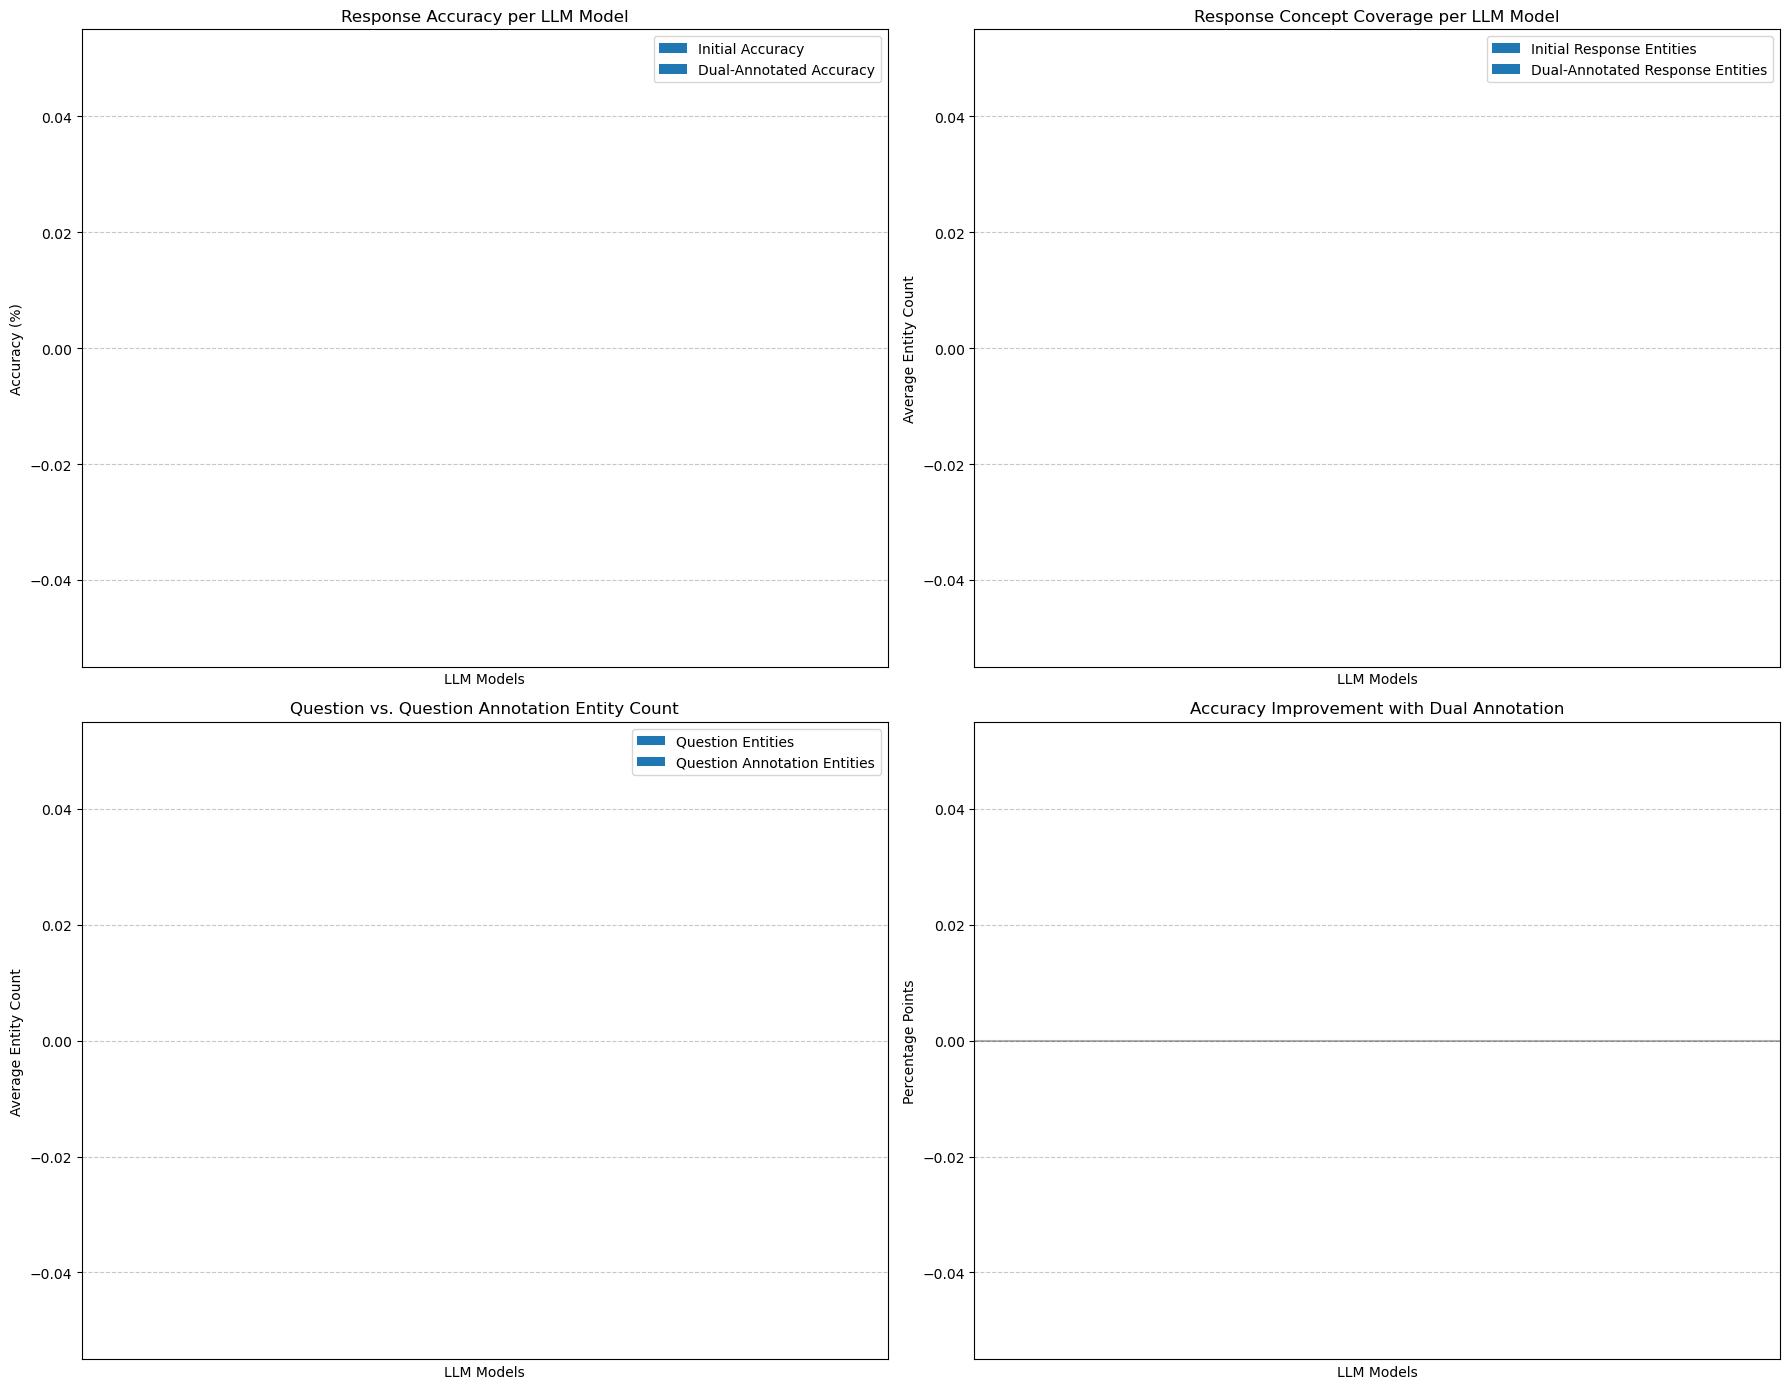


SUMMARY STATISTICS (MEANS ACROSS ALL FILES):
----------------------------------------------------------------------
Model      | Initial Acc      | Final Acc        | Improvement     
----------------------------------------------------------------------


In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models=None):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        # Extract LLM identifier
        model_name = key.split("_")[0]
        
        # Skip if we have target models and this isn't one of them
        if target_models and not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:
            # Get the correct answer
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            # Get responses
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available from ResponseAnnotationInfo
            question_annotation = ""
            if "ResponseAnnotationInfo" in item:
                question_annotation = item["ResponseAnnotationInfo"].get("annotated_text", "")
            
            # Check correctness 
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# File paths - UPDATED WITH YOUR NEW FILE PATH
file_paths = ["ResponseAnnotation.json"]

# Filter for specific models only (or None to process all models)
target_models = None  # This will process all models

# Process all files
all_files_metrics = []
for file_path in file_paths:
    file_metrics = process_file(file_path, target_models)
    if file_metrics:
        aggregated_metrics = calculate_metrics_from_file(file_metrics)
        all_files_metrics.append(aggregated_metrics)
    else:
        print(f"Skipping file {file_path} due to errors")

# Get all unique models while preserving order of appearance
all_models = []
for metrics in all_files_metrics:
    for model in metrics.keys():
        if model not in all_models:
            all_models.append(model)

# Calculate means and standard deviations across files
mean_metrics = {}
std_metrics = {}

for model in all_models:
    # Initialize containers for values across files
    initial_accuracies = []
    final_accuracies = []
    initial_coverages = []
    final_coverages = []
    question_entities = []
    question_anno_entities = []
    accuracy_improvements = []
    
    # Collect values from each file
    for file_metrics in all_files_metrics:
        if model in file_metrics:
            initial_accuracies.append(file_metrics[model]["initial_accuracy"])
            final_accuracies.append(file_metrics[model]["final_accuracy"])
            initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
            final_coverages.append(file_metrics[model]["final_concept_coverage"])
            question_entities.append(file_metrics[model]["question_entities"])
            question_anno_entities.append(file_metrics[model]["question_anno_entities"])
            accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
    
    # Calculate means and standard deviations
    # Only calculate if we have data from at least one file
    if initial_accuracies:
        mean_metrics[model] = {
            "initial_accuracy": np.mean(initial_accuracies),
            "final_accuracy": np.mean(final_accuracies),
            "initial_concept_coverage": np.mean(initial_coverages),
            "final_concept_coverage": np.mean(final_coverages),
            "question_entities": np.mean(question_entities),
            "question_anno_entities": np.mean(question_anno_entities),
            "accuracy_improvement": np.mean(accuracy_improvements)
        }
        
        std_metrics[model] = {
            "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
            "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
            "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
            "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
            "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
            "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
            "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
        }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Save calculated data
metrics_data = {
    "llm_names": llm_names,
    "mean_metrics": mean_metrics,
    "std_metrics": std_metrics
}

# Save to file
with open('llm_metrics_data.json', 'w') as f:
    # Convert numpy values to regular floats for JSON serialization
    serializable_data = {
        "llm_names": llm_names,
        "mean_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                        for llm, metrics in mean_metrics.items()},
        "std_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                       for llm, metrics in std_metrics.items()}
    }
    json.dump(serializable_data, f, indent=4)

print("Metrics data saved to llm_metrics_data.json")

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

Metrics data saved to llm_metrics_data.json


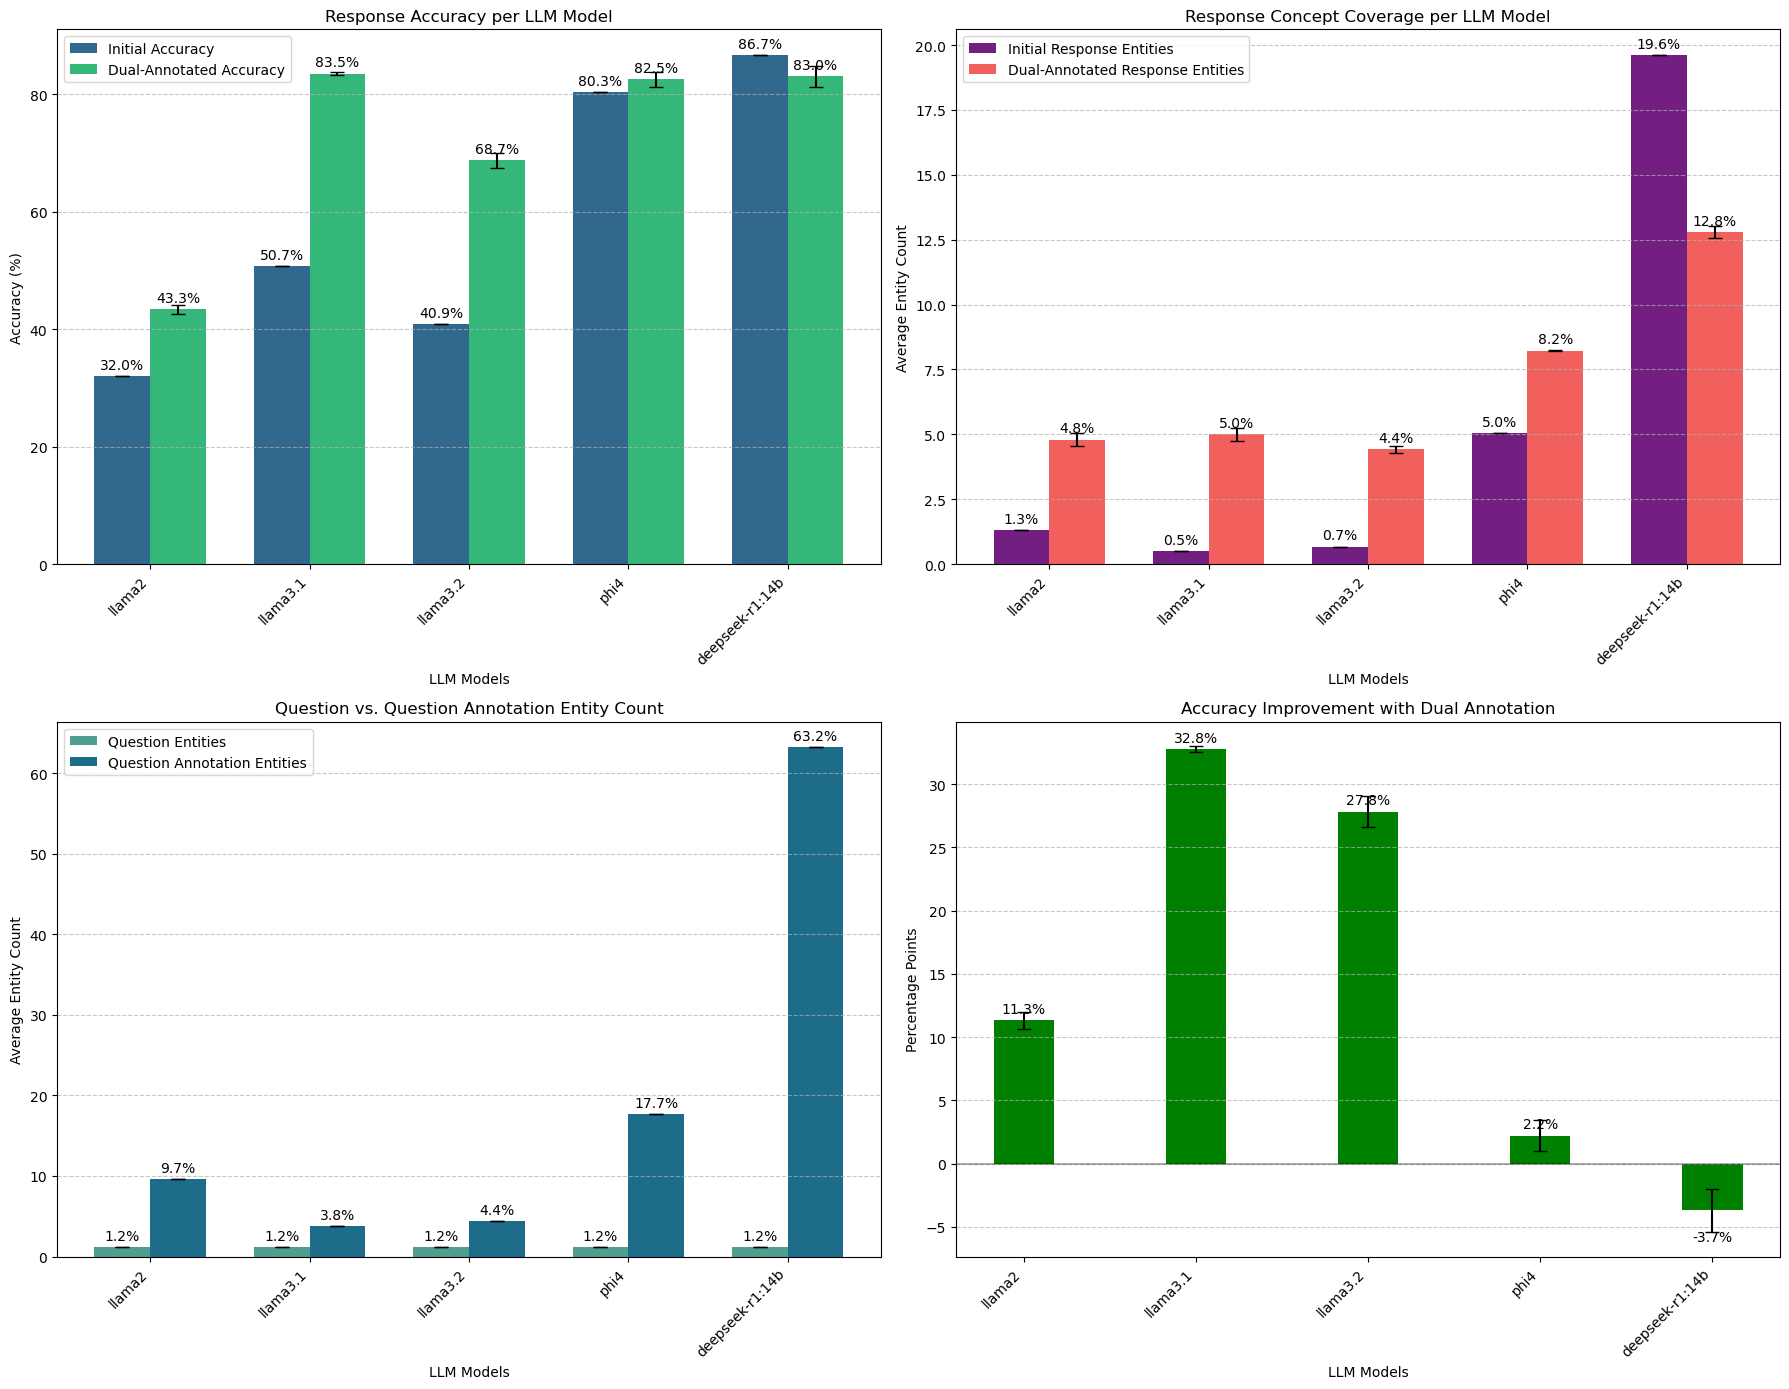


SUMMARY STATISTICS (MEANS ACROSS ALL FILES):
----------------------------------------------------------------------
Model      | Initial Acc      | Final Acc        | Improvement     
----------------------------------------------------------------------
llama2     | 32.0  % ±0.0   % | 43.3  % ±0.7   % | +11.3 % ±0.7   %
llama3.1   | 50.7  % ±0.0   % | 83.5  % ±0.2   % | +32.8 % ±0.2   %
llama3.2   | 40.9  % ±0.0   % | 68.7  % ±1.2   % | +27.8 % ±1.2   %
phi4       | 80.3  % ±0.0   % | 82.5  % ±1.2   % | +2.2  % ±1.2   %
deepseek-r1:14b | 86.7  % ±0.0   % | 83.0  % ±1.7   % | -3.7  % ±1.7   %


In [9]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        model_name = key.split("_")[0]  # Extract LLM identifier
        
        # Skip if not in our target list
        if not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:    
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available - MODIFIED FOR NEW FORMAT
            question_annotation = ""
            if "ResponseAnnotationInfo" in item:
                question_annotation = item["ResponseAnnotationInfo"].get("annotated_text", "")
            # Fallback to the original format as well
            if not question_annotation and "OntologyInfo" in item:
                question_annotation = item.get("OntologyInfo", "")
            
            # Check correctness
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# File paths - MODIFIED TO USE YOUR NEW FILES
file_paths = [
    "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation.json",
    "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json",
    "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation2.json"
]

# Filter for specific models only - USING THE SAME TARGETS
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

# Process all files
all_files_metrics = []
for file_path in file_paths:
    file_metrics = process_file(file_path, target_models)
    if file_metrics:
        aggregated_metrics = calculate_metrics_from_file(file_metrics)
        all_files_metrics.append(aggregated_metrics)
    else:
        print(f"Skipping file {file_path} due to errors")

# Get all unique models while preserving order of appearance
all_models = []
for metrics in all_files_metrics:
    for model in metrics.keys():
        if model not in all_models:
            all_models.append(model)

# Calculate means and standard deviations across files
mean_metrics = {}
std_metrics = {}

for model in all_models:
    # Initialize containers for values across files
    initial_accuracies = []
    final_accuracies = []
    initial_coverages = []
    final_coverages = []
    question_entities = []
    question_anno_entities = []
    accuracy_improvements = []
    
    # Collect values from each file
    for file_metrics in all_files_metrics:
        if model in file_metrics:
            initial_accuracies.append(file_metrics[model]["initial_accuracy"])
            final_accuracies.append(file_metrics[model]["final_accuracy"])
            initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
            final_coverages.append(file_metrics[model]["final_concept_coverage"])
            question_entities.append(file_metrics[model]["question_entities"])
            question_anno_entities.append(file_metrics[model]["question_anno_entities"])
            accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
    
    # Calculate means and standard deviations
    # Only calculate if we have data from at least one file
    if initial_accuracies:
        mean_metrics[model] = {
            "initial_accuracy": np.mean(initial_accuracies),
            "final_accuracy": np.mean(final_accuracies),
            "initial_concept_coverage": np.mean(initial_coverages),
            "final_concept_coverage": np.mean(final_coverages),
            "question_entities": np.mean(question_entities),
            "question_anno_entities": np.mean(question_anno_entities),
            "accuracy_improvement": np.mean(accuracy_improvements)
        }
        
        std_metrics[model] = {
            "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
            "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
            "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
            "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
            "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
            "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
            "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
        }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Save calculated data to avoid recomputation
metrics_data = {
    "llm_names": llm_names,
    "mean_metrics": mean_metrics,
    "std_metrics": std_metrics
}

# Save to file
with open('llm_metrics_data_answer.json', 'w') as f:
    # Convert numpy values to regular floats for JSON serialization
    serializable_data = {
        "llm_names": llm_names,
        "mean_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                        for llm, metrics in mean_metrics.items()},
        "std_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                       for llm, metrics in std_metrics.items()}
    }
    json.dump(serializable_data, f, indent=4)

print("Metrics data saved to llm_metrics_data.json")

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

Metrics data saved to llm_metrics_data.json


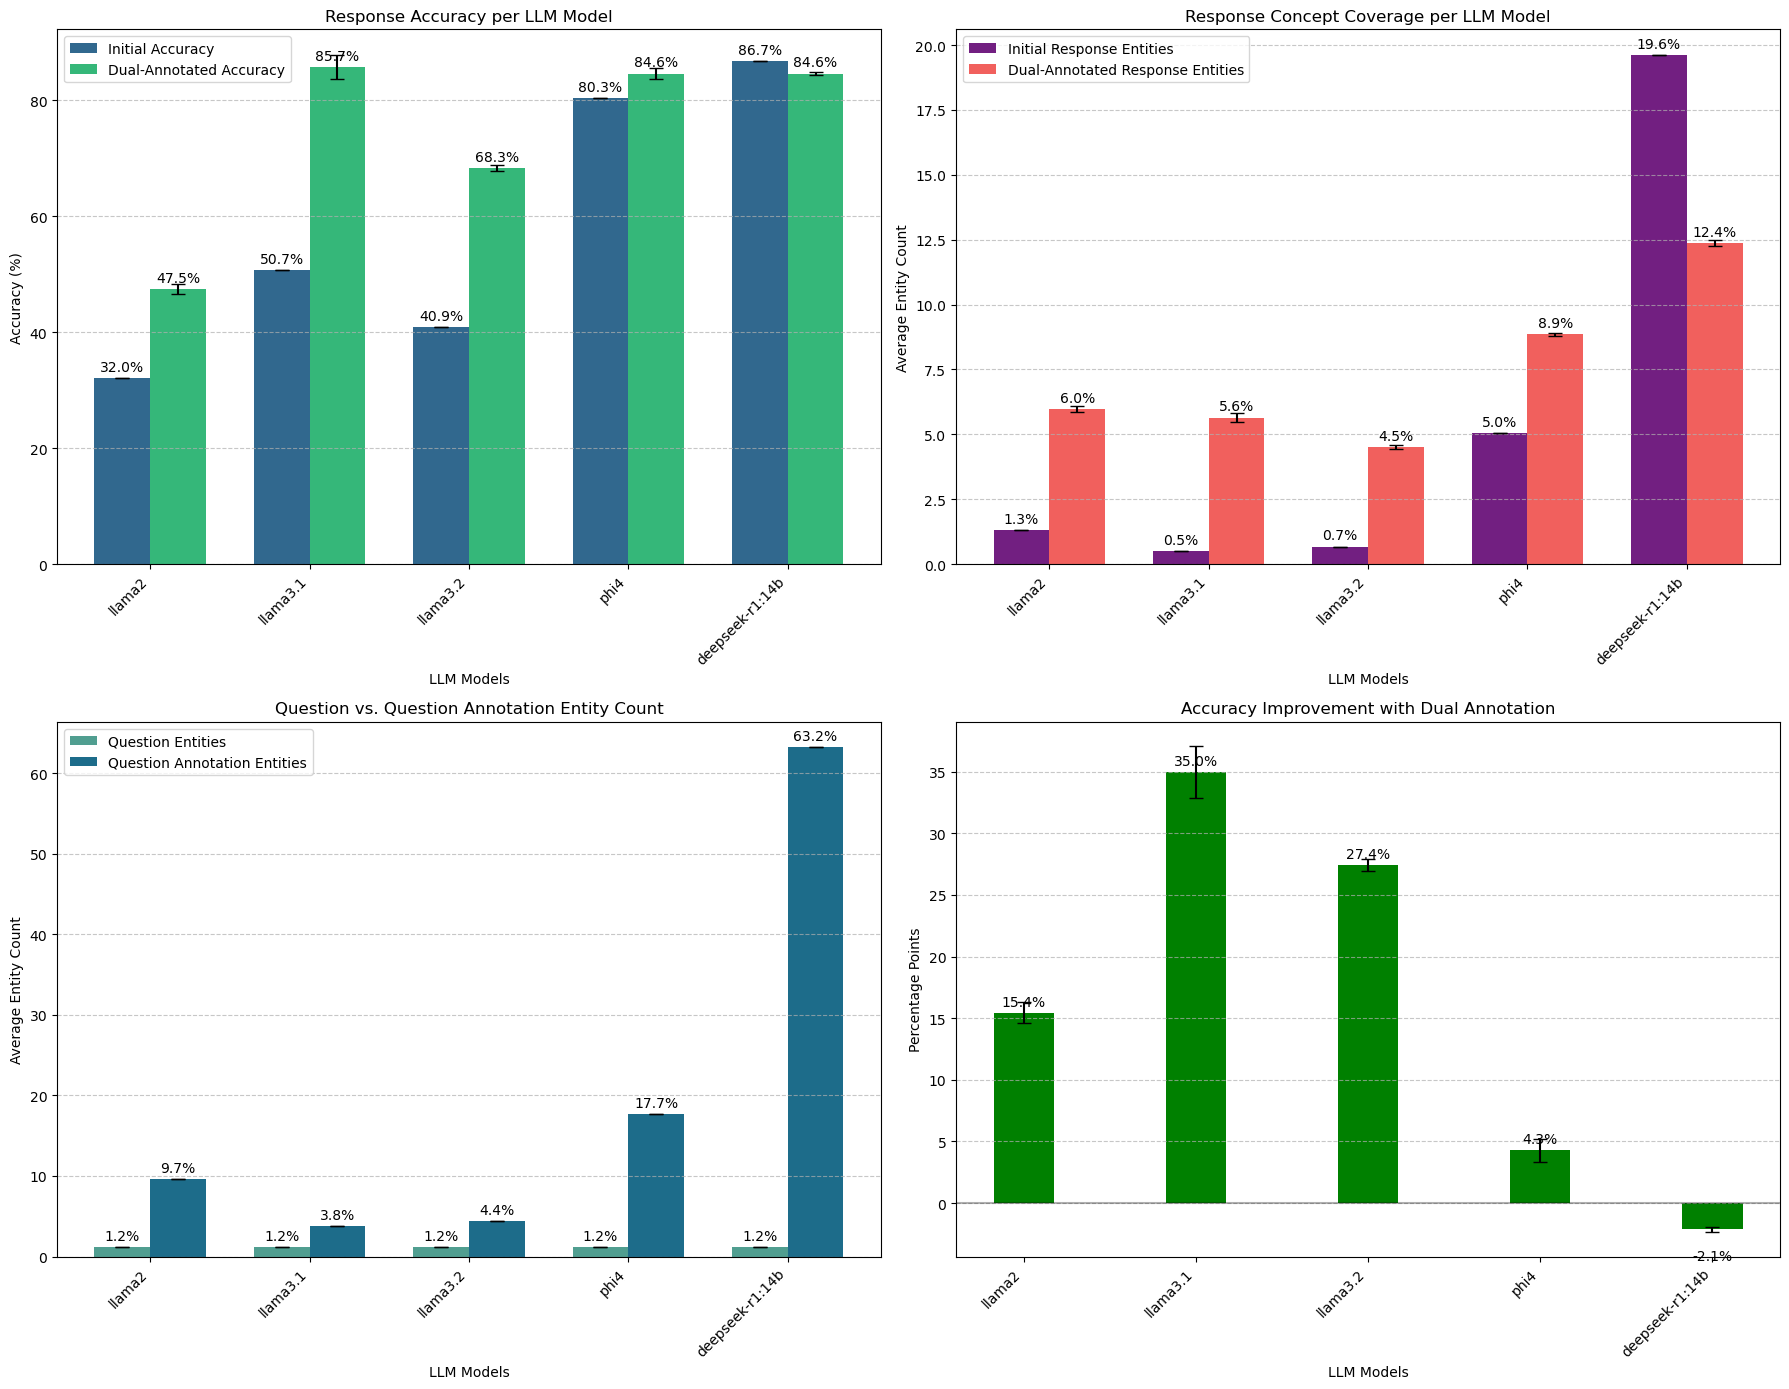


SUMMARY STATISTICS (MEANS ACROSS ALL FILES):
----------------------------------------------------------------------
Model      | Initial Acc      | Final Acc        | Improvement     
----------------------------------------------------------------------
llama2     | 32.0  % ±0.0   % | 47.5  % ±0.8   % | +15.4 % ±0.8   %
llama3.1   | 50.7  % ±0.0   % | 85.7  % ±2.1   % | +35.0 % ±2.1   %
llama3.2   | 40.9  % ±0.0   % | 68.3  % ±0.5   % | +27.4 % ±0.5   %
phi4       | 80.3  % ±0.0   % | 84.6  % ±0.9   % | +4.3  % ±0.9   %
deepseek-r1:14b | 86.7  % ±0.0   % | 84.6  % ±0.2   % | -2.1  % ±0.2   %


In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
import spacy
import seaborn as sns
from collections import defaultdict

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    return set([ent.text.lower() for ent in doc.ents])

def process_file(file_path, target_models):
    """Process a single JSON file and return metrics."""
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Initialize LLM-based metrics
    llm_metrics = defaultdict(lambda: {
        "initial_correct": 0,         # Initial response correctness
        "final_correct": 0,           # Final response with dual annotation
        "total": 0,                   # Total questions
        "concept_coverage_initial": [],  # Entity counts in initial response
        "concept_coverage_final": [],    # Entity counts in final response
        "question_entities": [],      # Entity counts in questions
        "question_annotation_entities": []  # Entity counts in question annotations
    })
    
    for key, item in data.items():
        model_name = key.split("_")[0]  # Extract LLM identifier
        
        # Skip if not in our target list
        if not any(model_name.startswith(target) for target in target_models):
            continue
        
        try:    
            correct_answer_index = int(item["question"]["answer"])
            options = item['question']['choices']
            correct_answer = options[correct_answer_index]
            
            initial_response = item["raw_model_response"].lower()
            final_response = item["onto_model_response"].lower()
            question_text = item["question"]["text"].lower()
            
            # Get question annotation if available - MODIFIED FOR NEW FORMAT
            question_annotation = ""
            if "ResponseAnnotationInfo" in item:
                question_annotation = item["ResponseAnnotationInfo"].get("annotated_text", "")
            # Fallback to the original format as well
            if not question_annotation and "OntologyInfo" in item:
                question_annotation = item.get("OntologyInfo", "")
            
            # Check correctness
            if correct_answer.lower() in initial_response:
                llm_metrics[model_name]["initial_correct"] += 1
            
            if correct_answer.lower() in final_response:
                llm_metrics[model_name]["final_correct"] += 1
            
            llm_metrics[model_name]["total"] += 1
            
            # Extract entities for concept coverage
            initial_entities = extract_entities(initial_response)
            final_entities = extract_entities(final_response)
            question_entities = extract_entities(question_text)
            question_anno_entities = extract_entities(str(question_annotation))
            
            llm_metrics[model_name]["concept_coverage_initial"].append(len(initial_entities))
            llm_metrics[model_name]["concept_coverage_final"].append(len(final_entities))
            llm_metrics[model_name]["question_entities"].append(len(question_entities))
            llm_metrics[model_name]["question_annotation_entities"].append(len(question_anno_entities))
        
        except (KeyError, IndexError, ValueError) as e:
            print(f"Error processing {key} in {file_path}: {e}")
            continue
    
    return llm_metrics

def calculate_metrics_from_file(llm_metrics):
    """Calculate aggregated metrics from file data."""
    llm_data = {}
    
    for llm, metrics in llm_metrics.items():
        total_questions = metrics["total"]
        if total_questions == 0:
            print(f"Skipping {llm} - no valid data")
            continue
            
        initial_accuracy = metrics["initial_correct"] / total_questions * 100
        final_accuracy = metrics["final_correct"] / total_questions * 100
        avg_concept_initial = np.mean(metrics["concept_coverage_initial"])
        avg_concept_final = np.mean(metrics["concept_coverage_final"])
        avg_question_entities = np.mean(metrics["question_entities"])
        avg_question_anno_entities = np.mean(metrics["question_annotation_entities"])
        
        llm_data[llm] = {
            "initial_accuracy": initial_accuracy,
            "final_accuracy": final_accuracy,
            "initial_concept_coverage": avg_concept_initial,
            "final_concept_coverage": avg_concept_final,
            "question_entities": avg_question_entities,
            "question_anno_entities": avg_question_anno_entities,
            "accuracy_improvement": final_accuracy - initial_accuracy
        }
    
    return llm_data

# File paths - MODIFIED TO USE YOUR NEW FILES
file_paths = [
    "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json",
    "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation1.json",
    "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation2.json"
]

# Filter for specific models only - USING THE SAME TARGETS
target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]

# Process all files
all_files_metrics = []
for file_path in file_paths:
    file_metrics = process_file(file_path, target_models)
    if file_metrics:
        aggregated_metrics = calculate_metrics_from_file(file_metrics)
        all_files_metrics.append(aggregated_metrics)
    else:
        print(f"Skipping file {file_path} due to errors")

# Get all unique models while preserving order of appearance
all_models = []
for metrics in all_files_metrics:
    for model in metrics.keys():
        if model not in all_models:
            all_models.append(model)

# Calculate means and standard deviations across files
mean_metrics = {}
std_metrics = {}

for model in all_models:
    # Initialize containers for values across files
    initial_accuracies = []
    final_accuracies = []
    initial_coverages = []
    final_coverages = []
    question_entities = []
    question_anno_entities = []
    accuracy_improvements = []
    
    # Collect values from each file
    for file_metrics in all_files_metrics:
        if model in file_metrics:
            initial_accuracies.append(file_metrics[model]["initial_accuracy"])
            final_accuracies.append(file_metrics[model]["final_accuracy"])
            initial_coverages.append(file_metrics[model]["initial_concept_coverage"])
            final_coverages.append(file_metrics[model]["final_concept_coverage"])
            question_entities.append(file_metrics[model]["question_entities"])
            question_anno_entities.append(file_metrics[model]["question_anno_entities"])
            accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
    
    # Calculate means and standard deviations
    # Only calculate if we have data from at least one file
    if initial_accuracies:
        mean_metrics[model] = {
            "initial_accuracy": np.mean(initial_accuracies),
            "final_accuracy": np.mean(final_accuracies),
            "initial_concept_coverage": np.mean(initial_coverages),
            "final_concept_coverage": np.mean(final_coverages),
            "question_entities": np.mean(question_entities),
            "question_anno_entities": np.mean(question_anno_entities),
            "accuracy_improvement": np.mean(accuracy_improvements)
        }
        
        std_metrics[model] = {
            "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
            "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
            "initial_concept_coverage": np.std(initial_coverages) if len(initial_coverages) > 1 else 0,
            "final_concept_coverage": np.std(final_coverages) if len(final_coverages) > 1 else 0,
            "question_entities": np.std(question_entities) if len(question_entities) > 1 else 0,
            "question_anno_entities": np.std(question_anno_entities) if len(question_anno_entities) > 1 else 0,
            "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0
        }

# Prepare data for plotting
llm_names = list(mean_metrics.keys())
initial_accuracies = [mean_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracies = [mean_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_concept_coverages = [mean_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_concept_coverages = [mean_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_counts = [mean_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_counts = [mean_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvements = [mean_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Prepare error bars
initial_accuracy_errors = [std_metrics[llm]["initial_accuracy"] for llm in llm_names]
final_accuracy_errors = [std_metrics[llm]["final_accuracy"] for llm in llm_names]
initial_coverage_errors = [std_metrics[llm]["initial_concept_coverage"] for llm in llm_names]
final_coverage_errors = [std_metrics[llm]["final_concept_coverage"] for llm in llm_names]
question_entity_errors = [std_metrics[llm]["question_entities"] for llm in llm_names]
question_anno_entity_errors = [std_metrics[llm]["question_anno_entities"] for llm in llm_names]
accuracy_improvement_errors = [std_metrics[llm]["accuracy_improvement"] for llm in llm_names]

# Save calculated data to avoid recomputation
metrics_data = {
    "llm_names": llm_names,
    "mean_metrics": mean_metrics,
    "std_metrics": std_metrics
}

# Save to file
with open('llm_metrics_data_dual.json', 'w') as f:
    # Convert numpy values to regular floats for JSON serialization
    serializable_data = {
        "llm_names": llm_names,
        "mean_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                        for llm, metrics in mean_metrics.items()},
        "std_metrics": {llm: {k: float(v) for k, v in metrics.items()} 
                       for llm, metrics in std_metrics.items()}
    }
    json.dump(serializable_data, f, indent=4)

print("Metrics data saved to llm_metrics_data.json")

# Create a figure with multiple subplots (2x2 grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Set custom colors
accuracy_colors = sns.color_palette("viridis", 2)
concept_colors = sns.color_palette("magma", 2)
question_colors = sns.color_palette("crest", 2)

# Plot 1: Accuracy
x = np.arange(len(llm_names))
width = 0.35

accuracy_bars1 = ax1.bar(x - width/2, initial_accuracies, width, label="Initial Accuracy", 
                         color=accuracy_colors[0], yerr=initial_accuracy_errors, capsize=5)
accuracy_bars2 = ax1.bar(x + width/2, final_accuracies, width, label="Dual-Annotated Accuracy", 
                         color=accuracy_colors[1], yerr=final_accuracy_errors, capsize=5)

ax1.set_xlabel('LLM Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Response Accuracy per LLM Model')
ax1.set_xticks(x)
ax1.set_xticklabels(llm_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(ax1, accuracy_bars1)
add_labels(ax1, accuracy_bars2)

# Plot 2: Response Concept Coverage
concept_bars1 = ax2.bar(x - width/2, initial_concept_coverages, width, label="Initial Response Entities", 
                        color=concept_colors[0], yerr=initial_coverage_errors, capsize=5)
concept_bars2 = ax2.bar(x + width/2, final_concept_coverages, width, label="Dual-Annotated Response Entities", 
                        color=concept_colors[1], yerr=final_coverage_errors, capsize=5)

ax2.set_xlabel('LLM Models')
ax2.set_ylabel('Average Entity Count')
ax2.set_title('Response Concept Coverage per LLM Model')
ax2.set_xticks(x)
ax2.set_xticklabels(llm_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax2, concept_bars1)
add_labels(ax2, concept_bars2)

# Plot 3: Question vs Question Annotation Entity Count
question_bars1 = ax3.bar(x - width/2, question_entity_counts, width, label="Question Entities", 
                         color=question_colors[0], yerr=question_entity_errors, capsize=5)
question_bars2 = ax3.bar(x + width/2, question_anno_entity_counts, width, label="Question Annotation Entities", 
                         color=question_colors[1], yerr=question_anno_entity_errors, capsize=5)

ax3.set_xlabel('LLM Models')
ax3.set_ylabel('Average Entity Count')
ax3.set_title('Question vs. Question Annotation Entity Count')
ax3.set_xticks(x)
ax3.set_xticklabels(llm_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

add_labels(ax3, question_bars1)
add_labels(ax3, question_bars2)

# Plot 4: Accuracy Improvement
improvement_bars = ax4.bar(x, accuracy_improvements, width, label="Accuracy Improvement", 
                           color='green', yerr=accuracy_improvement_errors, capsize=5)
ax4.set_xlabel('LLM Models')
ax4.set_ylabel('Percentage Points')
ax4.set_title('Accuracy Improvement with Dual Annotation')
ax4.set_xticks(x)
ax4.set_xticklabels(llm_names, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at y=0
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add values on top of bars
for bar in improvement_bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -14),  # adjust vertical position based on bar direction
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig('dual_annotation_performance_with_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSUMMARY STATISTICS (MEANS ACROSS ALL FILES):")
print("-" * 70)
print(f"{'Model':<10} | {'Initial Acc':<16} | {'Final Acc':<16} | {'Improvement':<16}")
print("-" * 70)
for i, model in enumerate(llm_names):
    print(f"{model:<10} | {initial_accuracies[i]:<6.1f}% ±{initial_accuracy_errors[i]:<6.1f}% | {final_accuracies[i]:<6.1f}% ±{final_accuracy_errors[i]:<6.1f}% | {accuracy_improvements[i]:<+6.1f}% ±{accuracy_improvement_errors[i]:<6.1f}%")

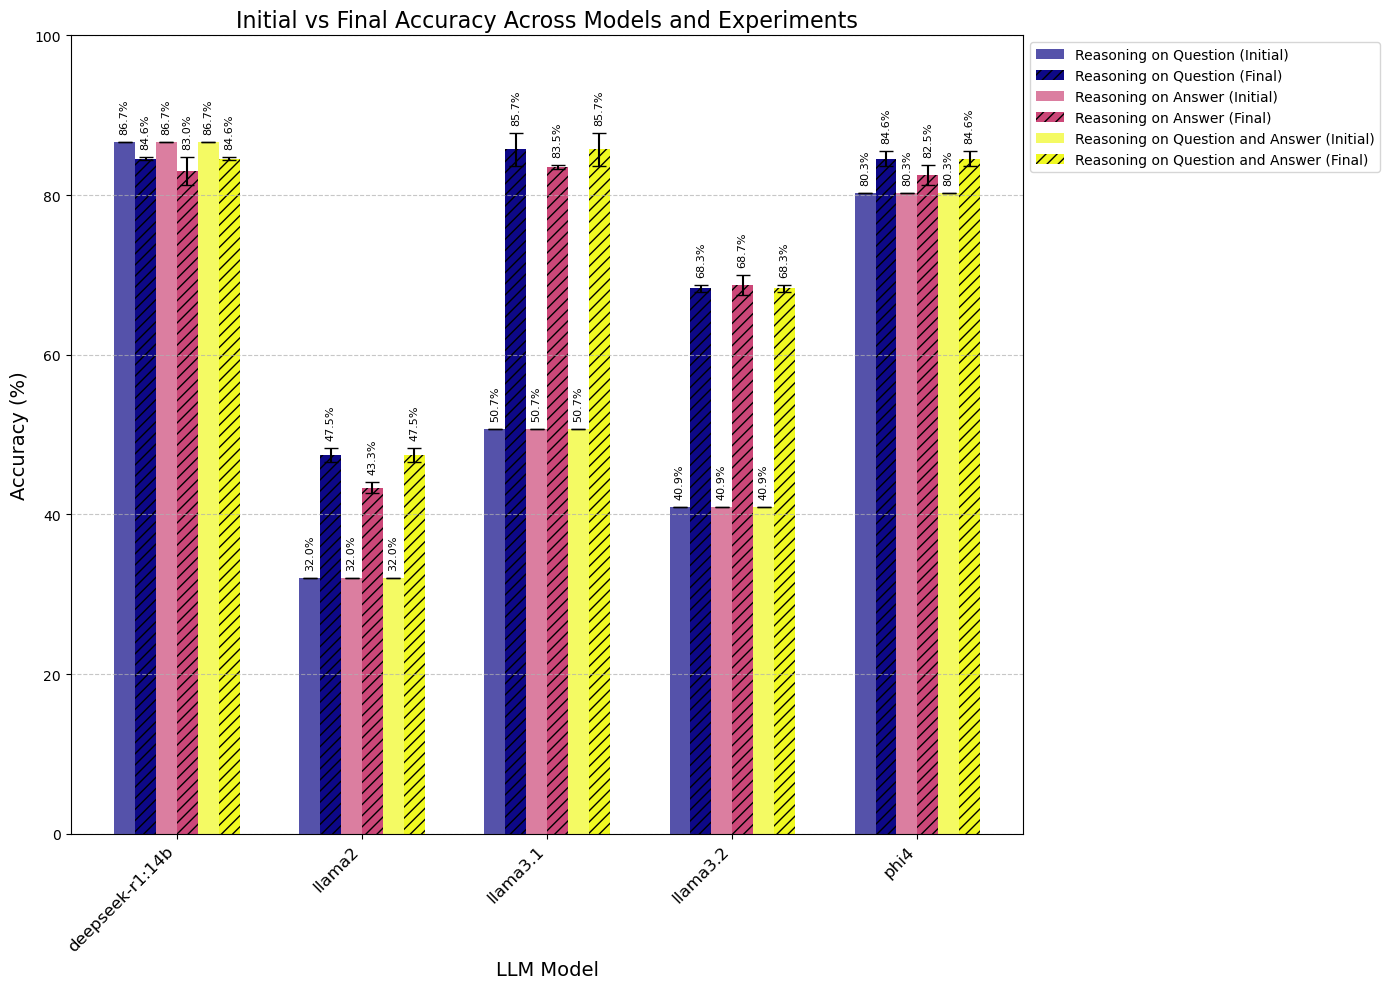

Visualization saved as 'llm_accuracy_comparison.png'


In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.colors as mcolors

def load_json_file(file_path):
    """Load a JSON file and return the data."""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Define the file paths
file_paths = [
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_answer.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_dual.json"
]

# Use descriptive names for each file/experiment
file_labels = [
    "Reasoning on Question",
    "Reasoning on Answer", 
    "Reasoning on Question and Answer"
]

# Load data from all three files
all_data = []
for file_path in file_paths:
    data = load_json_file(file_path)
    if data:
        all_data.append(data)
    else:
        print(f"Skipping {file_path} due to loading error")

# Check if we have any valid data
if not all_data:
    print("No valid data found. Exiting.")
    exit()

# Get all unique model names across the files
all_models = set()
for data in all_data:
    all_models.update(data["llm_names"])
all_models = sorted(list(all_models))

# Prepare data for plotting
file_count = len(all_data)
model_count = len(all_models)

# Initialize arrays for initial and final accuracies and their error bars
initial_accuracies = np.zeros((model_count, file_count))
final_accuracies = np.zeros((model_count, file_count))
initial_errors = np.zeros((model_count, file_count))
final_errors = np.zeros((model_count, file_count))

# Fill the arrays with data from each file
for file_idx, data in enumerate(all_data):
    for model_idx, model_name in enumerate(all_models):
        if model_name in data["mean_metrics"]:
            initial_accuracies[model_idx, file_idx] = data["mean_metrics"][model_name]["initial_accuracy"]
            final_accuracies[model_idx, file_idx] = data["mean_metrics"][model_name]["final_accuracy"]
            initial_errors[model_idx, file_idx] = data["std_metrics"][model_name]["initial_accuracy"]
            final_errors[model_idx, file_idx] = data["std_metrics"][model_name]["final_accuracy"]

# Create a figure
plt.figure(figsize=(14, 10))

# Set up the bar positions
bar_width = 0.35
group_width = bar_width * 2 * file_count  # Width of a model group (initial + final for each file)
group_positions = np.arange(model_count) * (group_width + 1)  # Position of each model group

# Create a plasma colormap for the bars
plasma_cmap = plt.cm.plasma
colors = [plasma_cmap(i) for i in np.linspace(0, 1, file_count)]

# Create the grouped bar chart
for file_idx in range(file_count):
    # Calculate positions for this file's bars
    initial_positions = group_positions + (file_idx * bar_width * 2)
    final_positions = initial_positions + bar_width
    
    # Plot initial accuracies
    plt.bar(
        initial_positions, 
        initial_accuracies[:, file_idx], 
        bar_width, 
        yerr=initial_errors[:, file_idx], 
        capsize=5, 
        color=colors[file_idx], 
        alpha=0.7,
        label=f"{file_labels[file_idx]} (Initial)"
    )
    
    # Plot final accuracies
    plt.bar(
        final_positions, 
        final_accuracies[:, file_idx], 
        bar_width, 
        yerr=final_errors[:, file_idx], 
        capsize=5, 
        color=colors[file_idx], 
        alpha=1.0,
        hatch='///',
        label=f"{file_labels[file_idx]} (Final)"
    )

# Add labels and title
plt.xlabel('LLM Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Initial vs Final Accuracy Across Models and Experiments', fontsize=16)

# Set x-ticks at the center of each group
plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), all_models, rotation=45, ha='right', fontsize=12)

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis range from 0 to 100 (for percentage)
plt.ylim(0, 100)

# Add value labels on top of bars
for file_idx in range(file_count):
    initial_positions = group_positions + (file_idx * bar_width * 2)
    final_positions = initial_positions + bar_width
    
    for i, model_idx in enumerate(range(model_count)):
        # Only add label if the value is not zero
        if initial_accuracies[model_idx, file_idx] > 0:
            plt.text(
                initial_positions[i],
                initial_accuracies[model_idx, file_idx] + initial_errors[model_idx, file_idx] + 1,
                f'{initial_accuracies[model_idx, file_idx]:.1f}%',
                ha='center', va='bottom', rotation=90, fontsize=8
            )
        
        if final_accuracies[model_idx, file_idx] > 0:
            plt.text(
                final_positions[i],
                final_accuracies[model_idx, file_idx] + final_errors[model_idx, file_idx] + 1,
                f'{final_accuracies[model_idx, file_idx]:.1f}%',
                ha='center', va='bottom', rotation=90, fontsize=8
            )

# Create a custom legend to make it more readable
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig('llm_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'llm_accuracy_comparison.png'")

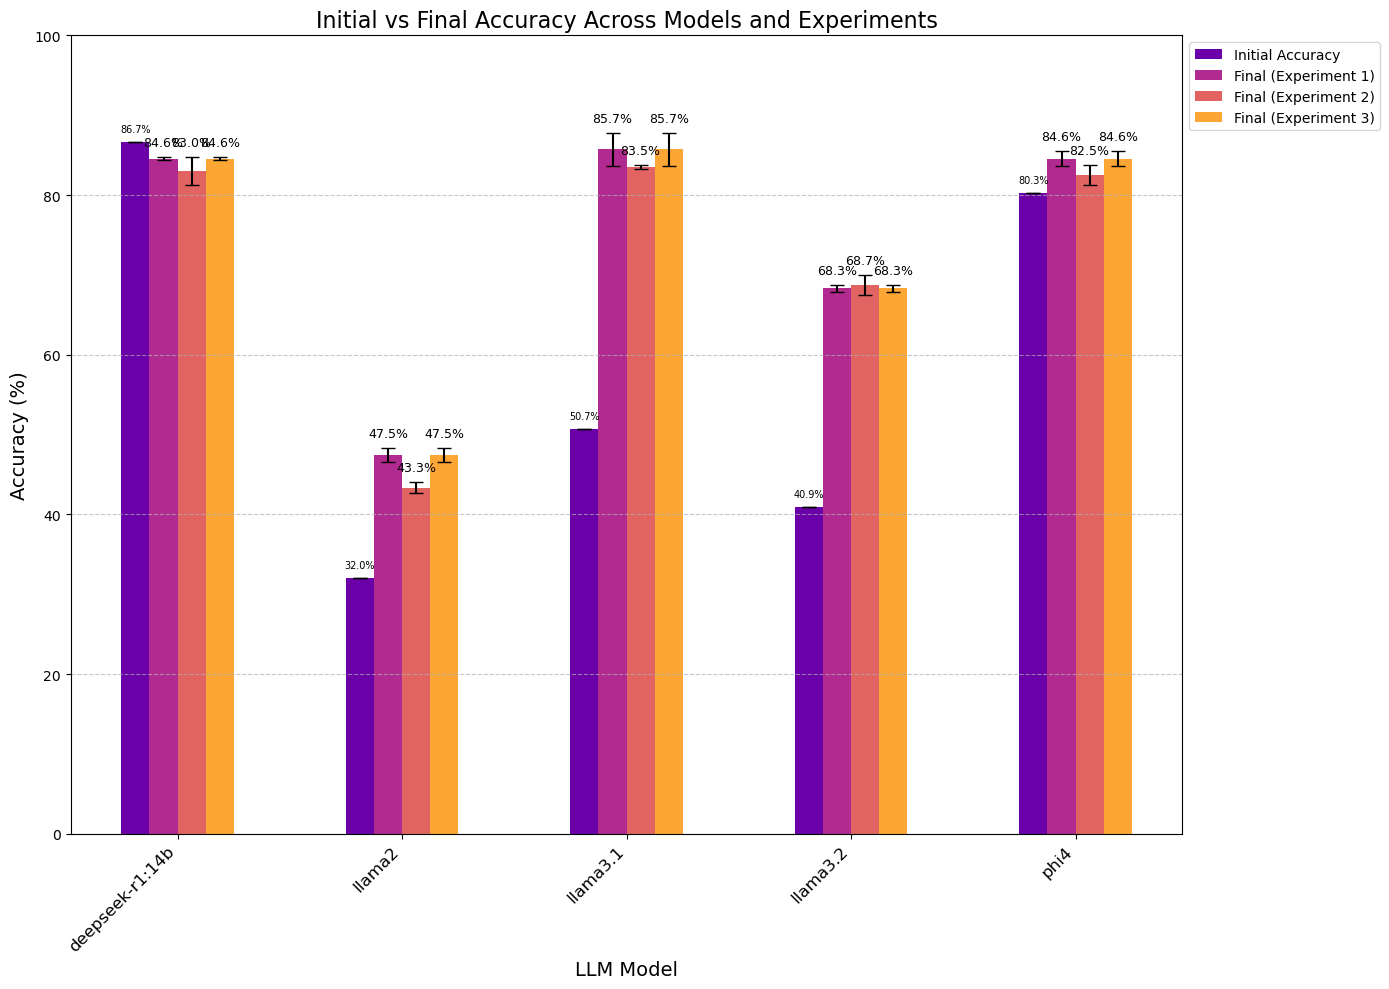

Visualization saved as 'llm_accuracy_comparison_plasma.png'


In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def load_json_file(file_path):
    """Load a JSON file and return the data."""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

file_paths = [
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_answer.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_dual.json"
]

# Use descriptive names for each file/experiment
file_labels = [
    "Experiment 1",
    "Experiment 2", 
    "Experiment 3"
]

# Load data from all three files
all_data = []
for file_path in file_paths:
    data = load_json_file(file_path)
    if data:
        all_data.append(data)
    else:
        print(f"Skipping {file_path} due to loading error")

# Check if we have any valid data
if not all_data:
    print("No valid data found. Exiting.")
    exit()

# Get all unique model names across the files
all_models = set()
for data in all_data:
    all_models.update(data["llm_names"])
all_models = sorted(list(all_models))

# Prepare data for plotting
file_count = len(all_data)
model_count = len(all_models)

# Initialize arrays for initial and final accuracies and their error bars
initial_accuracies = np.zeros(model_count)
initial_errors = np.zeros(model_count)
final_accuracies = np.zeros((model_count, file_count))
final_errors = np.zeros((model_count, file_count))

# Fill the arrays with data - using only first file for initial values
for model_idx, model_name in enumerate(all_models):
    if model_name in all_data[0]["mean_metrics"]:
        initial_accuracies[model_idx] = all_data[0]["mean_metrics"][model_name]["initial_accuracy"]
        initial_errors[model_idx] = all_data[0]["std_metrics"][model_name]["initial_accuracy"]

# Fill the final accuracy arrays with data from each file
for file_idx, data in enumerate(all_data):
    for model_idx, model_name in enumerate(all_models):
        if model_name in data["mean_metrics"]:
            final_accuracies[model_idx, file_idx] = data["mean_metrics"][model_name]["final_accuracy"]
            final_errors[model_idx, file_idx] = data["std_metrics"][model_name]["final_accuracy"]

# Create a figure
plt.figure(figsize=(14, 10))

# Set up the bar positions
bar_width = 0.2
group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
group_positions = np.arange(model_count) * (group_width + 0.8)  # Position of each model group

# Use seaborn's plasma palette
plasma_colors = sns.color_palette("plasma", file_count + 1)

# Plot initial accuracies first (only once per model)
initial_positions = group_positions
initial_bars = plt.bar(
    initial_positions, 
    initial_accuracies, 
    bar_width, 
    yerr=initial_errors, 
    capsize=5, 
    color=plasma_colors[0], 
    label="Initial Accuracy"
)

# Create the grouped bar chart for final accuracies
for file_idx in range(file_count):
    # Calculate positions for this file's bars - position after initial bar
    final_positions = group_positions + bar_width * (file_idx + 1)
    
    # Plot final accuracies
    plt.bar(
        final_positions, 
        final_accuracies[:, file_idx], 
        bar_width, 
        yerr=final_errors[:, file_idx], 
        capsize=5, 
        color=plasma_colors[file_idx + 1], 
        label=f"Final ({file_labels[file_idx]})"
    )

# Add labels and title
plt.xlabel('LLM Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Initial vs Final Accuracy Across Models and Experiments', fontsize=16)

# Set x-ticks at the center of each group
plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), all_models, rotation=45, ha='right', fontsize=12)

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis range from 0 to 100 (for percentage)
plt.ylim(0, 100)

# Add value labels on top of initial bars
for i, model_idx in enumerate(range(model_count)):
    if initial_accuracies[model_idx] > 0:
        plt.text(
            initial_positions[i],
            initial_accuracies[model_idx] + initial_errors[model_idx] + 1,
            f'{initial_accuracies[model_idx]:.1f}%',
            ha='center', va='bottom', fontsize=7
        )

# Add value labels on top of final bars
for file_idx in range(file_count):
    final_positions = group_positions + bar_width * (file_idx + 1)
    
    for i, model_idx in enumerate(range(model_count)):
        if final_accuracies[model_idx, file_idx] > 0:
            plt.text(
                final_positions[i],
                final_accuracies[model_idx, file_idx] + final_errors[model_idx, file_idx] + 1,
                f'{final_accuracies[model_idx, file_idx]:.1f}%',
                ha='center', va='bottom', fontsize=9
            )

# Add a legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig('llm_accuracy_comparison_plasma.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'llm_accuracy_comparison_plasma.png'")

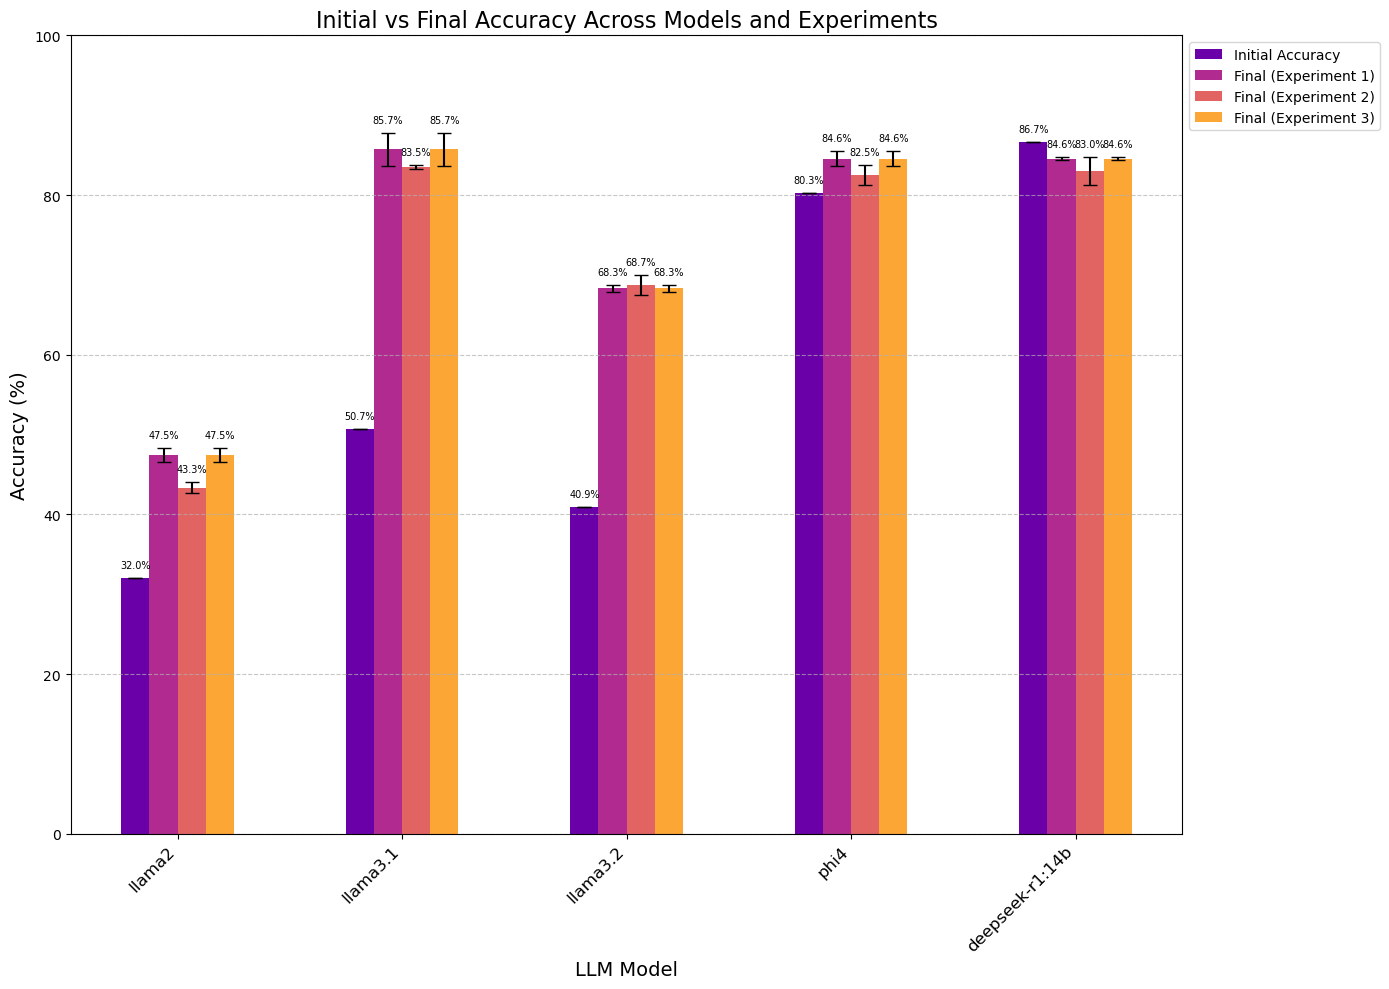

Visualization saved as 'llm_accuracy_comparison_plasma.png'


In [17]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def load_json_file(file_path):
    """Load a JSON file and return the data."""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

file_paths = [
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_answer.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_dual.json"
]


# Use descriptive names for each file/experiment
file_labels = [
    "Experiment 1",
    "Experiment 2", 
    "Experiment 3"
]

# Load data from all three files
all_data = []
for file_path in file_paths:
    data = load_json_file(file_path)
    if data:
        all_data.append(data)
    else:
        print(f"Skipping {file_path} due to loading error")

# Check if we have any valid data
if not all_data:
    print("No valid data found. Exiting.")
    exit()

# Define the specific order of models as requested
ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]

# Filter the ordered models to include only those present in the data
all_models = [model for model in ordered_models if any(model in data["llm_names"] for data in all_data)]

# Prepare data for plotting
file_count = len(all_data)
model_count = len(all_models)

# Initialize arrays for initial and final accuracies and their error bars
initial_accuracies = np.zeros(model_count)
initial_errors = np.zeros(model_count)
final_accuracies = np.zeros((model_count, file_count))
final_errors = np.zeros((model_count, file_count))

# Fill the arrays with data - using only first file for initial values
for model_idx, model_name in enumerate(all_models):
    if model_name in all_data[0]["mean_metrics"]:
        initial_accuracies[model_idx] = all_data[0]["mean_metrics"][model_name]["initial_accuracy"]
        initial_errors[model_idx] = all_data[0]["std_metrics"][model_name]["initial_accuracy"]

# Fill the final accuracy arrays with data from each file
for file_idx, data in enumerate(all_data):
    for model_idx, model_name in enumerate(all_models):
        if model_name in data["mean_metrics"]:
            final_accuracies[model_idx, file_idx] = data["mean_metrics"][model_name]["final_accuracy"]
            final_errors[model_idx, file_idx] = data["std_metrics"][model_name]["final_accuracy"]

# Create a figure
plt.figure(figsize=(14, 10))

# Set up the bar positions
bar_width = 0.2
group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
group_positions = np.arange(model_count) * (group_width + 0.8)  # Position of each model group

# Use seaborn's plasma palette
plasma_colors = sns.color_palette("plasma", file_count + 1)

# Plot initial accuracies first (only once per model)
initial_positions = group_positions
initial_bars = plt.bar(
    initial_positions, 
    initial_accuracies, 
    bar_width, 
    yerr=initial_errors, 
    capsize=5, 
    color=plasma_colors[0], 
    label="Initial Accuracy"
)

# Create the grouped bar chart for final accuracies
for file_idx in range(file_count):
    # Calculate positions for this file's bars - position after initial bar
    final_positions = group_positions + bar_width * (file_idx + 1)
    
    # Plot final accuracies
    plt.bar(
        final_positions, 
        final_accuracies[:, file_idx], 
        bar_width, 
        yerr=final_errors[:, file_idx], 
        capsize=5, 
        color=plasma_colors[file_idx + 1], 
        label=f"Final ({file_labels[file_idx]})"
    )

# Add labels and title
plt.xlabel('LLM Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Initial vs Final Accuracy Across Models', fontsize=16)

# Set x-ticks at the center of each group
plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), all_models, rotation=45, ha='right', fontsize=12)

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis range from 0 to 100 (for percentage)
plt.ylim(0, 100)

# Add value labels on top of initial bars with smaller font
for i, model_idx in enumerate(range(model_count)):
    if initial_accuracies[model_idx] > 0:
        plt.text(
            initial_positions[i],
            initial_accuracies[model_idx] + initial_errors[model_idx] + 1,
            f'{initial_accuracies[model_idx]:.1f}%',
            ha='center', va='bottom', fontsize=7
        )

# Add value labels on top of final bars with smaller font
for file_idx in range(file_count):
    final_positions = group_positions + bar_width * (file_idx + 1)
    
    for i, model_idx in enumerate(range(model_count)):
        if final_accuracies[model_idx, file_idx] > 0:
            plt.text(
                final_positions[i],
                final_accuracies[model_idx, file_idx] + final_errors[model_idx, file_idx] + 1,
                f'{final_accuracies[model_idx, file_idx]:.1f}%',
                ha='center', va='bottom', fontsize=7
            )

# Add a legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig('llm_accuracy_comparison_plasma.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'llm_accuracy_comparison_plasma.png'")

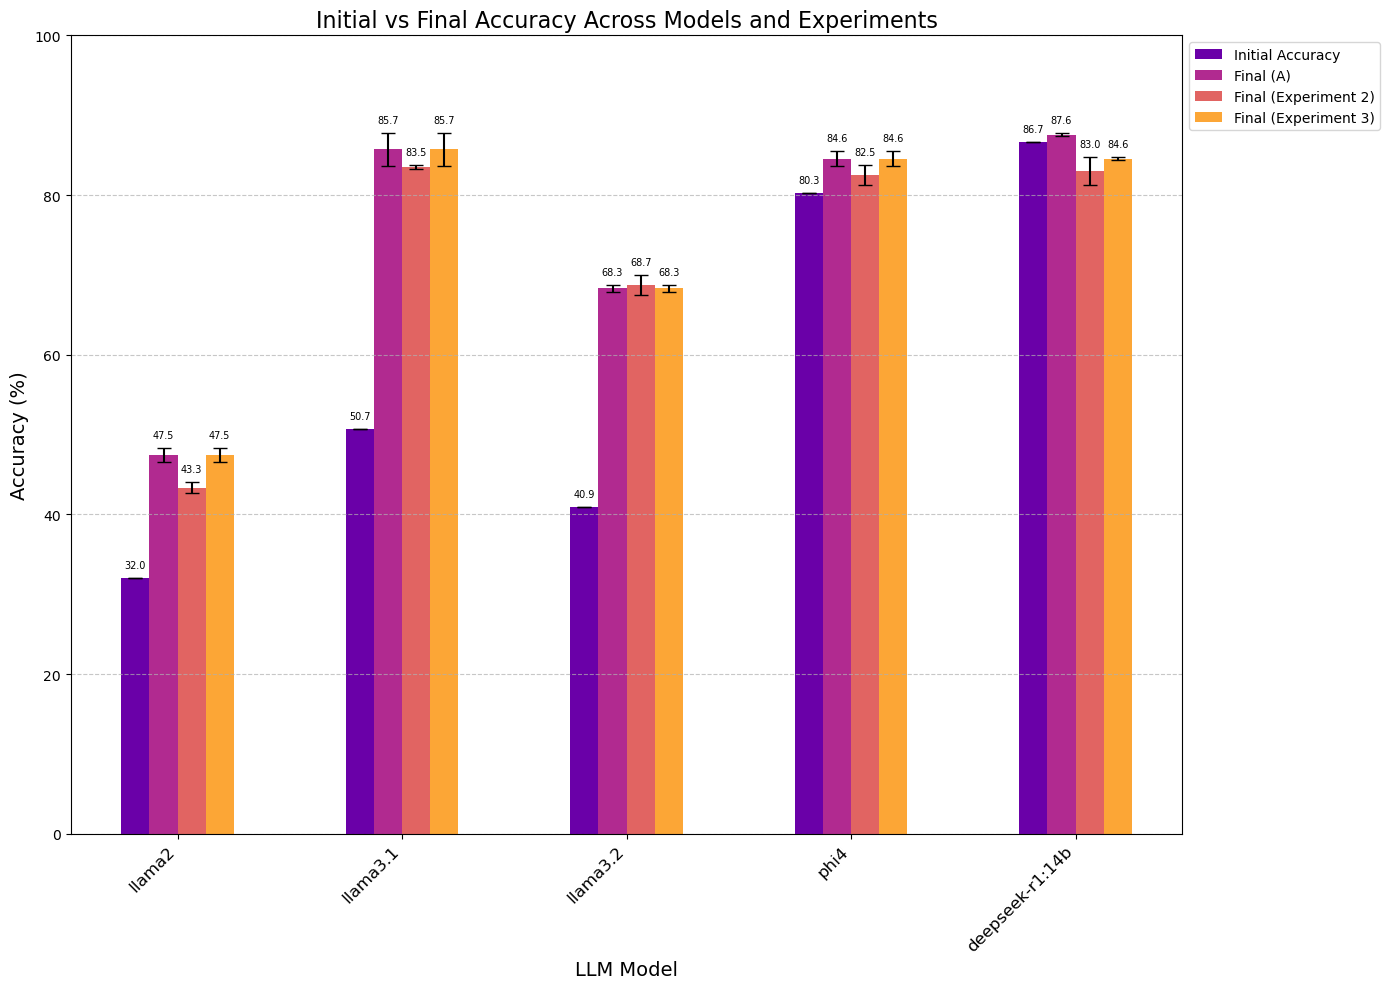

Visualization saved as 'llm_accuracy_comparison_plasma.png'


In [18]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def load_json_file(file_path):
    """Load a JSON file and return the data."""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Define the file paths
file_paths = [
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_answer.json",
    "/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_dual.json"
]


# Use descriptive names for each file/experiment
file_labels = [
    "A",
    "Experiment 2", 
    "Experiment 3"
]

# Load data from all three files
all_data = []
for file_path in file_paths:
    data = load_json_file(file_path)
    if data:
        all_data.append(data)
    else:
        print(f"Skipping {file_path} due to loading error")

# Check if we have any valid data
if not all_data:
    print("No valid data found. Exiting.")
    exit()

# Define the specific order of models as requested
ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]

# Filter the ordered models to include only those present in the data
all_models = [model for model in ordered_models if any(model in data["llm_names"] for data in all_data)]

# Prepare data for plotting
file_count = len(all_data)
model_count = len(all_models)

# Initialize arrays for initial and final accuracies and their error bars
initial_accuracies = np.zeros(model_count)
initial_errors = np.zeros(model_count)
final_accuracies = np.zeros((model_count, file_count))
final_errors = np.zeros((model_count, file_count))

# Fill the arrays with data - using only first file for initial values
for model_idx, model_name in enumerate(all_models):
    if model_name in all_data[0]["mean_metrics"]:
        initial_accuracies[model_idx] = all_data[0]["mean_metrics"][model_name]["initial_accuracy"]
        initial_errors[model_idx] = all_data[0]["std_metrics"][model_name]["initial_accuracy"]

# Fill the final accuracy arrays with data from each file
for file_idx, data in enumerate(all_data):
    for model_idx, model_name in enumerate(all_models):
        if model_name in data["mean_metrics"]:
            final_accuracies[model_idx, file_idx] = data["mean_metrics"][model_name]["final_accuracy"]
            final_errors[model_idx, file_idx] = data["std_metrics"][model_name]["final_accuracy"]

# Create a figure
plt.figure(figsize=(14, 10))

# Set up the bar positions
bar_width = 0.2
group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
group_positions = np.arange(model_count) * (group_width + 0.8)  # Position of each model group

# Use seaborn's plasma palette
plasma_colors = sns.color_palette("plasma", file_count + 1)

# Plot initial accuracies first (only once per model)
initial_positions = group_positions
initial_bars = plt.bar(
    initial_positions, 
    initial_accuracies, 
    bar_width, 
    yerr=initial_errors, 
    capsize=5, 
    color=plasma_colors[0], 
    label="Initial Accuracy"
)

# Create the grouped bar chart for final accuracies
for file_idx in range(file_count):
    # Calculate positions for this file's bars - position after initial bar
    final_positions = group_positions + bar_width * (file_idx + 1)
    
    # Plot final accuracies
    plt.bar(
        final_positions, 
        final_accuracies[:, file_idx], 
        bar_width, 
        yerr=final_errors[:, file_idx], 
        capsize=5, 
        color=plasma_colors[file_idx + 1], 
        label=f"Final ({file_labels[file_idx]})"
    )

# Add labels and title
plt.xlabel('LLM Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Initial vs Final Accuracy Across Models and Experiments', fontsize=16)

# Set x-ticks at the center of each group
plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), all_models, rotation=45, ha='right', fontsize=12)

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis range from 0 to 100 (for percentage)
plt.ylim(0, 100)

# Add value labels on top of initial bars with smaller font - NO PERCENT SIGNS
for i, model_idx in enumerate(range(model_count)):
    if initial_accuracies[model_idx] > 0:
        plt.text(
            initial_positions[i],
            initial_accuracies[model_idx] + initial_errors[model_idx] + 1,
            f'{initial_accuracies[model_idx]:.1f}',
            ha='center', va='bottom', fontsize=7
        )

# Add value labels on top of final bars with smaller font - NO PERCENT SIGNS
for file_idx in range(file_count):
    final_positions = group_positions + bar_width * (file_idx + 1)
    
    for i, model_idx in enumerate(range(model_count)):
        if final_accuracies[model_idx, file_idx] > 0:
            plt.text(
                final_positions[i],
                final_accuracies[model_idx, file_idx] + final_errors[model_idx, file_idx] + 1,
                f'{final_accuracies[model_idx, file_idx]:.1f}',
                ha='center', va='bottom', fontsize=7
            )

# Add a legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig('llm_accuracy_comparison_plasma.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'llm_accuracy_comparison_plasma.png'")

recalculating now that Ihave all of the data

In [19]:
import json
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pprint

def extract_metrics_from_files(file_paths, target_models=None):
    """
    Process multiple files and extract metrics for each model.
    
    Args:
        file_paths: List of paths to the JSON files
        target_models: List of model name prefixes to filter by (or None for all)
        
    Returns:
        Dictionary with metrics for each model across all files
    """
    all_files_metrics = []
    
    for file_path in file_paths:
        try:
            # Load the JSON file
            with open(file_path, "r") as file:
                data = json.load(file)
                
            # Initialize metrics container for this file
            metrics_by_model = defaultdict(lambda: {
                "initial_correct": 0,
                "final_correct": 0,
                "total": 0
            })
            
            # Process each item in the file
            for key, item in data.items():
                model_name = key.split("_")[0]  # Extract model name
                
                # Skip if not in our target models
                if target_models and not any(model_name.startswith(target) for target in target_models):
                    continue
                
                try:
                    # Get the correct answer
                    correct_answer_index = int(item["question"]["answer"])
                    options = item['question']['choices']
                    correct_answer = options[correct_answer_index]
                    
                    # Get responses
                    initial_response = item["raw_model_response"].lower()
                    final_response = item["onto_model_response"].lower()
                    
                    # Check correctness
                    if correct_answer.lower() in initial_response:
                        metrics_by_model[model_name]["initial_correct"] += 1
                    
                    if correct_answer.lower() in final_response:
                        metrics_by_model[model_name]["final_correct"] += 1
                    
                    metrics_by_model[model_name]["total"] += 1
                    
                except (KeyError, IndexError, ValueError) as e:
                    print(f"Error processing {key} in {file_path}: {e}")
                    continue
            
            # Calculate percentages for this file
            file_metrics = {}
            for model, counts in metrics_by_model.items():
                if counts["total"] > 0:
                    file_metrics[model] = {
                        "initial_accuracy": counts["initial_correct"] / counts["total"] * 100,
                        "final_accuracy": counts["final_correct"] / counts["total"] * 100,
                        "accuracy_improvement": (counts["final_correct"] - counts["initial_correct"]) / counts["total"] * 100,
                        "total_questions": counts["total"]
                    }
            
            all_files_metrics.append(file_metrics)
            print(f"Processed {file_path}: found {len(file_metrics)} models")
            
        except Exception as e:
            print(f"Error loading or processing {file_path}: {e}")
    
    return all_files_metrics

def calculate_aggregate_statistics(all_files_metrics):
    """
    Calculate mean and standard deviation across all files for each model.
    
    Args:
        all_files_metrics: List of dictionaries with metrics for each model by file
        
    Returns:
        Tuple of (mean_metrics, std_metrics)
    """
    # Get all unique models
    all_models = set()
    for file_metrics in all_files_metrics:
        all_models.update(file_metrics.keys())
    all_models = sorted(list(all_models))
    
    # Initialize containers for metrics
    mean_metrics = {}
    std_metrics = {}
    
    for model in all_models:
        # Collect metrics across files
        initial_accuracies = []
        final_accuracies = []
        accuracy_improvements = []
        total_questions = []
        
        for file_metrics in all_files_metrics:
            if model in file_metrics:
                initial_accuracies.append(file_metrics[model]["initial_accuracy"])
                final_accuracies.append(file_metrics[model]["final_accuracy"])
                accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
                total_questions.append(file_metrics[model]["total_questions"])
        
        # Calculate mean and standard deviation
        if initial_accuracies:
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "accuracy_improvement": np.mean(accuracy_improvements),
                "total_questions": np.mean(total_questions)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0,
                "total_questions": np.std(total_questions) if len(total_questions) > 1 else 0
            }
    
    return mean_metrics, std_metrics

def print_detailed_metrics(all_files_metrics, mean_metrics, std_metrics):
    """
    Print detailed metrics for each model across files.
    
    Args:
        all_files_metrics: List of dictionaries with metrics for each model by file
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
    """
    models = sorted(mean_metrics.keys())
    file_count = len(all_files_metrics)
    
    print(f"\n{'=' * 80}")
    print(f"DETAILED METRICS ACROSS {file_count} FILES")
    print(f"{'=' * 80}")
    
    for model in models:
        print(f"\nMODEL: {model}")
        print(f"{'-' * 40}")
        
        # Print individual file metrics
        for i, file_metrics in enumerate(all_files_metrics):
            if model in file_metrics:
                print(f"File {i+1}:")
                print(f"  Initial Accuracy: {file_metrics[model]['initial_accuracy']:.2f}%")
                print(f"  Final Accuracy: {file_metrics[model]['final_accuracy']:.2f}%")
                print(f"  Improvement: {file_metrics[model]['accuracy_improvement']:.2f}%")
                print(f"  Total Questions: {file_metrics[model]['total_questions']}")
        
        # Print aggregate metrics
        print("\nAggregate Statistics:")
        print(f"  Initial Accuracy: {mean_metrics[model]['initial_accuracy']:.2f}% ± {std_metrics[model]['initial_accuracy']:.2f}%")
        print(f"  Final Accuracy: {mean_metrics[model]['final_accuracy']:.2f}% ± {std_metrics[model]['final_accuracy']:.2f}%")
        print(f"  Improvement: {mean_metrics[model]['accuracy_improvement']:.2f}% ± {std_metrics[model]['accuracy_improvement']:.2f}%")
        print(f"  Average Questions: {mean_metrics[model]['total_questions']:.1f} ± {std_metrics[model]['total_questions']:.1f}")
        print()

def save_metrics_to_json(mean_metrics, std_metrics, output_file='llm_detailed_metrics.json'):
    """
    Save metrics to a JSON file.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        output_file: Path to the output file
    """
    # Get all model names
    models = sorted(mean_metrics.keys())
    
    # Create serializable data
    data = {
        "llm_names": models,
        "mean_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                        for model, metrics in mean_metrics.items()},
        "std_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                       for model, metrics in std_metrics.items()}
    }
    
    # Save to file
    with open(output_file, 'w') as f:
        json.dump(data, f, indent=4)
    
    print(f"Metrics saved to {output_file}")

def plot_accuracy_comparison(mean_metrics, std_metrics, output_file='accuracy_comparison.png'):
    """
    Create a bar plot comparing initial and final accuracy for each model.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        output_file: Path to the output file
    """
    # Get all model names
    models = sorted(mean_metrics.keys())
    
    # Extract metrics
    initial_accuracies = [mean_metrics[model]["initial_accuracy"] for model in models]
    final_accuracies = [mean_metrics[model]["final_accuracy"] for model in models]
    initial_errors = [std_metrics[model]["initial_accuracy"] for model in models]
    final_errors = [std_metrics[model]["final_accuracy"] for model in models]
    improvements = [mean_metrics[model]["accuracy_improvement"] for model in models]
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Set up the bar positions
    x = np.arange(len(models))
    width = 0.35
    
    # Use viridis color palette
    colors = sns.color_palette("viridis", 2)
    
    # Plot bars
    bars1 = ax.bar(x - width/2, initial_accuracies, width, label='Initial Accuracy', 
                  color=colors[0], yerr=initial_errors, capsize=5)
    bars2 = ax.bar(x + width/2, final_accuracies, width, label='Final Accuracy', 
                  color=colors[1], yerr=final_errors, capsize=5)
    
    # Add labels and formatting
    ax.set_xlabel('LLM Model', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title('Initial vs Final Accuracy by Model', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of bars
    for i, v in enumerate(initial_accuracies):
        ax.text(i - width/2, v + initial_errors[i] + 1, f'{v:.1f}%', 
                ha='center', va='bottom', fontsize=9)
    
    for i, v in enumerate(final_accuracies):
        ax.text(i + width/2, v + final_errors[i] + 1, f'{v:.1f}%', 
                ha='center', va='bottom', fontsize=9)
    
    # Add improvement as text
    for i, imp in enumerate(improvements):
        sign = "+" if imp >= 0 else ""
        ax.text(i, 5, f'{sign}{imp:.1f}%', ha='center', color='black', 
                fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")



Processed MMLU_highschool_Chem_Full_Dual_annotation0.json: found 5 models
Processed MMLU_highschool_Chem_Full_Dual_annotation1.json: found 5 models
Processed MMLU_highschool_Chem_Full_Dual_annotation2.json: found 5 models

DETAILED METRICS ACROSS 3 FILES

MODEL: deepseek-r1:14b
--------------------------------------------------------------------------------
File 1:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy: 84.24% (171/203)
  Improvement: -2.46%
  Total Questions: 203
File 2:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy: 84.73% (172/203)
  Improvement: -1.97%
  Total Questions: 203
File 3:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy: 84.73% (172/203)
  Improvement: -1.97%
  Total Questions: 203

Aggregate Statistics:
  Initial Accuracy: 86.70% ± 0.00%
  Final Accuracy: 84.56% ± 0.23%
  Improvement: -2.13% ± 0.23%
  Average Initial Correct: 176.0 ± 0.0
  Average Final Correct: 171.7 ± 0.5
  Average Questions: 203.0 ± 0.0


MODEL: llama2
-------------------

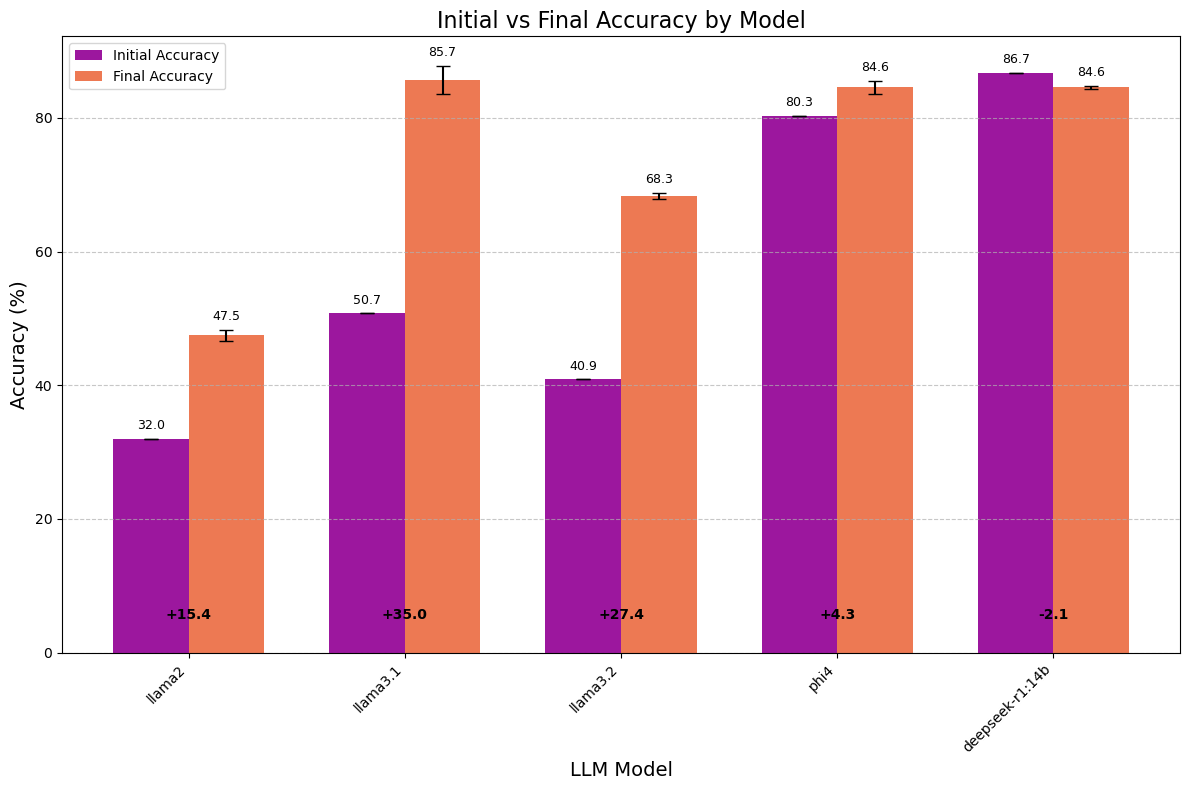

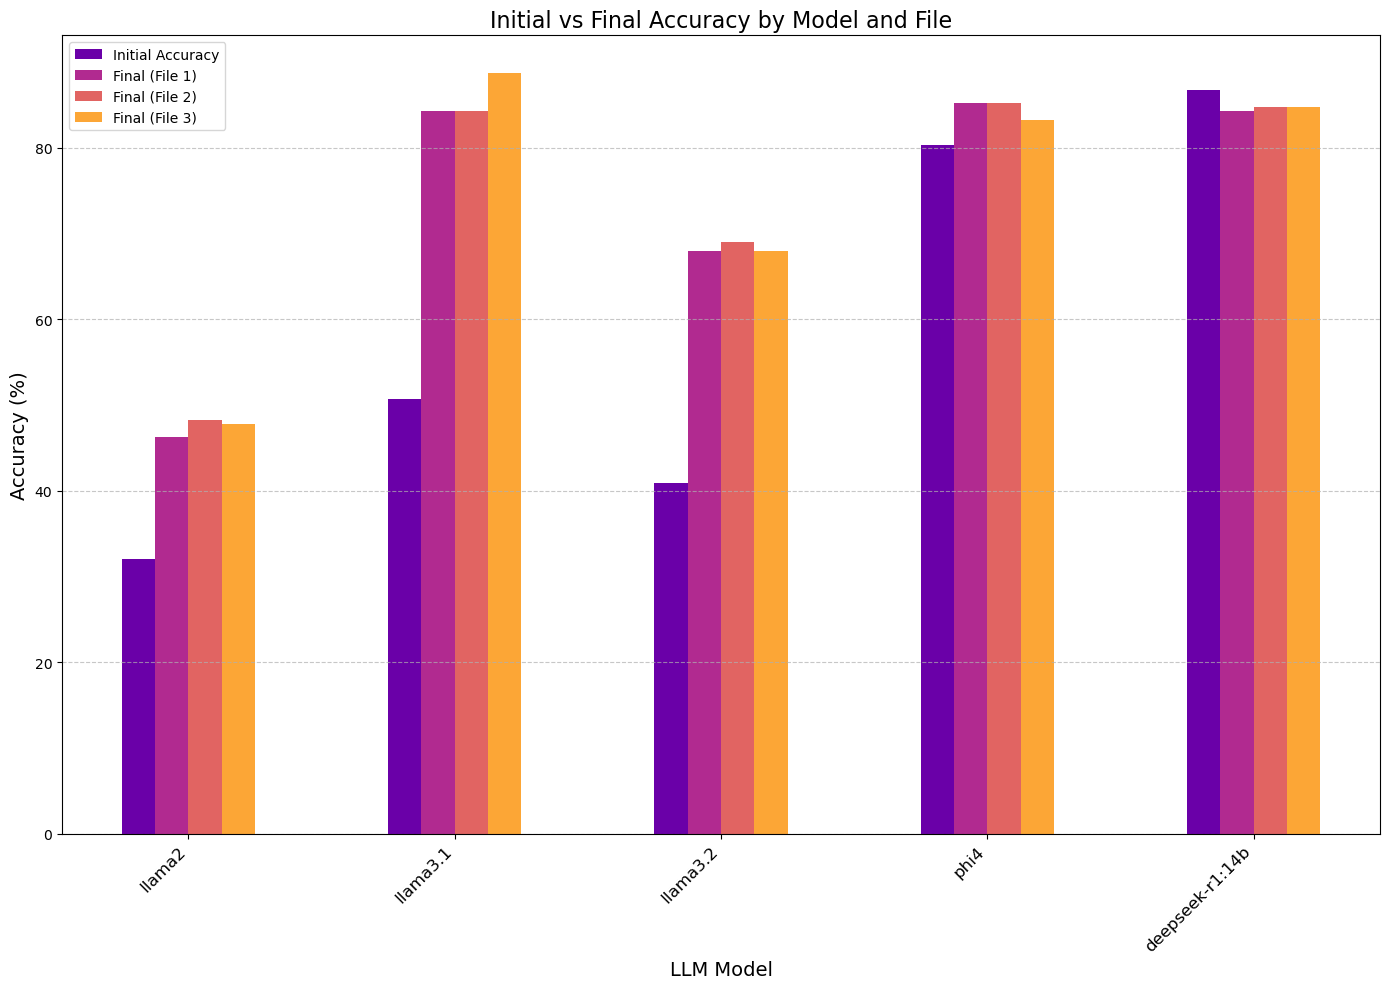

In [20]:
import json
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import os

def extract_metrics_from_files(file_paths, target_models=None):
    """
    Process multiple files and extract metrics for each model.
    
    Args:
        file_paths: List of paths to the JSON files
        target_models: List of model name prefixes to filter by (or None for all)
        
    Returns:
        Dictionary with metrics for each model across all files
    """
    all_files_metrics = []
    
    for file_path in file_paths:
        try:
            # Load the JSON file
            with open(file_path, "r") as file:
                data = json.load(file)
                
            # Initialize metrics container for this file
            metrics_by_model = defaultdict(lambda: {
                "initial_correct": 0,
                "final_correct": 0,
                "total": 0
            })
            
            # Process each item in the file
            for key, item in data.items():
                model_name = key.split("_")[0]  # Extract model name
                
                # Skip if not in our target models
                if target_models and not any(model_name.startswith(target) for target in target_models):
                    continue
                
                try:
                    # Get the correct answer
                    correct_answer_index = int(item["question"]["answer"])
                    options = item['question']['choices']
                    correct_answer = options[correct_answer_index]
                    
                    # Get responses
                    initial_response = item["raw_model_response"].lower()
                    final_response = item["onto_model_response"].lower()
                    
                    # Check correctness
                    if correct_answer.lower() in initial_response:
                        metrics_by_model[model_name]["initial_correct"] += 1
                    
                    if correct_answer.lower() in final_response:
                        metrics_by_model[model_name]["final_correct"] += 1
                    
                    metrics_by_model[model_name]["total"] += 1
                    
                except (KeyError, IndexError, ValueError) as e:
                    print(f"Error processing {key} in {file_path}: {e}")
                    continue
            
            # Calculate percentages for this file
            file_metrics = {}
            for model, counts in metrics_by_model.items():
                if counts["total"] > 0:
                    file_metrics[model] = {
                        "initial_accuracy": counts["initial_correct"] / counts["total"] * 100,
                        "final_accuracy": counts["final_correct"] / counts["total"] * 100,
                        "accuracy_improvement": (counts["final_correct"] - counts["initial_correct"]) / counts["total"] * 100,
                        "total_questions": counts["total"],
                        "initial_correct": counts["initial_correct"],
                        "final_correct": counts["final_correct"]
                    }
            
            all_files_metrics.append(file_metrics)
            print(f"Processed {os.path.basename(file_path)}: found {len(file_metrics)} models")
            
        except Exception as e:
            print(f"Error loading or processing {file_path}: {e}")
    
    return all_files_metrics

def calculate_aggregate_statistics(all_files_metrics):
    """
    Calculate mean and standard deviation across all files for each model.
    
    Args:
        all_files_metrics: List of dictionaries with metrics for each model by file
        
    Returns:
        Tuple of (mean_metrics, std_metrics)
    """
    # Get all unique models
    all_models = set()
    for file_metrics in all_files_metrics:
        all_models.update(file_metrics.keys())
    all_models = sorted(list(all_models))
    
    # Initialize containers for metrics
    mean_metrics = {}
    std_metrics = {}
    
    for model in all_models:
        # Collect metrics across files
        initial_accuracies = []
        final_accuracies = []
        accuracy_improvements = []
        total_questions = []
        initial_correct = []
        final_correct = []
        
        for file_metrics in all_files_metrics:
            if model in file_metrics:
                initial_accuracies.append(file_metrics[model]["initial_accuracy"])
                final_accuracies.append(file_metrics[model]["final_accuracy"])
                accuracy_improvements.append(file_metrics[model]["accuracy_improvement"])
                total_questions.append(file_metrics[model]["total_questions"])
                initial_correct.append(file_metrics[model]["initial_correct"])
                final_correct.append(file_metrics[model]["final_correct"])
        
        # Calculate mean and standard deviation
        if initial_accuracies:
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "accuracy_improvement": np.mean(accuracy_improvements),
                "total_questions": np.mean(total_questions),
                "initial_correct": np.mean(initial_correct),
                "final_correct": np.mean(final_correct)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "accuracy_improvement": np.std(accuracy_improvements) if len(accuracy_improvements) > 1 else 0,
                "total_questions": np.std(total_questions) if len(total_questions) > 1 else 0,
                "initial_correct": np.std(initial_correct) if len(initial_correct) > 1 else 0,
                "final_correct": np.std(final_correct) if len(final_correct) > 1 else 0
            }
    
    return mean_metrics, std_metrics

def print_detailed_metrics(all_files_metrics, mean_metrics, std_metrics):
    """
    Print detailed metrics for each model across files.
    
    Args:
        all_files_metrics: List of dictionaries with metrics for each model by file
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
    """
    models = sorted(mean_metrics.keys())
    file_count = len(all_files_metrics)
    
    print(f"\n{'=' * 80}")
    print(f"DETAILED METRICS ACROSS {file_count} FILES")
    print(f"{'=' * 80}")
    
    for model in models:
        print(f"\nMODEL: {model}")
        print(f"{'-' * 80}")
        
        # Print individual file metrics
        for i, file_metrics in enumerate(all_files_metrics):
            if model in file_metrics:
                print(f"File {i+1}:")
                print(f"  Initial Accuracy: {file_metrics[model]['initial_accuracy']:.2f}% ({file_metrics[model]['initial_correct']}/{file_metrics[model]['total_questions']})")
                print(f"  Final Accuracy: {file_metrics[model]['final_accuracy']:.2f}% ({file_metrics[model]['final_correct']}/{file_metrics[model]['total_questions']})")
                print(f"  Improvement: {file_metrics[model]['accuracy_improvement']:.2f}%")
                print(f"  Total Questions: {file_metrics[model]['total_questions']}")
        
        # Print aggregate metrics
        print("\nAggregate Statistics:")
        print(f"  Initial Accuracy: {mean_metrics[model]['initial_accuracy']:.2f}% ± {std_metrics[model]['initial_accuracy']:.2f}%")
        print(f"  Final Accuracy: {mean_metrics[model]['final_accuracy']:.2f}% ± {std_metrics[model]['final_accuracy']:.2f}%")
        print(f"  Improvement: {mean_metrics[model]['accuracy_improvement']:.2f}% ± {std_metrics[model]['accuracy_improvement']:.2f}%")
        print(f"  Average Initial Correct: {mean_metrics[model]['initial_correct']:.1f} ± {std_metrics[model]['initial_correct']:.1f}")
        print(f"  Average Final Correct: {mean_metrics[model]['final_correct']:.1f} ± {std_metrics[model]['final_correct']:.1f}")
        print(f"  Average Questions: {mean_metrics[model]['total_questions']:.1f} ± {std_metrics[model]['total_questions']:.1f}")
        print()

def save_metrics_to_json(mean_metrics, std_metrics, output_file='llm_detailed_metrics.json'):
    """
    Save metrics to a JSON file.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        output_file: Path to the output file
    """
    # Get all model names
    models = sorted(mean_metrics.keys())
    
    # Create serializable data
    data = {
        "llm_names": models,
        "mean_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                        for model, metrics in mean_metrics.items()},
        "std_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                       for model, metrics in std_metrics.items()}
    }
    
    # Save to file
    with open(output_file, 'w') as f:
        json.dump(data, f, indent=4)
    
    print(f"Metrics saved to {output_file}")

def plot_accuracy_comparison(mean_metrics, std_metrics, ordered_models=None, output_file='accuracy_comparison.png'):
    """
    Create a bar plot comparing initial and final accuracy for each model.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        ordered_models: List of models in the desired order (or None to use alphabetical)
        output_file: Path to the output file
    """
    # Get all model names in the specified order or alphabetically
    if ordered_models:
        models = [model for model in ordered_models if model in mean_metrics]
    else:
        models = sorted(mean_metrics.keys())
    
    # Extract metrics
    initial_accuracies = [mean_metrics[model]["initial_accuracy"] for model in models]
    final_accuracies = [mean_metrics[model]["final_accuracy"] for model in models]
    initial_errors = [std_metrics[model]["initial_accuracy"] for model in models]
    final_errors = [std_metrics[model]["final_accuracy"] for model in models]
    improvements = [mean_metrics[model]["accuracy_improvement"] for model in models]
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Set up the bar positions
    x = np.arange(len(models))
    width = 0.35
    
    # Use plasma color palette
    colors = sns.color_palette("plasma", 2)
    
    # Plot bars
    bars1 = ax.bar(x - width/2, initial_accuracies, width, label='Initial Accuracy', 
                  color=colors[0], yerr=initial_errors, capsize=5)
    bars2 = ax.bar(x + width/2, final_accuracies, width, label='Final Accuracy', 
                  color=colors[1], yerr=final_errors, capsize=5)
    
    # Add labels and formatting
    ax.set_xlabel('LLM Model', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title('Initial vs Final Accuracy by Model', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of bars (without % sign)
    for i, v in enumerate(initial_accuracies):
        ax.text(i - width/2, v + initial_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    for i, v in enumerate(final_accuracies):
        ax.text(i + width/2, v + final_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    # Add improvement as text
    for i, imp in enumerate(improvements):
        sign = "+" if imp >= 0 else ""
        ax.text(i, 5, f'{sign}{imp:.1f}', ha='center', color='black', 
                fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

def create_grouped_bar_plot(all_files_metrics, ordered_models=None, output_file='model_comparison_by_file.png'):
    """
    Create a grouped bar plot showing initial and final accuracy by file for each model.
    
    Args:
        all_files_metrics: List of dictionaries with metrics for each model by file
        ordered_models: List of models in the desired order (or None to use alphabetical)
        output_file: Path to the output file
    """
    # Get all unique models
    all_model_names = set()
    for file_metrics in all_files_metrics:
        all_model_names.update(file_metrics.keys())
    
    # Use specified order or default to alphabetical
    if ordered_models:
        models = [model for model in ordered_models if model in all_model_names]
    else:
        models = sorted(list(all_model_names))
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Set up the bar positions
    file_count = len(all_files_metrics)
    bar_width = 0.2
    group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
    group_positions = np.arange(len(models)) * (group_width + 0.8)  # Position of each model group
    
    # Use plasma color palette
    plasma_colors = sns.color_palette("plasma", file_count + 1)
    
    # Plot initial accuracies first (only once per model)
    initial_positions = group_positions
    initial_accuracies = []
    
    for i, model in enumerate(models):
        # Get initial accuracy from first file (assuming it's the same across files)
        if model in all_files_metrics[0]:
            initial_accuracies.append(all_files_metrics[0][model]["initial_accuracy"])
        else:
            # Use 0 if model is not in the first file
            initial_accuracies.append(0)
    
    initial_bars = ax.bar(
        initial_positions, 
        initial_accuracies, 
        bar_width, 
        color=plasma_colors[0], 
        label="Initial Accuracy"
    )
    
    # Plot final accuracies from each file
    for file_idx, file_metrics in enumerate(all_files_metrics):
        # Calculate positions for this file's bars - position after initial bar
        final_positions = group_positions + bar_width * (file_idx + 1)
        
        # Get final accuracies for each model in this file
        final_accuracies = []
        for model in models:
            if model in file_metrics:
                final_accuracies.append(file_metrics[model]["final_accuracy"])
            else:
                final_accuracies.append(0)  # Use 0 if model is not in this file
        
        # Plot final accuracies
        ax.bar(
            final_positions, 
            final_accuracies, 
            bar_width, 
            color=plasma_colors[file_idx + 1], 
            label=f"Final (File {file_idx + 1})"
        )
    
    # Add labels and formatting
    ax.set_xlabel('LLM Model', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title('Initial vs Final Accuracy by Model and File', fontsize=16)
    ax.set_xticks(group_positions + (group_width / 2) - (bar_width / 2))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Grouped bar plot saved to {output_file}")

# Run the analysis on your specific file paths
if __name__ == "__main__":
    # Define file paths
    file_paths = [
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json",
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation1.json",
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation2.json"
    ]
    
    # Define target models
    target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]
    
    # Define model order for plots
    ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]
    
    # Extract metrics from files
    all_files_metrics = extract_metrics_from_files(file_paths, target_models)
    
    # Calculate aggregate statistics
    mean_metrics, std_metrics = calculate_aggregate_statistics(all_files_metrics)
    
    # Print detailed metrics
    print_detailed_metrics(all_files_metrics, mean_metrics, std_metrics)
    
    # Save metrics to JSON
    save_metrics_to_json(mean_metrics, std_metrics, "dual_annotation_metrics.json")
    
    # Create visualizations
    plot_accuracy_comparison(mean_metrics, std_metrics, ordered_models, "dual_annotation_accuracy.png")
    create_grouped_bar_plot(all_files_metrics, ordered_models, "dual_annotation_by_file.png")
    
    print("\nAnalysis complete!")

Found 4 JSON files to analyze.

===== SUMMARY RESULTS =====


IndexError: Inconsistent shape between the condition and the input (got (0, 1) and (0,))

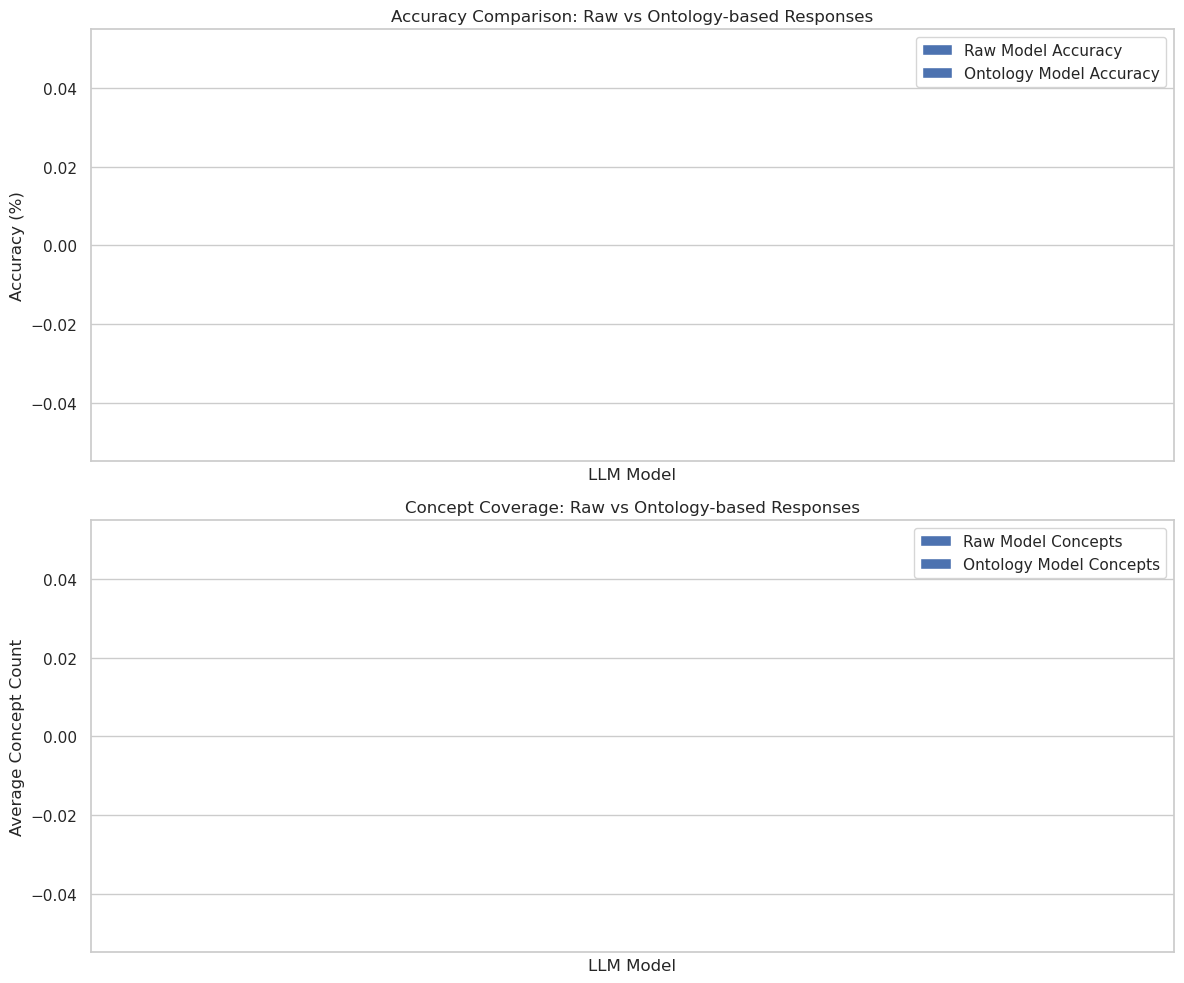

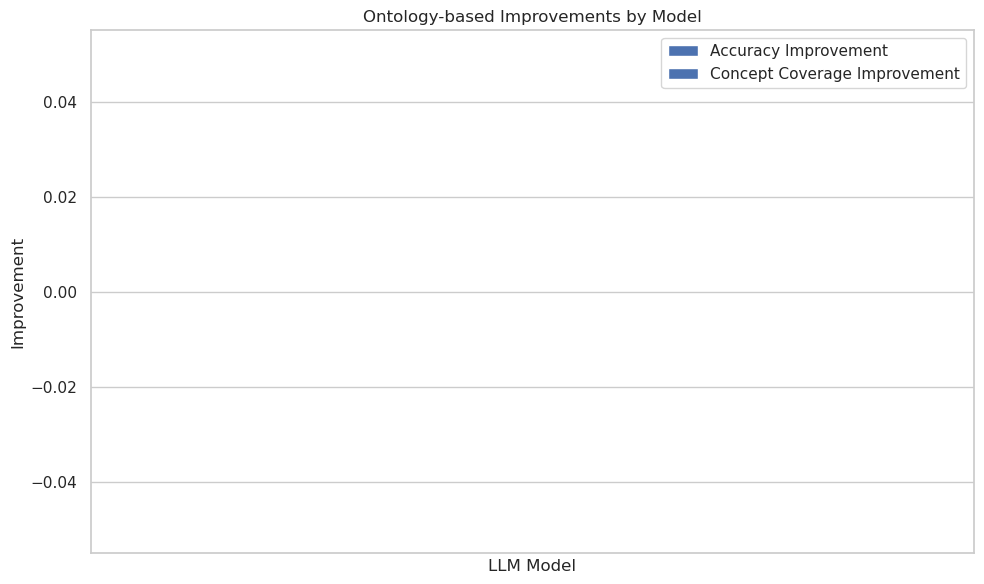

<Figure size 1200x800 with 0 Axes>

In [21]:
import json
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import defaultdict

# Load spaCy model for concept extraction
nlp = spacy.load("en_core_web_sm")

def extract_entities_and_keywords(text):
    """
    Extract entities and key concepts from text using spaCy.
    This function extracts named entities as well as noun chunks for better concept coverage.
    """
    if not text or not isinstance(text, str):
        return set()
        
    doc = nlp(text)
    
    # Get named entities
    entities = set([ent.text.lower() for ent in doc.ents])
    
    # Get noun chunks (concepts)
    noun_chunks = set([chunk.text.lower() for chunk in doc.noun_chunks])
    
    # Get key scientific terms using POS patterns
    science_terms = set()
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"] and len(token.text) > 3:
            science_terms.add(token.text.lower())
    
    # Combine all concepts
    all_concepts = entities.union(noun_chunks).union(science_terms)
    return all_concepts

def extract_answer_choice(response_text, choices):
    """
    Extract the chosen answer from model response text.
    Handles various ways a model might indicate its answer.
    
    Args:
        response_text (str): The model's text response
        choices (list): List of possible answer choices
        
    Returns:
        int: Index of the chosen answer, or -1 if not found
    """
    if not response_text:
        return -1
    
    response_text = response_text.lower()
    choices_lower = [choice.lower() for choice in choices]
    
    # Try direct pattern matching first
    for i, choice in enumerate(choices_lower):
        # Check for exact matches with quotation marks or brackets
        patterns = [
            f'answer is "{choice}"',
            f"answer is '{choice}'",
            f'answer is [{choice}]',
            f'correct answer is "{choice}"',
            f"correct answer is '{choice}'", 
            f'correct answer is [{choice}]',
            f'correct answer: "{choice}"',
            f"correct answer: '{choice}'",
            f'correct answer: {choice}',
            f'correct: {choice}',
            f'correct option is {choice}'
        ]
        
        for pattern in patterns:
            if pattern in response_text:
                return i
    
    # Try to find the option/index directly mentioned
    index_patterns = [
        r'answer is (?:option)?\s*(\d+)',
        r'correct answer is (?:option)?\s*(\d+)', 
        r'option\s*(\d+) is correct',
        r'correct option is\s*(\d+)',
        r'choice\s*(\d+)'
    ]
    
    for pattern in index_patterns:
        matches = re.findall(pattern, response_text)
        if matches:
            try:
                index = int(matches[0])
                # Handle both 0-indexed and 1-indexed responses
                if 0 <= index < len(choices):
                    return index
                elif 1 <= index <= len(choices):
                    return index - 1
            except ValueError:
                pass
    
    # If all above methods fail, check which choice appears most prominently in the text
    # This is less reliable but serves as a fallback
    choice_positions = []
    for i, choice in enumerate(choices_lower):
        # Find all occurrences of the choice text
        if choice in response_text:
            # Store the index and position of the choice in the response
            positions = [m.start() for m in re.finditer(re.escape(choice), response_text)]
            for pos in positions:
                choice_positions.append((i, pos))
    
    if choice_positions:
        # Sort by position (earlier mentions might be more relevant)
        choice_positions.sort(key=lambda x: x[1])
        return choice_positions[0][0]
    
    return -1

def load_and_analyze_files(file_paths):
    """
    Load and analyze all JSON files containing LLM responses.
    
    Args:
        file_paths (list): List of paths to JSON files
        
    Returns:
        dict: Metrics for each LLM model
    """
    # Initialize metrics dictionary
    llm_metrics = defaultdict(lambda: {
        "raw_correct": 0, 
        "onto_correct": 0, 
        "total": 0,
        "raw_responses": [],
        "onto_responses": [],
        "raw_concept_coverage": [],
        "onto_concept_coverage": [],
        "concept_diff": []
    })
    
    # Process each file
    for file_path in file_paths:
        try:
            with open(file_path, "r") as file:
                data = json.load(file)
                
                # Process each LLM response in the file
                for key, item in data.items():
                    # Skip if item doesn't have required fields
                    if not all(k in item for k in ["question", "raw_model_response", "onto_model_response"]):
                        continue
                    
                    # Extract model name (assuming format like "llama2_0")
                    model_name = key.split("_")[0]
                    
                    # Extract question details
                    question = item["question"]
                    correct_index = int(question["answer"])
                    choices = question["choices"]
                    correct_answer = choices[correct_index]
                    
                    # Get model responses
                    raw_response = item.get("raw_model_response", "")
                    onto_response = item.get("onto_model_response", "")
                    
                    # Extract chosen answers from responses
                    raw_choice_index = extract_answer_choice(raw_response, choices)
                    onto_choice_index = extract_answer_choice(onto_response, choices)
                    
                    # Check accuracy
                    raw_correct = (raw_choice_index == correct_index)
                    onto_correct = (onto_choice_index == correct_index)
                    
                    # Update accuracy metrics
                    if raw_correct:
                        llm_metrics[model_name]["raw_correct"] += 1
                    if onto_correct:
                        llm_metrics[model_name]["onto_correct"] += 1
                    
                    llm_metrics[model_name]["total"] += 1
                    
                    # Store responses for further analysis
                    llm_metrics[model_name]["raw_responses"].append(raw_response)
                    llm_metrics[model_name]["onto_responses"].append(onto_response)
                    
                    # Analyze concept coverage
                    raw_concepts = extract_entities_and_keywords(raw_response)
                    onto_concepts = extract_entities_and_keywords(onto_response)
                    
                    # Store concept metrics
                    llm_metrics[model_name]["raw_concept_coverage"].append(len(raw_concepts))
                    llm_metrics[model_name]["onto_concept_coverage"].append(len(onto_concepts))
                    
                    # Calculate unique concepts added in ontology-based response
                    unique_onto_concepts = onto_concepts - raw_concepts if raw_concepts else onto_concepts
                    llm_metrics[model_name]["concept_diff"].append(len(unique_onto_concepts))
                    
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
    
    return llm_metrics

def calculate_summary_metrics(llm_metrics):
    """
    Calculate summary metrics from the raw data.
    
    Args:
        llm_metrics (dict): Raw metrics for each LLM model
        
    Returns:
        dict: Summary metrics for each model
    """
    summary = {}
    
    for model_name, metrics in llm_metrics.items():
        total = metrics["total"]
        if total == 0:
            continue
            
        summary[model_name] = {
            "raw_accuracy": (metrics["raw_correct"] / total) * 100,
            "onto_accuracy": (metrics["onto_correct"] / total) * 100,
            "accuracy_improvement": ((metrics["onto_correct"] - metrics["raw_correct"]) / total) * 100,
            "avg_raw_concept_coverage": np.mean(metrics["raw_concept_coverage"]),
            "avg_onto_concept_coverage": np.mean(metrics["onto_concept_coverage"]),
            "avg_concept_improvement": np.mean(metrics["concept_diff"]),
            "total_questions": total
        }
    
    return summary

def plot_results(summary_metrics, output_dir="./plots"):
    """
    Generate visualizations from the summary metrics.
    
    Args:
        summary_metrics (dict): Summary metrics for each model
        output_dir (str): Directory to save plots
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Prepare data for plotting
    models = list(summary_metrics.keys())
    raw_acc = [summary_metrics[m]["raw_accuracy"] for m in models]
    onto_acc = [summary_metrics[m]["onto_accuracy"] for m in models]
    raw_concepts = [summary_metrics[m]["avg_raw_concept_coverage"] for m in models]
    onto_concepts = [summary_metrics[m]["avg_onto_concept_coverage"] for m in models]
    
    # Set up the plotting style
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 10))
    
    # Plot 1: Accuracy comparison
    plt.subplot(2, 1, 1)
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, raw_acc, width, label='Raw Model Accuracy')
    plt.bar(x + width/2, onto_acc, width, label='Ontology Model Accuracy')
    
    plt.xlabel('LLM Model')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Comparison: Raw vs Ontology-based Responses')
    plt.xticks(x, models)
    plt.legend()
    
    # Plot 2: Concept coverage comparison
    plt.subplot(2, 1, 2)
    x = np.arange(len(models))
    
    plt.bar(x - width/2, raw_concepts, width, label='Raw Model Concepts')
    plt.bar(x + width/2, onto_concepts, width, label='Ontology Model Concepts')
    
    plt.xlabel('LLM Model')
    plt.ylabel('Average Concept Count')
    plt.title('Concept Coverage: Raw vs Ontology-based Responses')
    plt.xticks(x, models)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "llm_comparison.png"))
    
    # Plot 3: Improvement metrics
    plt.figure(figsize=(10, 6))
    
    improvement_data = {
        'Accuracy Improvement (%)': [summary_metrics[m]["accuracy_improvement"] for m in models],
        'Concept Coverage Improvement': [summary_metrics[m]["avg_concept_improvement"] for m in models]
    }
    
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, improvement_data['Accuracy Improvement (%)'], width, label='Accuracy Improvement')
    plt.bar(x + width/2, improvement_data['Concept Coverage Improvement'], width, label='Concept Coverage Improvement')
    
    plt.xlabel('LLM Model')
    plt.ylabel('Improvement')
    plt.title('Ontology-based Improvements by Model')
    plt.xticks(x, models)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "improvement_metrics.png"))
    
    # Plot 4: Heatmap of all metrics
    plt.figure(figsize=(12, 8))
    
    # Prepare heatmap data
    heatmap_data = []
    metrics_names = ['Raw Accuracy', 'Onto Accuracy', 'Avg Raw Concepts', 'Avg Onto Concepts']
    
    for model in models:
        heatmap_data.append([
            summary_metrics[model]["raw_accuracy"],
            summary_metrics[model]["onto_accuracy"],
            summary_metrics[model]["avg_raw_concept_coverage"],
            summary_metrics[model]["avg_onto_concept_coverage"]
        ])
    
    # Create heatmap
    ax = sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu",
                    xticklabels=metrics_names,
                    yticklabels=models)
    
    plt.title('Performance Metrics Heatmap by Model')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "metrics_heatmap.png"))
    
    plt.close('all')

def main():
    """
    Main function to run the analysis.
    """
    # Get all JSON files in the current directory
    import glob
    file_paths = glob.glob("*.json")
    
    if not file_paths:
        print("No JSON files found in the current directory.")
        print("Please specify the directory containing your JSON files:")
        directory = input("> ")
        file_paths = glob.glob(os.path.join(directory, "*.json"))
    
    print(f"Found {len(file_paths)} JSON files to analyze.")
    
    # Analyze files
    llm_metrics = load_and_analyze_files(file_paths)
    
    # Calculate summary metrics
    summary_metrics = calculate_summary_metrics(llm_metrics)
    
    # Print summary results
    print("\n===== SUMMARY RESULTS =====")
    for model, metrics in summary_metrics.items():
        print(f"\nModel: {model}")
        print(f"  Questions analyzed: {metrics['total_questions']}")
        print(f"  Raw Model Accuracy: {metrics['raw_accuracy']:.2f}%")
        print(f"  Ontology Model Accuracy: {metrics['onto_accuracy']:.2f}%")
        print(f"  Accuracy Improvement: {metrics['accuracy_improvement']:.2f}%")
        print(f"  Avg Raw Concept Coverage: {metrics['avg_raw_concept_coverage']:.2f}")
        print(f"  Avg Ontology Concept Coverage: {metrics['avg_onto_concept_coverage']:.2f}")
        print(f"  Avg Concept Improvement: {metrics['avg_concept_improvement']:.2f}")
    
    # Generate plots
    plot_results(summary_metrics)
    print("\nAnalysis complete. Plots saved to './plots' directory.")
    
    # Save results to JSON
    with open("llm_analysis_results.json", "w") as f:
        json.dump(summary_metrics, f, indent=2)
    print("Results saved to 'llm_analysis_results.json'")

if __name__ == "__main__":
    main()